# Spatial Session Comparison (Combined-Locked Labels)

This notebook compares pooled spatial heatmaps using combined-session CS labels as reference.


In [24]:

import os
import sys
import copy
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.ma as ma
from tqdm.auto import tqdm

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
import types
local_utils_path = os.path.join(parent_dir, 'utils')
if 'utils' in sys.modules:
    del sys.modules['utils']
utils_pkg = types.ModuleType('utils')
utils_pkg.__path__ = [local_utils_path]
sys.modules['utils'] = utils_pkg
from utils.GRC_helpers import analyze_place_cell_single_moving

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})


In [25]:

# Config
DATA_FOLDER = os.path.abspath('../data')
FIGURE_SAVE_FOLDER = os.path.abspath('../figures/CKII_pooled')
os.makedirs(FIGURE_SAVE_FOLDER, exist_ok=True)

CB_NUM_THRESHOLD = 10
LABEL_SOURCE = "combined_locked"
INCLUDE_COMBINED_MAP = False
CONDITIONS = ("combined", "session1", "session2") if INCLUDE_COMBINED_MAP else ("session1", "session2")
MISSING_S2_POLICY = "na_panel"
CACHE_VERSION = "v6"
REBUILD_CACHE = False

# Spatial recompute parameters (match Figures.ipynb defaults)
ANALYSIS_PARAMS = {
    'place_field_threshold': 0.4,
    'min_peak_rate': 0.4,
    'max_field_area_ratio': 1/2,
    'min_field_bins': 10,
    'speed_threshold': 3,
    'min_duration_s': 0.25,
    'merge_gap_s': 0.0,
    'kernel_size': 51,
    'bin_size': 1.5,
    'width_real': 35.5,
    'height_real': 20.0,
    'theta_freqs': (4, 8),
    'slow_freqs': 2,
    'smooth_sigma': 2.0,
    'num_shuffles': 1000,
    'random_seed': 42,
    'min_occupancy_s': 0.001,
    'occ_smooth_sigma': 2.0,
    'ss_shape_min_separation_ms': 14.0,
}

# Keep this off for spatial-only workflow; clipping helpers still support complex payloads.
INCLUDE_COMPLEX_PAYLOAD = True
PLOT_SPIKE_SHAPES = True
PLOT_SPIKE_SHAPES_OVERALL = True
PLOT_SPIKE_SHAPES_IN_FIELD = True
PLOT_SPIKE_SHAPES_OUT_FIELD = True
CLEAN_HEATMAP = True
HEATMAP_SIMILARITY_METRIC = 'weighted_pearson'  # options: 'weighted_pearson', 'spearman', 'cosine'

MAX_CELLS_PER_FIG = 10

# Outlier handling for map-correlation analyses
REMOVE_LOW_SS_OUTLIER = False
SS_R_OUTLIER_THRESHOLD = 0.1

# S1-vs-S2 comparison gate (applies to map comparisons + heatmap display)
ENFORCE_S1S2_MIN_PEAK_RATE_FILTER = True
S1S2_MIN_PEAK_RATE_HZ = 0.5

# Dataset gate: keep only datasets with occupancy Spearman similarity above threshold
OCCUPANCY_SPEARMAN_THRESHOLD = -0.5

# Optional fixed scales (None = auto from loaded cells)
SELECTED_THETA_VLIM = [0, 0.2]
SELECTED_SLOW_VLIM = [-0.15, 0.15]

print(f"Data folder: {DATA_FOLDER}")
print(f"Figure save folder: {FIGURE_SAVE_FOLDER}")
print(f"CS+ threshold: n_cb_in_pf >= {CB_NUM_THRESHOLD}")
print(f"Remove low-SS-r outliers: {REMOVE_LOW_SS_OUTLIER} (threshold={SS_R_OUTLIER_THRESHOLD})")
print(f"Occupancy Spearman threshold: {OCCUPANCY_SPEARMAN_THRESHOLD}")
print(f"S1S2 min peak-rate threshold: {S1S2_MIN_PEAK_RATE_HZ} Hz (enabled={ENFORCE_S1S2_MIN_PEAK_RATE_FILTER})")
print(f"Include combined map in heatmap: {INCLUDE_COMBINED_MAP}")
print(f"Clean heatmap mode: {CLEAN_HEATMAP}")
print(f"Heatmap similarity metric: {HEATMAP_SIMILARITY_METRIC}")
print(f"Include complex payload: {INCLUDE_COMPLEX_PAYLOAD}")
print(f"Spike-shape rows: master={PLOT_SPIKE_SHAPES}, overall={PLOT_SPIKE_SHAPES_OVERALL}, in={PLOT_SPIKE_SHAPES_IN_FIELD}, out={PLOT_SPIKE_SHAPES_OUT_FIELD}")


Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data
Figure save folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled
CS+ threshold: n_cb_in_pf >= 10
Remove low-SS-r outliers: False (threshold=0.1)
Occupancy Spearman threshold: -0.5
S1S2 min peak-rate threshold: 0.5 Hz (enabled=True)
Include combined map in heatmap: False
Clean heatmap mode: True
Heatmap similarity metric: weighted_pearson
Include complex payload: True
Spike-shape rows: master=True, overall=True, in=True, out=True


In [26]:

# Data discovery (same CKII naming pattern as V2)
ckii_folders = sorted([
    d for d in os.listdir(DATA_FOLDER)
    if os.path.isdir(os.path.join(DATA_FOLDER, d)) and d.startswith('CKII_')
])

dataset_registry = []
for folder in ckii_folders:
    dataset_dir = os.path.join(DATA_FOLDER, folder)
    pooled_path = os.path.join(dataset_dir, 'pooled_stats.pkl')
    spatial_path = os.path.join(dataset_dir, 'spatial_analysis_full.pkl')
    merged_path = os.path.join(dataset_dir, 'merged_aligned_data.pkl')

    has_required = os.path.exists(pooled_path) and os.path.exists(spatial_path)
    has_merged = os.path.exists(merged_path)

    has_session2 = False
    frame_ranges = {'session1': None, 'session2': None}
    if has_merged:
        with open(merged_path, 'rb') as f:
            merged_tmp = pickle.load(f)
        n_frames_tmp = len(merged_tmp.get('x_neural', []))
        starts_tmp = sorted({int(v) for v in merged_tmp.get('session_start_frames', [0]) if int(v) >= 0})
        if not starts_tmp:
            starts_tmp = [0]
        if starts_tmp[0] != 0:
            starts_tmp = [0] + starts_tmp
        if len(starts_tmp) > 1 and starts_tmp[1] < n_frames_tmp:
            has_session2 = True
            frame_ranges['session1'] = [0, int(starts_tmp[1])]
            frame_ranges['session2'] = [int(starts_tmp[1]), int(n_frames_tmp)]
        else:
            frame_ranges['session1'] = [0, int(n_frames_tmp)]
            frame_ranges['session2'] = None

    dataset_registry.append({
        'dataset_id': folder,
        'dataset_dir': dataset_dir,
        'pooled_path': pooled_path,
        'spatial_path': spatial_path,
        'merged_path': merged_path,
        'has_required_outputs': has_required,
        'has_merged_data': has_merged,
        'has_session2': has_session2,
        'frame_ranges': frame_ranges,
    })

dataset_registry = [d for d in dataset_registry if d['has_required_outputs']]
print(f"Found {len(dataset_registry)} datasets with pooled outputs")
for d in dataset_registry:
    print(f"  {d['dataset_id']}: has_session2={d['has_session2']} frame_ranges={d['frame_ranges']}")


Found 5 datasets with pooled outputs
  CKII_pAce21_PR_20250806: has_session2=False frame_ranges={'session1': [0, 299500], 'session2': None}
  CKII_pAce38_PX_20251126: has_session2=True frame_ranges={'session1': [0, 298894], 'session2': [298894, 597670]}
  CKII_pAce45_PX_20260118: has_session2=True frame_ranges={'session1': [0, 299290], 'session2': [299290, 598609]}
  CKII_pAce46_PR_20260222: has_session2=True frame_ranges={'session1': [0, 299257], 'session2': [299257, 598579]}
  CKII_pAce47_PX_20260128: has_session2=True frame_ranges={'session1': [0, 299212], 'session2': [299212, 598461]}


In [27]:

# Combined-label reference (locked labels)
def get_deleted_cells(data_folder, folders, snr_threshold=3.5, bad_frac_threshold=0.9):
    deleted_set = set()
    for folder in folders:
        merged_path = os.path.join(data_folder, folder, 'merged_aligned_data_CS.pkl')
        if not os.path.exists(merged_path):
            continue
        with open(merged_path, 'rb') as f:
            merged_data = pickle.load(f)
        snr_list = merged_data.get('SNR_interpolated', [])
        for cell_idx in range(len(snr_list)):
            snr_vals = np.asarray(snr_list[cell_idx])
            if snr_vals.ndim == 0:
                deleted_set.add((folder, cell_idx))
                continue
            bad_mask = snr_vals < snr_threshold
            if np.mean(bad_mask) > bad_frac_threshold:
                deleted_set.add((folder, cell_idx))
    return deleted_set

folder_ids = [d['dataset_id'] for d in dataset_registry]
deleted_cells = get_deleted_cells(DATA_FOLDER, folder_ids)
print(f"Deleted cells (bad SNR): {len(deleted_cells)}")

all_spatial_cells = []
combined_cell_map = {}
cb_in_pf_counts = {}

for ds in dataset_registry:
    with open(ds['spatial_path'], 'rb') as f:
        cells = pickle.load(f)
    for c in cells:
        c = copy.deepcopy(c)
        c['session'] = ds['dataset_id']
        key = (ds['dataset_id'], int(c['cell_idx']))
        all_spatial_cells.append(c)
        combined_cell_map[key] = c

        spike_shapes = c.get('spike_shapes')
        n_in = 0
        if isinstance(spike_shapes, dict) and 'complex' in spike_shapes:
            shapes = spike_shapes.get('complex', {}).get('shapes', {})
            n_in = len(shapes.get('run_in', []))
        cb_in_pf_counts[key] = int(n_in)

valid_spatial_cells = [
    c for c in all_spatial_cells
    if (c['session'], int(c['cell_idx'])) not in deleted_cells
]

cell_labels = {}
for c in valid_spatial_cells:
    key = (c['session'], int(c['cell_idx']))
    is_pc = bool(c.get('is_place_cell', False))
    n_cb = cb_in_pf_counts.get(key, 0)
    if is_pc:
        cell_labels[key] = 'csplus' if n_cb >= CB_NUM_THRESHOLD else 'csminus'

csplus_keys = sorted([k for k, v in cell_labels.items() if v == 'csplus'])
csminus_keys = sorted([k for k, v in cell_labels.items() if v == 'csminus'])
nonpc_keys = sorted([
    (c['session'], int(c['cell_idx']))
    for c in valid_spatial_cells
    if not bool(c.get('is_place_cell', False))
])

print(f"Combined valid spatial cells: {len(valid_spatial_cells)}")
print(f"CS+ cells (combined-locked): {len(csplus_keys)}")
print(f"CS- cells (combined-locked): {len(csminus_keys)}")
print(f"Non-PLC cells (combined-locked): {len(nonpc_keys)}")


Deleted cells (bad SNR): 0
Combined valid spatial cells: 48
CS+ cells (combined-locked): 10
CS- cells (combined-locked): 8
Non-PLC cells (combined-locked): 30


In [28]:

# Session recompute helpers (with robust clipping for ragged interval payloads)

def _to_int_array(values):
    if values is None:
        return np.array([], dtype=np.int64)
    try:
        arr = np.asarray(values, dtype=np.int64).reshape(-1)
        return arr
    except Exception:
        out = []
        if isinstance(values, (list, tuple)):
            for v in values:
                if np.isscalar(v):
                    try:
                        out.append(int(v))
                    except Exception:
                        continue
        return np.asarray(out, dtype=np.int64)

def _clip_spike_list(spike_list, s0, s1):
    out = []
    for sp in spike_list:
        a = _to_int_array(sp)
        a = a[(a >= s0) & (a < s1)] - s0
        out.append(a)
    return out

def _clip_vec_list(vlist, s0, s1):
    out = []
    for v in vlist:
        if v is None:
            out.append(None)
            continue
        try:
            arr = np.asarray(v)
            out.append(arr[s0:s1])
        except Exception:
            out.append(v)
    return out

def _clip_index_sequence(seq, s0, s1):
    if seq is None:
        return None
    if isinstance(seq, np.ndarray):
        if seq.ndim == 1:
            a = _to_int_array(seq)
            return a[(a >= s0) & (a < s1)] - s0
        return seq
    if isinstance(seq, (list, tuple)):
        if len(seq) == 0:
            return []
        if all(np.isscalar(x) for x in seq):
            a = _to_int_array(seq)
            return a[(a >= s0) & (a < s1)] - s0
        clipped = []
        for x in seq:
            if isinstance(x, (list, tuple, np.ndarray)):
                clipped.append(_clip_index_sequence(x, s0, s1))
            else:
                clipped.append(x)
        return clipped
    return seq

def _clip_interval_dict_list(dict_list_in, s0, s1, total_frames_full, event_index_keys=()):
    if dict_list_in is None:
        return None
    out = []
    for item in dict_list_in:
        if not isinstance(item, dict):
            out.append(item)
            continue

        starts = _to_int_array(item.get('starts', item.get('start_indices', [])))
        ends = _to_int_array(item.get('ends', item.get('end_indices', [])))
        n = min(starts.size, ends.size)
        starts = starts[:n]
        ends = ends[:n]

        if n > 0:
            keep_mask = (ends >= s0) & (starts < s1)
        else:
            keep_mask = np.zeros((0,), dtype=bool)

        new_item = {}
        for k, v in item.items():
            if isinstance(v, np.ndarray):
                if v.ndim == 1 and v.size == total_frames_full:
                    new_item[k] = v[s0:s1]
                elif v.ndim == 1 and v.size == n:
                    new_item[k] = v[:n][keep_mask]
                else:
                    new_item[k] = v
                continue

            if isinstance(v, list):
                arr = None
                try:
                    arr = np.asarray(v)
                except Exception:
                    arr = None

                if arr is not None and arr.ndim == 1 and arr.size == n:
                    new_item[k] = arr[:n][keep_mask]
                elif k in event_index_keys:
                    new_item[k] = _clip_index_sequence(v, s0, s1)
                elif len(v) == n:
                    new_item[k] = [v[i] for i, keep in enumerate(keep_mask) if keep]
                else:
                    new_item[k] = v
                continue

            if k in event_index_keys:
                new_item[k] = _clip_index_sequence(v, s0, s1)
            else:
                new_item[k] = v

        if 'starts' in new_item:
            new_item['starts'] = _to_int_array(new_item['starts']) - s0
        if 'ends' in new_item:
            new_item['ends'] = _to_int_array(new_item['ends']) - s0
        if 'complex_bursts' in new_item:
            new_item['complex_bursts'] = _clip_index_sequence(new_item['complex_bursts'], s0, s1)
        if 'locs' in new_item:
            locs_arr = _to_int_array(new_item['locs'])
            new_item['locs'] = locs_arr[(locs_arr >= 0) & (locs_arr < (s1 - s0))]

        out.append(new_item)
    return out

def _clip_burst_metrics_list(burst_metrics_in, s0, s1):
    if burst_metrics_in is None:
        return None
    out = []
    for bursts in burst_metrics_in:
        if not isinstance(bursts, (list, tuple)):
            out.append(bursts)
            continue
        filtered = []
        for b in bursts:
            if not isinstance(b, dict):
                continue
            start = b.get('start', None)
            end = b.get('end', None)
            if start is None or end is None:
                continue
            try:
                start_i = int(start)
                end_i = int(end)
            except Exception:
                continue
            if end_i < s0 or start_i >= s1:
                continue
            b2 = dict(b)
            b2['start'] = start_i - s0
            b2['end'] = end_i - s0
            filtered.append(b2)
        out.append(filtered)
    return out

def _slice_merged_data(loaded, s0, s1, include_complex_payload=False):
    n_frames_total = len(loaded['x_neural'])
    sliced = {}

    # frame-wise arrays
    sliced['traces'] = np.asarray(loaded['traces'])[:, s0:s1]
    sliced['speed'] = np.asarray(loaded['speed'])[s0:s1]
    sliced['ts_neural'] = np.asarray(loaded['ts_neural'])[s0:s1]
    sliced['x_neural'] = np.asarray(loaded['x_neural'])[s0:s1]
    sliced['y_neural'] = np.asarray(loaded['y_neural'])[s0:s1]
    sliced['hd_angles_neural'] = np.asarray(loaded['hd_angles_neural'])[s0:s1]

    # metadata
    sliced['frame_rate'] = loaded['frame_rate']
    sliced['frame_width'] = loaded.get('frame_width', None)
    sliced['frame_height'] = loaded.get('frame_height', None)

    # per-session metadata (best effort)
    starts = sorted({int(v) for v in loaded.get('session_start_frames', [0]) if int(v) >= 0})
    if not starts:
        starts = [0]
    if starts[0] != 0:
        starts = [0] + starts

    subfolders = loaded.get('subfolders', [])
    weights_all = loaded.get('weights_all', [])
    mean_images = loaded.get('mean_images', [])

    if len(starts) > 1:
        sess_idx = int(np.searchsorted(np.asarray(starts), s0, side='right') - 1)
    else:
        sess_idx = 0

    def _pick_session_list(lst):
        if isinstance(lst, list) and len(lst) > 0:
            if sess_idx < len(lst):
                return [lst[sess_idx]]
            return [lst[0]]
        return lst

    sliced['subfolders'] = _pick_session_list(subfolders)
    sliced['weights_all'] = _pick_session_list(weights_all)
    sliced['mean_images'] = _pick_session_list(mean_images)

    # per-cell spike/event indices
    # Match Figures.ipynb behavior: all-spike maps use all_spikes as the main spike train.
    all_spikes_clipped = _clip_spike_list(loaded['all_spikes'], s0, s1)
    sliced['spikes'] = all_spikes_clipped
    sliced['refined_SS'] = _clip_spike_list(loaded['refined_SS'], s0, s1)
    sliced['all_CS_spikes'] = _clip_spike_list(loaded['all_CS_spikes'], s0, s1)
    sliced['all_spikes'] = all_spikes_clipped

    # per-cell vectors over frames
    for k in ['spike_heights_interpolated', 'SNR_interpolated', 'traces_SNR_interpolated', 'Vm_SNR_interpolated']:
        if k in loaded:
            sliced[k] = _clip_vec_list(loaded[k], s0, s1)

    # Optional complex payloads
    if include_complex_payload:
        sliced['complex_bursts_dicts'] = _clip_interval_dict_list(
            loaded.get('complex_bursts_dicts'),
            s0,
            s1,
            n_frames_total,
            event_index_keys=('complex_bursts', 'burst_indices', 'event_indices', 'spike_indices', 'peak_indices'),
        )
        sliced['plateaus_dicts'] = _clip_interval_dict_list(
            loaded.get('plateaus_dicts'),
            s0,
            s1,
            n_frames_total,
            event_index_keys=('plateau_indices', 'event_indices', 'spike_indices'),
        )
        sliced['burst_metrics'] = _clip_burst_metrics_list(loaded.get('burst_metrics'), s0, s1)
    else:
        sliced['complex_bursts_dicts'] = None
        sliced['plateaus_dicts'] = None
        sliced['burst_metrics'] = None

    sliced['session_start_frames'] = [0]
    return sliced

def _analysis_to_spatial_entry(analysis, animal_id, cell_idx):
    plot_data = analysis.get('plot_data', {})
    return {
        'animal_id': animal_id,
        'cell_idx': int(cell_idx),
        'is_place_cell': bool(analysis.get('is_place_cell', False)),
        'is_place_cell_ss': bool(analysis.get('is_place_cell_ss', False)),
        'is_place_cell_cs': bool(analysis.get('is_place_cell_cs', False)),
        'si': analysis.get('si', np.nan),
        'p_value': analysis.get('p_value', np.nan),
        'ss_si': analysis.get('ss_si', np.nan),
        'ss_p_value': analysis.get('ss_p_value', np.nan),
        'cs_si': analysis.get('cs_si', np.nan),
        'cs_p_value': analysis.get('cs_p_value', np.nan),
        'peak_rate': analysis.get('peak_rate', np.nan),
        'ss_peak_rate': analysis.get('ss_peak_rate', np.nan),
        'cs_peak_rate': analysis.get('cs_peak_rate', np.nan),
        'rate_map': analysis.get('rate_map', None),
        'ss_rate_map': analysis.get('ss_rate_map', None),
        'cs_rate_map': analysis.get('cs_rate_map', None),
        'ss_norm_map': analysis.get('ss_norm_map', None),
        'cs_norm_map': analysis.get('cs_norm_map', None),
        'occupancy': analysis.get('occupancy', None),
        'place_field_mask': analysis.get('place_field_mask', None),
        'ss_place_field_mask': analysis.get('ss_place_field_mask', None),
        'cs_place_field_mask': analysis.get('cs_place_field_mask', None),
        'pf_sizes': analysis.get('pf_sizes', []),
        'ss_pf_sizes': analysis.get('ss_pf_sizes', []),
        'cs_pf_sizes': analysis.get('cs_pf_sizes', []),
        'n_place_fields': analysis.get('n_place_fields', 0),
        'n_ss_place_fields': analysis.get('n_ss_place_fields', 0),
        'n_cs_place_fields': analysis.get('n_cs_place_fields', 0),
        'field_area': analysis.get('field_area', np.nan),
        'ss_field_area': analysis.get('ss_field_area', np.nan),
        'cs_field_area': analysis.get('cs_field_area', np.nan),
        'si_bits_per_spike': analysis.get('si_bits_per_spike', np.nan),
        'si_bits_per_spike_ss': analysis.get('si_bits_per_spike_ss', np.nan),
        'si_bits_per_spike_cs': analysis.get('si_bits_per_spike_cs', np.nan),
        'x_traj': analysis.get('x_traj', np.array([])),
        'y_traj': analysis.get('y_traj', np.array([])),
        'spikes_x': analysis.get('spikes_x', np.array([])),
        'spikes_y': analysis.get('spikes_y', np.array([])),
        'ss_spikes_x': plot_data.get('ss_spikes_x', np.array([])),
        'ss_spikes_y': plot_data.get('ss_spikes_y', np.array([])),
        'cs_spikes_x': plot_data.get('cs_spikes_x', np.array([])),
        'cs_spikes_y': plot_data.get('cs_spikes_y', np.array([])),
        'theta_corr_all': analysis.get('theta_corr_all', np.nan),
        'theta_corr_ss': analysis.get('theta_corr_ss', np.nan),
        'theta_corr_cs': analysis.get('theta_corr_cs', np.nan),
        'slow_corr_all': analysis.get('slow_corr_all', np.nan),
        'slow_corr_ss': analysis.get('slow_corr_ss', np.nan),
        'slow_corr_cs': analysis.get('slow_corr_cs', np.nan),
        'theta_map': analysis.get('theta_map', None),
        'slow_map': analysis.get('slow_map', None),
        'spike_shapes': analysis.get('spike_shapes', None),
        'burst_metrics': analysis.get('burst_metrics', None),
        'spike_burst_rate_metrics': analysis.get('spike_burst_rate_metrics', None),
        'params': analysis.get('params', {}),
    }

def _compute_session_ranges(merged_data):
    n_frames = len(merged_data['x_neural'])
    starts = sorted({int(v) for v in merged_data.get('session_start_frames', [0]) if int(v) >= 0})
    if not starts:
        starts = [0]
    if starts[0] != 0:
        starts = [0] + starts
    has_session2 = len(starts) > 1 and starts[1] < n_frames
    ranges = {
        'combined': (0, n_frames),
        'session1': (0, starts[1]) if has_session2 else (0, n_frames),
        'session2': (starts[1], n_frames) if has_session2 else None,
    }
    return ranges, has_session2

def _run_spatial_for_slice(sliced, animal_id, analysis_params):
    spikes = sliced['spikes']
    refined_SS = sliced['refined_SS']
    all_CS_spikes = sliced['all_CS_spikes']

    # Match Figures.ipynb: theta/slow maps are computed from traces_SNR_interpolated.
    traces_for_analysis = sliced.get('traces_SNR_interpolated', None)
    if traces_for_analysis is None:
        traces_for_analysis = sliced['traces']

    out_cells = []
    for cell_idx in tqdm(range(len(spikes)), desc=f"{animal_id} slice", leave=False):
        try:
            analysis = analyze_place_cell_single_moving(
                sliced['x_neural'],
                sliced['y_neural'],
                spikes,
                sliced['speed'],
                sliced['frame_rate'],
                cell_idx=cell_idx,
                axes=None,
                width_real=analysis_params['width_real'],
                height_real=analysis_params['height_real'],
                bin_size=analysis_params['bin_size'],
                smooth_sigma=analysis_params['smooth_sigma'],
                num_shuffles=analysis_params['num_shuffles'],
                place_field_threshold=analysis_params['place_field_threshold'],
                min_field_bins=analysis_params['min_field_bins'],
                kernel_size=analysis_params['kernel_size'],
                filter_type='boxcar',
                speed_threshold=analysis_params['speed_threshold'],
                min_duration_s=analysis_params['min_duration_s'],
                merge_gap_s=analysis_params['merge_gap_s'],
                plot_pf_contours=False,
                max_field_area_ratio=analysis_params['max_field_area_ratio'],
                min_occupancy_s=analysis_params['min_occupancy_s'],
                occ_smooth_sigma=analysis_params['occ_smooth_sigma'],
                bad_timepoints=None,
                random_seed=analysis_params['random_seed'],
                plot_sub=False,
                traces=traces_for_analysis,
                theta_freqs=analysis_params['theta_freqs'],
                slow_freqs=analysis_params['slow_freqs'],
                separate_spikes=True,
                refined_SS=refined_SS,
                all_CS_spikes=all_CS_spikes,
                complex_bursts_dicts=sliced.get('complex_bursts_dicts', None),
                min_peak_rate=analysis_params['min_peak_rate'],
                save_spike_shapes=True,
                save_burst_metrics=False,
                burst_metrics=None,
                include_simple_bursts_metrics=False,
                save_spike_burst_rate_metrics=False,
                ss_shape_min_separation_ms=analysis_params['ss_shape_min_separation_ms'],
            )
        except Exception as exc:
            print(f"  Warning: {animal_id} cell {cell_idx} failed during session recompute: {exc}")
            continue

        out_cells.append(_analysis_to_spatial_entry(analysis, animal_id, cell_idx))
    return out_cells

def _cache_path(dataset_dir):
    return os.path.join(dataset_dir, f"spatial_session_cache_{CACHE_VERSION}.pkl")

def _valid_cache_obj(cache_obj, dataset_id):
    if not isinstance(cache_obj, dict):
        return False
    if cache_obj.get('cache_version') != CACHE_VERSION:
        return False
    if cache_obj.get('dataset_id') != dataset_id:
        return False
    if 'cells' not in cache_obj or 'frame_ranges' not in cache_obj or 'has_session2' not in cache_obj:
        return False
    return True


In [29]:

# Build/load session payload caches
session_payload_by_dataset = {}

for ds in dataset_registry:
    dataset_id = ds['dataset_id']
    dataset_dir = ds['dataset_dir']
    cache_path = _cache_path(dataset_dir)

    cache_obj = None
    if (not REBUILD_CACHE) and os.path.exists(cache_path):
        try:
            with open(cache_path, 'rb') as f:
                loaded_cache = pickle.load(f)
            if _valid_cache_obj(loaded_cache, dataset_id):
                cache_obj = loaded_cache
                print(f"Loaded cache: {cache_path}")
        except Exception as exc:
            print(f"Cache load failed for {dataset_id}: {exc}")

    if cache_obj is None:
        if not ds['has_merged_data']:
            print(f"Skipping {dataset_id}: missing merged_aligned_data.pkl")
            continue

        with open(ds['merged_path'], 'rb') as f:
            merged_data = pickle.load(f)

        ranges, has_session2 = _compute_session_ranges(merged_data)
        cache_obj = {
            'cache_version': CACHE_VERSION,
            'dataset_id': dataset_id,
            'has_session2': bool(has_session2),
            'frame_ranges': {
                'session1': list(ranges['session1']) if ranges['session1'] is not None else None,
                'session2': list(ranges['session2']) if ranges['session2'] is not None else None,
            },
            'cells': {},
            'generated_from': {
                'merged_path': ds['merged_path'],
                'label_source': LABEL_SOURCE,
            },
        }

        # Combined from existing spatial_analysis_full.pkl for exact consistency
        combined_cells = []
        with open(ds['spatial_path'], 'rb') as f:
            combined_cells = pickle.load(f)
        for c in combined_cells:
            c2 = copy.deepcopy(c)
            c2['session'] = dataset_id
            idx = int(c2['cell_idx'])
            cache_obj['cells'].setdefault(idx, {})['combined'] = c2

        # Session 1 recompute
        s1_0, s1_1 = ranges['session1']
        sliced_s1 = _slice_merged_data(merged_data, s1_0, s1_1, include_complex_payload=INCLUDE_COMPLEX_PAYLOAD)
        session1_cells = _run_spatial_for_slice(sliced_s1, dataset_id, ANALYSIS_PARAMS)
        for c in session1_cells:
            idx = int(c['cell_idx'])
            cache_obj['cells'].setdefault(idx, {})['session1'] = c

        # Session 2 recompute (if present)
        if has_session2 and ranges['session2'] is not None:
            s2_0, s2_1 = ranges['session2']
            sliced_s2 = _slice_merged_data(merged_data, s2_0, s2_1, include_complex_payload=INCLUDE_COMPLEX_PAYLOAD)
            session2_cells = _run_spatial_for_slice(sliced_s2, dataset_id, ANALYSIS_PARAMS)
            for c in session2_cells:
                idx = int(c['cell_idx'])
                cache_obj['cells'].setdefault(idx, {})['session2'] = c

        with open(cache_path, 'wb') as f:
            pickle.dump(cache_obj, f)
        print(f"Saved cache: {cache_path}")

    session_payload_by_dataset[dataset_id] = cache_obj

print(f"Session payloads available for {len(session_payload_by_dataset)} datasets")


Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce21_PR_20250806/spatial_session_cache_v6.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce38_PX_20251126/spatial_session_cache_v6.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce45_PX_20260118/spatial_session_cache_v6.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce46_PR_20260222/spatial_session_cache_v6.pkl
Loaded cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce47_PX_20260128/spatial_session_cache_v6.pkl
Session payloads available for 5 datasets


=== Occupancy map similarity (Session1 vs Session2) ===
Min valid bins required: 20
Gate criterion: Spearman rho > -0.5


,metric,n_datasets_total,n_with_session1_and_2,n_valid_similarity,mean_similarity,median_similarity,std_similarity,mean_valid_bins
0,pearson,5,4,4,0.418191,0.493765,0.447902,336.0
1,spearman,5,4,4,0.394955,0.466151,0.460829,336.0
2,cosine,5,4,4,0.920736,0.921167,0.062292,336.0


Datasets total in payload: 5
Datasets passing gate: 4
Datasets excluded: 1
Applying occupancy dataset filter to downstream analyses...
Post-gate counts:
  dataset_registry: 4
  session_payload_by_dataset: 4
  CS+ keys: 9
  CS- keys: 6
  Non-PLC keys: 24
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_occupancy_similarity_metrics.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_occupancy_similarity_metrics.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_occupancy_similarity_metrics_summary.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_occupancy_similarity_gate_spearman_gt_0p5.csv


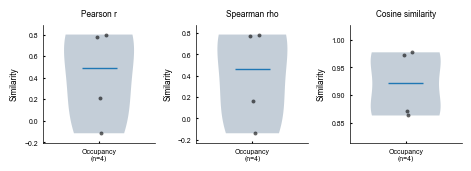

In [30]:
# Occupancy similarity gate (Session1 vs Session2)
# Applies dataset-level inclusion for all downstream analyses.
# Inclusion rule: Spearman rho > threshold

OCCUPANCY_SPEARMAN_THRESHOLD = float(globals().get('OCCUPANCY_SPEARMAN_THRESHOLD', 0.5))
APPLY_OCCUPANCY_DATASET_FILTER = True
MIN_VALID_BINS_FOR_OCC_SIM = 20

if 'scipy_stats' not in globals() or scipy_stats is None:
    try:
        from scipy import stats as scipy_stats
    except Exception:
        scipy_stats = None


def _extract_dataset_occupancy_pair_gate(dataset_id):
    payload = session_payload_by_dataset.get(dataset_id, None)
    if payload is None:
        return None, None

    cells = payload.get('cells', {})
    if not isinstance(cells, dict) or len(cells) == 0:
        return None, None

    occ_s1 = None
    occ_s2 = None

    for _cell_idx, by_cond in cells.items():
        if not isinstance(by_cond, dict):
            continue

        if occ_s1 is None:
            c1 = by_cond.get('session1', None)
            if isinstance(c1, dict):
                m1 = c1.get('occupancy', None)
                if isinstance(m1, np.ndarray) and m1.ndim == 2:
                    occ_s1 = np.asarray(m1, dtype=float)

        if occ_s2 is None:
            c2 = by_cond.get('session2', None)
            if isinstance(c2, dict):
                m2 = c2.get('occupancy', None)
                if isinstance(m2, np.ndarray) and m2.ndim == 2:
                    occ_s2 = np.asarray(m2, dtype=float)

        if occ_s1 is not None and occ_s2 is not None:
            break

    return occ_s1, occ_s2


def _pearson_nan_safe_gate(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    r = float(np.corrcoef(x, y)[0, 1])
    return (r if np.isfinite(r) else np.nan), n


def _spearman_nan_safe_gate(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n

    if scipy_stats is not None:
        try:
            rho, _p = scipy_stats.spearmanr(x, y)
            return (float(rho) if np.isfinite(rho) else np.nan), n
        except Exception:
            return np.nan, n

    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
        return np.nan, n
    rho = float(np.corrcoef(rx, ry)[0, 1])
    return (rho if np.isfinite(rho) else np.nan), n


def _cosine_nan_safe_gate(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n
    c = float(np.dot(x, y) / (nx * ny))
    return float(np.clip(c, -1.0, 1.0)), n


def _occ_similarity_gate(m1, m2, metric='pearson', min_valid_bins=20):
    if metric == 'pearson':
        return _pearson_nan_safe_gate(m1, m2, min_valid_bins=min_valid_bins)
    if metric == 'spearman':
        return _spearman_nan_safe_gate(m1, m2, min_valid_bins=min_valid_bins)
    if metric == 'cosine':
        return _cosine_nan_safe_gate(m1, m2, min_valid_bins=min_valid_bins)
    raise ValueError(metric)


metrics = ['pearson', 'spearman', 'cosine']
rows = []
for dataset_id in sorted(session_payload_by_dataset.keys()):
    occ_s1, occ_s2 = _extract_dataset_occupancy_pair_gate(dataset_id)
    has_both = isinstance(occ_s1, np.ndarray) and isinstance(occ_s2, np.ndarray)

    for metric in metrics:
        if has_both:
            sim, n_valid = _occ_similarity_gate(occ_s1, occ_s2, metric=metric, min_valid_bins=MIN_VALID_BINS_FOR_OCC_SIM)
        else:
            sim, n_valid = np.nan, 0

        rows.append({
            'dataset_id': str(dataset_id),
            'metric': metric,
            'has_both_sessions': bool(has_both),
            'n_valid_bins': int(n_valid),
            'similarity': sim,
        })

occupancy_similarity_df = pd.DataFrame(rows)

summary_rows = []
for metric in metrics:
    d = occupancy_similarity_df[occupancy_similarity_df['metric'] == metric].copy()
    valid = d[np.isfinite(d['similarity'])]
    summary_rows.append({
        'metric': metric,
        'n_datasets_total': int(len(d)),
        'n_with_session1_and_2': int(d['has_both_sessions'].sum()),
        'n_valid_similarity': int(len(valid)),
        'mean_similarity': float(np.nanmean(valid['similarity'])) if len(valid) > 0 else np.nan,
        'median_similarity': float(np.nanmedian(valid['similarity'])) if len(valid) > 0 else np.nan,
        'std_similarity': float(np.nanstd(valid['similarity'], ddof=1)) if len(valid) > 1 else np.nan,
        'mean_valid_bins': float(np.nanmean(valid['n_valid_bins'])) if len(valid) > 0 else np.nan,
    })

occupancy_similarity_summary_df = pd.DataFrame(summary_rows)

# Gate datasets by occupancy Spearman similarity
spearman_gate = occupancy_similarity_df[
    (occupancy_similarity_df['metric'] == 'spearman')
    & np.isfinite(occupancy_similarity_df['similarity'])
    & (occupancy_similarity_df['similarity'] > float(OCCUPANCY_SPEARMAN_THRESHOLD))
]

allowed_dataset_ids = set(spearman_gate['dataset_id'].astype(str).tolist())
all_dataset_ids = set(str(k) for k in session_payload_by_dataset.keys())
excluded_dataset_ids = sorted(all_dataset_ids - allowed_dataset_ids)

print('=== Occupancy map similarity (Session1 vs Session2) ===')
print(f'Min valid bins required: {MIN_VALID_BINS_FOR_OCC_SIM}')
print(f"Gate criterion: Spearman rho > {OCCUPANCY_SPEARMAN_THRESHOLD}")
display(occupancy_similarity_summary_df)

print(f'Datasets total in payload: {len(all_dataset_ids)}')
print(f'Datasets passing gate: {len(allowed_dataset_ids)}')
print(f'Datasets excluded: {len(excluded_dataset_ids)}')

if APPLY_OCCUPANCY_DATASET_FILTER:
    print('Applying occupancy dataset filter to downstream analyses...')

    # dataset_registry
    if 'dataset_registry' in globals() and isinstance(dataset_registry, list):
        dataset_registry = [d for d in dataset_registry if str(d.get('dataset_id')) in allowed_dataset_ids]

    # session payloads
    session_payload_by_dataset = {
        k: v for k, v in session_payload_by_dataset.items()
        if str(k) in allowed_dataset_ids
    }

    # key-based populations
    def _filter_keys(keys_in):
        return sorted([k for k in keys_in if str(k[0]) in allowed_dataset_ids])

    if 'csplus_keys' in globals():
        csplus_keys = _filter_keys(csplus_keys)
    if 'csminus_keys' in globals():
        csminus_keys = _filter_keys(csminus_keys)
    if 'nonpc_keys' in globals():
        nonpc_keys = _filter_keys(nonpc_keys)

    # optional maps/metadata
    if 'cell_labels' in globals() and isinstance(cell_labels, dict):
        cell_labels = {k: v for k, v in cell_labels.items() if str(k[0]) in allowed_dataset_ids}
    if 'combined_cell_map' in globals() and isinstance(combined_cell_map, dict):
        combined_cell_map = {k: v for k, v in combined_cell_map.items() if str(k[0]) in allowed_dataset_ids}
    if 'cb_in_pf_counts' in globals() and isinstance(cb_in_pf_counts, dict):
        cb_in_pf_counts = {k: v for k, v in cb_in_pf_counts.items() if str(k[0]) in allowed_dataset_ids}
    if 'all_spatial_cells' in globals() and isinstance(all_spatial_cells, list):
        all_spatial_cells = [c for c in all_spatial_cells if str(c.get('session')) in allowed_dataset_ids]
    if 'valid_spatial_cells' in globals() and isinstance(valid_spatial_cells, list):
        valid_spatial_cells = [c for c in valid_spatial_cells if str(c.get('session')) in allowed_dataset_ids]

    print('Post-gate counts:')
    print(f'  dataset_registry: {len(dataset_registry) if "dataset_registry" in globals() else "n/a"}')
    print(f'  session_payload_by_dataset: {len(session_payload_by_dataset)}')
    print(f'  CS+ keys: {len(csplus_keys) if "csplus_keys" in globals() else "n/a"}')
    print(f'  CS- keys: {len(csminus_keys) if "csminus_keys" in globals() else "n/a"}')
    print(f'  Non-PLC keys: {len(nonpc_keys) if "nonpc_keys" in globals() else "n/a"}')

# Save outputs
fig, axes = plt.subplots(1, 3, figsize=(4.6, 1.6), constrained_layout=True)
metric_title = {'pearson': 'Pearson r', 'spearman': 'Spearman rho', 'cosine': 'Cosine similarity'}
for ax, metric in zip(axes, metrics):
    vals = np.asarray(occupancy_similarity_df.loc[occupancy_similarity_df['metric'] == metric, 'similarity'], dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) >= 3:
        parts = ax.violinplot([vals], positions=[1.0], showmedians=True, showextrema=False)
        if 'cmedians' in parts:
            parts['cmedians'].set_color('#1F77B4')
            parts['cmedians'].set_linewidth(1.0)
        for b in parts['bodies']:
            b.set_facecolor('#577590')
            b.set_edgecolor('none')
            b.set_alpha(0.35)

    if len(vals) > 0:
        rng = np.random.default_rng(300 + len(vals))
        xj = 1.0 + (rng.random(len(vals)) - 0.5) * 0.12
        ax.scatter(xj, vals, s=8, color='black', alpha=0.6, linewidths=0, zorder=3)

    ax.set_title(metric_title[metric], fontsize=6, fontname='Arial')
    ax.set_xticks([1.0])
    ax.set_xticklabels([f'Occupancy\n(n={len(vals)})'], fontsize=4, fontname='Arial')
    ax.set_ylabel('Similarity', fontsize=6, fontname='Arial')
    ax.tick_params(axis='both', labelsize=5)
    for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        lbl.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0.6, 1.4)

    if len(vals) > 0:
        y_min = float(np.nanmin(vals))
        y_max = float(np.nanmax(vals))
    else:
        y_min, y_max = 0.0, 1.0
    pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
    ax.set_ylim(y_min - pad, y_max + pad)

fig_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_occupancy_similarity_metrics.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

csv_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_occupancy_similarity_metrics.csv')
occupancy_similarity_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

summary_csv_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_occupancy_similarity_metrics_summary.csv')
occupancy_similarity_summary_df.to_csv(summary_csv_path, index=False)
print(f'Saved: {summary_csv_path}')

gate_csv_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_occupancy_similarity_gate_spearman_gt_0p5.csv')
pd.DataFrame({
    'dataset_id': sorted(list(all_dataset_ids)),
    'passes_spearman_gate': [d in allowed_dataset_ids for d in sorted(list(all_dataset_ids))],
}).to_csv(gate_csv_path, index=False)
print(f'Saved: {gate_csv_path}')

In [31]:

# Assemble CS+ / CS- / Non-PLC comparison groups (Combined vs Session1 vs Session2)

condition_labels = {
    'combined': 'Combined',
    'session1': 'Session 1',
    'session2': 'Session 2',
}

def _make_na_cell(ref_cell, condition_key):
    cell = copy.deepcopy(ref_cell)
    cell['condition_label'] = f"{condition_labels[condition_key]} (N/A)"
    cell['is_na_panel'] = True

    # Ensure map-like fields are present and NaN so plotting remains stable.
    map_keys = ['rate_map', 'ss_norm_map', 'cs_norm_map', 'theta_map', 'slow_map', 'occupancy']
    mask_keys = ['place_field_mask', 'ss_place_field_mask', 'cs_place_field_mask']

    shape = None
    for mk in ['rate_map', 'ss_norm_map', 'cs_norm_map', 'theta_map', 'slow_map']:
        m = cell.get(mk, None)
        if isinstance(m, np.ndarray) and m.ndim == 2:
            shape = m.shape
            break
    if shape is None:
        shape = (24, 14)

    for mk in map_keys:
        cell[mk] = np.full(shape, np.nan, dtype=float)
    for mk in mask_keys:
        cell[mk] = np.zeros(shape, dtype=bool)

    cell['x_traj'] = np.array([])
    cell['y_traj'] = np.array([])
    cell['spikes_x'] = np.array([])
    cell['spikes_y'] = np.array([])
    cell['ss_spikes_x'] = np.array([])
    cell['ss_spikes_y'] = np.array([])
    cell['cs_spikes_x'] = np.array([])
    cell['cs_spikes_y'] = np.array([])
    cell['peak_rate'] = np.nan
    cell['spike_shapes'] = None
    return cell


def _normalize_map_to_own_peak(rate_map):
    if not isinstance(rate_map, np.ndarray):
        return None
    if rate_map.size == 0 or (not np.any(np.isfinite(rate_map))):
        return np.full_like(rate_map, np.nan, dtype=float)
    peak = np.nanmax(rate_map)
    if (not np.isfinite(peak)) or peak <= 0:
        out = np.array(rate_map, dtype=float, copy=True)
        out[np.isfinite(out)] = 0.0
        return out
    return np.asarray(rate_map, dtype=float) / float(peak)

def _renormalize_ss_cs_maps_per_condition(cell):
    # Force per-condition normalization so SS/CS maps are session-local.
    ss_rate = cell.get('ss_rate_map', None)
    cs_rate = cell.get('cs_rate_map', None)

    ss_norm = _normalize_map_to_own_peak(ss_rate)
    cs_norm = _normalize_map_to_own_peak(cs_rate)

    if ss_norm is not None:
        cell['ss_norm_map'] = ss_norm
    if cs_norm is not None:
        cell['cs_norm_map'] = cs_norm

def _get_condition_cell(dataset_id, cell_idx, cond):
    payload = session_payload_by_dataset.get(dataset_id, None)
    if payload is None:
        return None
    by_cell = payload.get('cells', {})
    by_cond = by_cell.get(int(cell_idx), {})
    return by_cond.get(cond, None)



def _nan_peak_from_map(map_arr):
    if not isinstance(map_arr, np.ndarray):
        return np.nan
    if map_arr.size == 0 or (not np.any(np.isfinite(map_arr))):
        return np.nan
    return float(np.nanmax(map_arr))


def _session_peak_for_map(cell, map_key='rate_map'):
    if not isinstance(cell, dict):
        return np.nan

    # Prefer stored per-condition peak-rate scalars when available,
    # because these are the values shown in map labels.
    if map_key == 'ss_norm_map':
        try:
            v = float(cell.get('ss_peak_rate', np.nan))
            if np.isfinite(v):
                return v
        except Exception:
            pass
        return _nan_peak_from_map(cell.get('ss_rate_map', None))

    if map_key == 'cs_norm_map':
        try:
            v = float(cell.get('cs_peak_rate', np.nan))
            if np.isfinite(v):
                return v
        except Exception:
            pass
        return _nan_peak_from_map(cell.get('cs_rate_map', None))

    # For rate/theta/slow/other comparisons, gate by all-spike peak rate.
    try:
        v = float(cell.get('peak_rate', np.nan))
        if np.isfinite(v):
            return v
    except Exception:
        pass
    return _nan_peak_from_map(cell.get('rate_map', None))


def _passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key='rate_map', threshold=None):
    if threshold is None:
        threshold = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
    c1 = _get_condition_cell(dataset_id, cell_idx, 'session1')
    c2 = _get_condition_cell(dataset_id, cell_idx, 'session2')
    if c1 is None or c2 is None:
        return False
    p1 = _session_peak_for_map(c1, map_key=map_key)
    p2 = _session_peak_for_map(c2, map_key=map_key)
    return bool(np.isfinite(p1) and np.isfinite(p2) and (p1 > threshold) and (p2 > threshold))

def _prepare_triplets(cell_keys):
    groups = []
    missing_s2_rows = 0

    for key in cell_keys:
        dataset_id, cell_idx = key
        ref_combined = _get_condition_cell(dataset_id, cell_idx, 'combined')
        if ref_combined is None:
            continue

        if bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)):
            thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
            if not _passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key='rate_map', threshold=thr):
                continue

        triplet = []
        for cond in CONDITIONS:
            c = _get_condition_cell(dataset_id, cell_idx, cond)
            if c is None:
                if cond == 'session2' and MISSING_S2_POLICY == 'na_panel':
                    c = _make_na_cell(ref_combined, cond)
                    missing_s2_rows += 1
                else:
                    continue
            else:
                c = copy.deepcopy(c)
                c['condition_label'] = condition_labels[cond]
                c['is_na_panel'] = bool(c.get('is_na_panel', False))
                _renormalize_ss_cs_maps_per_condition(c)

            triplet.append(c)

        # require all requested conditions after N/A injection
        if len(triplet) != len(CONDITIONS):
            continue

        groups.append(triplet)

    return groups, missing_s2_rows

csplus_groups, csplus_missing_s2 = _prepare_triplets(csplus_keys)
csminus_groups, csminus_missing_s2 = _prepare_triplets(csminus_keys)
nonpc_groups, nonpc_missing_s2 = _prepare_triplets(nonpc_keys)

# Global theta/slow limits across all groups and all conditions
all_plot_cells = [c for grp in (csplus_groups + csminus_groups + nonpc_groups) for c in grp]
theta_vals = []
slow_abs_vals = []
for c in all_plot_cells:
    tmap = c.get('theta_map', None)
    smap = c.get('slow_map', None)
    if isinstance(tmap, np.ndarray) and np.any(np.isfinite(tmap)):
        theta_vals.append((np.nanmin(tmap), np.nanmax(tmap)))
    if isinstance(smap, np.ndarray) and np.any(np.isfinite(smap)):
        slow_abs_vals.append(np.nanmax(np.abs(smap)))

auto_theta_vlim = (min(v[0] for v in theta_vals), max(v[1] for v in theta_vals)) if theta_vals else None
auto_slow_vlim = (-max(slow_abs_vals), max(slow_abs_vals)) if slow_abs_vals else None

selected_theta_vlim = SELECTED_THETA_VLIM if SELECTED_THETA_VLIM is not None else auto_theta_vlim
selected_slow_vlim = SELECTED_SLOW_VLIM if SELECTED_SLOW_VLIM is not None else auto_slow_vlim

print(f"CS+ groups: {len(csplus_groups)}")
print(f"CS- groups: {len(csminus_groups)}")
print(f"Non-PLC groups: {len(nonpc_groups)}")
print(f"Session-2 N/A rows (CS+): {csplus_missing_s2}")
print(f"Session-2 N/A rows (CS-): {csminus_missing_s2}")
print(f"Session-2 N/A rows (Non-PLC): {nonpc_missing_s2}")
print(f"Theta vlim: {selected_theta_vlim}")
print(f"Slow vlim: {selected_slow_vlim}")


CS+ groups: 8
CS- groups: 5
Non-PLC groups: 14
Session-2 N/A rows (CS+): 0
Session-2 N/A rows (CS-): 0
Session-2 N/A rows (Non-PLC): 0
Theta vlim: [0, 0.2]
Slow vlim: [-0.15, 0.15]


In [32]:
# ============================================================================
# Unified Plotting Function for Selected Cells Figure
# ============================================================================
# Handles both: (1) multiple groups with gaps, (2) single group without gaps

def plot_selected_cells_figure(
    cell_groups,
    group_names=None,
    subplot_width=0.5,
    gap_ratio=0.1,
    theta_vlim=None,
    slow_vlim=None,
    save_path=None,
    show_scale_bar=True,
    pf_only_place_cells=True,
    plot_putative_PF=False,
    show_place_cell_star=True,
    show_significance_marker=True,
    show_weighted_map_r=True,
    overlay_similarity_metric='weighted_pearson',
    clean_heatmap=True,
    plot_spike_shapes=True,
    plot_spike_shapes_overall=True,
    plot_spike_shapes_in_field=True,
    plot_spike_shapes_out_field=True,
    min_shapes_per_condition=None,
    min_shapes_per_condition_ss=5,
    min_shapes_per_condition_cb=3,
    spike_shape_state='run',
    show_shape_counts=False,
    shape_ylim=None,
):
    """
    Plot spatial heatmaps for selected cells in a grid format.
    
    Parameters:
    -----------
    cell_groups : list of lists
        Either a list of cell groups [[group1_cells], [group2_cells], ...] for multi-group figure,
        or a single list of cells [cell1, cell2, ...] which will be treated as one group.
    group_names : list of str, optional
        Names for each group (for display/saving). If None, uses generic names.
    subplot_width : float
        Width of each map subplot (inches). Fixed to 0.5 by default.
    gap_ratio : float
        Width of gap columns relative to cell columns (only used for multi-group)
    theta_vlim : list/tuple or None
        [vmin, vmax] for theta map. If None, uses auto limits.
    slow_vlim : list/tuple or None
        [vmin, vmax] for slow Vm map. If None, uses auto limits.
    save_path : str, optional
        Path to save the figure. If None, doesn't save.
    show_scale_bar : bool
        Whether to show scale bar on first column (default True)
    pf_only_place_cells : bool
        If True (default), only plot PF contours for cells that are place cells (is_place_cell=True).
        If False, plot PF contours based on individual spike type criteria.
    plot_putative_PF : bool
        If True, plot dashed PF contours for putative place fields (significant but not place cell).
        If False (default), only plot solid PF contours for confirmed place cells.
    show_place_cell_star : bool
        If True (default), show ★ marker for confirmed place cells on rate maps.
        If False, hide the star markers.
    show_significance_marker : bool
        If True (default), show significance markers (*, **, ***) based on p-value.
        If False, hide the significance markers.
    show_weighted_map_r : bool
        If True (default), show Session1-vs-Session2 similarity above maps.
    overlay_similarity_metric : str
        Similarity metric for S1-vs-S2 map overlays.
        Options: 'weighted_pearson' (default), 'spearman', 'cosine'.
    clean_heatmap : bool
        If True (default), draw a clean heatmap: keep only max firing-rate labels and weighted r text.
        Hide star/significance markers and theta/slow numeric annotations.
    plot_spike_shapes : bool
        Master switch for waveform rows.
    plot_spike_shapes_overall : bool
        If True (default), show two overall waveform rows (SS and CB; each uses in+out combined),
        and hide split In-PF / Out-PF rows.
    plot_spike_shapes_in_field : bool
        If True, include the In-PF waveform row (used when overall=False).
    plot_spike_shapes_out_field : bool
        If True, include the Out-PF waveform row (used when overall=False).
    min_shapes_per_condition : int or None
        Backward-compatible alias: if set, uses the same minimum for SS and CB.
    min_shapes_per_condition_ss : int
        Minimum number of SS waveforms required (default 10).
    min_shapes_per_condition_cb : int
        Minimum number of CB waveforms required (default 5).
    spike_shape_state : {'run', 'rest'}
        Which state to plot for the 2 spike-shape rows (default 'run').
    show_shape_counts : bool
        If True, display n=X counts for SS and CB waveforms on each shape row.
    shape_ylim : tuple or None
        (ymin, ymax) for spike shape rows. If None, auto-computed from data.
    
    Returns:
    --------
    fig : matplotlib Figure
    """
    from matplotlib.gridspec import GridSpec
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    # Normalize input: if cell_groups is a flat list of cells, wrap it
    if len(cell_groups) > 0 and isinstance(cell_groups[0], dict):
        cell_groups = [cell_groups]  # Single group
    
    n_groups = len(cell_groups)
    cells_per_group = [len(g) for g in cell_groups]
    total_cells = sum(cells_per_group)
    
    if total_cells == 0:
        print("No cells to plot!")
        return None
    
    # Flatten cells list for easy indexing
    all_cells = []
    for g in cell_groups:
        all_cells.extend(g)
    
    # Determine if we need gaps (only for multiple groups)
    use_gaps = n_groups > 1
    
    # Backward compatibility: allow a single threshold for both SS and CB.
    if min_shapes_per_condition is not None:
        if (min_shapes_per_condition_ss, min_shapes_per_condition_cb) == (10, 5):
            min_shapes_per_condition_ss = int(min_shapes_per_condition)
            min_shapes_per_condition_cb = int(min_shapes_per_condition)
    min_shapes_per_condition_ss = int(min_shapes_per_condition_ss)
    min_shapes_per_condition_cb = int(min_shapes_per_condition_cb)

    show_significance_marker_effective = bool(show_significance_marker) and (not bool(clean_heatmap))
    show_place_cell_star_effective = bool(show_place_cell_star) and (not bool(clean_heatmap))
    show_theta_slow_numbers = not bool(clean_heatmap)

    plot_spike_shapes_overall = bool(plot_spike_shapes_overall)
    plot_spike_shapes_in_field = bool(plot_spike_shapes_in_field)
    plot_spike_shapes_out_field = bool(plot_spike_shapes_out_field)
    if not bool(plot_spike_shapes):
        plot_spike_shapes_overall = False
        plot_spike_shapes_in_field = False
        plot_spike_shapes_out_field = False
    if plot_spike_shapes_overall:
        plot_spike_shapes_in_field = False
        plot_spike_shapes_out_field = False
    plot_spike_shapes_any = bool(plot_spike_shapes_overall or plot_spike_shapes_in_field or plot_spike_shapes_out_field)
    if plot_spike_shapes_overall:
        n_shape_rows = 2  # separate rows: overall SS and overall CB
    else:
        n_shape_rows = int(plot_spike_shapes_in_field) + int(plot_spike_shapes_out_field)

    base_rows = 6  # trajectory, rate map, SS, CS, theta, slow
    n_rows = base_rows + n_shape_rows
    
    # Calculate width ratios
    group_col_indices = {}
    if use_gaps:
        # With gaps between groups
        width_ratios = []
        col_to_cell = {}
        gap_cols = []
        cell_idx = 0
        col_idx = 0
        for g_idx, n_cells in enumerate(cells_per_group):
            group_cols = []
            for _ in range(n_cells):
                width_ratios.append(1)
                col_to_cell[col_idx] = cell_idx
                group_cols.append(col_idx)
                col_idx += 1
                cell_idx += 1
            group_col_indices[g_idx] = group_cols
            if g_idx < n_groups - 1:  # Add gap after each group except last
                width_ratios.append(gap_ratio)
                gap_cols.append(col_idx)
                col_idx += 1
    else:
        # No gaps - simple grid
        width_ratios = [1] * total_cells
        col_to_cell = {i: i for i in range(total_cells)}
        gap_cols = []

        start_col = 0
        for g_idx, n_cells in enumerate(cells_per_group):
            group_col_indices[g_idx] = list(range(start_col, start_col + n_cells))
            start_col += n_cells
    
    n_cols = len(width_ratios)
    
    # Find the last/first data column for colorbars/labels
    last_data_col = max(col_to_cell.keys())
    first_data_col = min(col_to_cell.keys())
    
    # Row indices for optional spike-shape panels
    shape_rows = []
    if plot_spike_shapes_overall:
        shape_rows.append(('overall_ss', base_rows + len(shape_rows)))
        shape_rows.append(('overall_cb', base_rows + len(shape_rows)))
    else:
        if plot_spike_shapes_in_field:
            shape_rows.append(('in', base_rows + len(shape_rows)))
        if plot_spike_shapes_out_field:
            shape_rows.append(('out', base_rows + len(shape_rows)))
    shape_row_lookup = {k: r for k, r in shape_rows}
    shape_row_overall_ss = shape_row_lookup.get('overall_ss', None)
    shape_row_overall_cb = shape_row_lookup.get('overall_cb', None)
    shape_row_in = shape_row_lookup.get('in', None)
    shape_row_out = shape_row_lookup.get('out', None)
    shape_anchor_row = shape_rows[0][1] if len(shape_rows) > 0 else None
    
    # Get arena dimensions from first cell
    params = all_cells[0]['params']
    width_real = params['width_real']
    height_real = params['height_real']
    arena_aspect = height_real / width_real
    
    # Calculate figure dimensions from fixed per-subplot width
    left_margin = 0.4
    right_margin = 0.3
    top_margin = 0.25
    bottom_margin = 0.1

    total_width_units = float(sum(width_ratios))
    cell_width = float(subplot_width)
    cell_height = cell_width * arena_aspect

    row_gap = 0.14
    fig_width = left_margin + right_margin + total_width_units * cell_width
    fig_height = n_rows * cell_height + (n_rows - 1) * row_gap + top_margin + bottom_margin

    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height))
    hspace = (row_gap / cell_height) if cell_height > 0 else 0.15
    gs = GridSpec(n_rows, n_cols, figure=fig, width_ratios=width_ratios,
                  left=left_margin/fig_width, right=1-right_margin/fig_width,
                  top=1-top_margin/fig_height, bottom=bottom_margin/fig_height,
                  wspace=0.0, hspace=hspace)
    
    # Create axes for data columns only (skip gap columns)
    axes_grid = {}
    
    # Base rows (maps)
    for row in range(base_rows):
        for col in range(n_cols):
            if col in gap_cols:
                continue
            axes_grid[(row, col)] = fig.add_subplot(gs[row, col])
    
    # Optional spike-shape rows (share x/y within each shape row across columns)
    if plot_spike_shapes_any:
        row_anchor_axes = {}
        for _pf_key, row_idx in shape_rows:
            row_anchor_axes[row_idx] = fig.add_subplot(gs[row_idx, first_data_col])
            axes_grid[(row_idx, first_data_col)] = row_anchor_axes[row_idx]

        for col in range(n_cols):
            if col in gap_cols or col == first_data_col:
                continue
            for _pf_key, row_idx in shape_rows:
                anchor_ax = row_anchor_axes[row_idx]
                axes_grid[(row_idx, col)] = fig.add_subplot(
                    gs[row_idx, col], sharex=anchor_ax, sharey=anchor_ax
                )
    
    # Define colors and styling
    cmap = 'magma'
    slow_cmap = 'coolwarm'
    extent = (0, width_real, 0, height_real)
    simple_spike_color = "#026C80"
    complex_spike_color = "#EE9B00"
    ss_contour_color = "#026C80"
    
    def _style_map_axis(ax):
        ax.set_xlim(0, width_real)
        ax.set_ylim(0, height_real)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    def _plot_pf_contour(ax, pf_mask, color, linewidth=0.6, linestyle='solid'):
        if pf_mask is None or not np.any(pf_mask):
            return
        padded_mask = np.pad(pf_mask.astype(float), pad_width=1, mode='constant', constant_values=0)
        bin_size = width_real / pf_mask.shape[0]
        padded_extent = (-bin_size, width_real + bin_size, -bin_size, height_real + bin_size)
        ax.contour(padded_mask.T, levels=[0.5], colors=color, linewidths=linewidth,
                   linestyles=linestyle, extent=padded_extent, origin="lower")
    
    def _get_sig_marker(p_val):
        if p_val < 0.001: return "***"
        elif p_val < 0.01: return "**"
        elif p_val < 0.05: return "*"
        else: return ""
    
    def _add_colorbar(ax, im, ticks=None, ticklabels=None):
        cax = inset_axes(ax, width="5%", height="100%", loc="center right",
                         bbox_to_anchor=(0.12, 0.0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
        cbar = ax.figure.colorbar(im, cax=cax)
        if ticks is not None and ticklabels is not None:
            cbar.set_ticks(ticks)
            cbar.set_ticklabels(ticklabels)
        cbar.ax.tick_params(labelsize=5)
        return cbar
    
    # Prepare shared axes and global limits for spike-shape rows
    shape_xlim = None
    _shape_ylim_user = shape_ylim  # preserve user override
    shape_ylim = None
    shape_ylim_ss = None
    shape_ylim_cb = None
    shape_gap_ms = None
    shape_ss_x_scale = None
    shape_cb_x_scale = None
    shape_ss_x_start = None
    shape_ss_x_end = None
    shape_cb_x_start = None
    shape_xlim_ss_full = None
    shape_xlim_cb_full = None
    if plot_spike_shapes_any:
        ss_x_min = np.inf
        ss_x_max = -np.inf
        cb_x_min = np.inf
        cb_x_max = -np.inf
        y_min = np.inf
        y_max = -np.inf
        ss_y_min = np.inf
        ss_y_max = -np.inf
        cb_y_min = np.inf
        cb_y_max = -np.inf
        
        if spike_shape_state not in ('run', 'rest'):
            raise ValueError("spike_shape_state must be 'run' or 'rest'")
        
        def _gather_waves(spike_shapes, spike_type, pf_key):
            info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
            if not info:
                return np.array([]), []
            time_ms = np.asarray(info.get('time_ms', []), dtype=float)
            shapes = info.get('shapes', {})
            in_key = f"{spike_shape_state}_in"
            out_key = f"{spike_shape_state}_out"
            if pf_key == 'in':
                waves = list(shapes.get(in_key, []))
            else:
                waves = list(shapes.get(out_key, []))
            return time_ms, waves
        
        def _mean_sem(waves):
            if len(waves) == 0:
                return None, None
            arr = np.vstack(waves)
            mean = np.nanmean(arr, axis=0)
            n_eff = np.sum(np.isfinite(arr), axis=0)
            std = np.nanstd(arr, axis=0, ddof=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                sem = np.where(n_eff > 0, std / np.sqrt(n_eff), np.nan)
            return mean, sem
        
        def _min_req(spike_type):
            return (
                min_shapes_per_condition_ss
                if spike_type == 'simple'
                else min_shapes_per_condition_cb
            )
        
        def _normalize_wave(time_ms, wave):
            time_ms = np.asarray(time_ms, dtype=float)
            wave = np.asarray(wave, dtype=float)
            if time_ms.size == 0 or wave.size != time_ms.size:
                return None
            pre_mask = time_ms < 0
            if not np.any(pre_mask):
                return None
            baseline = np.nanmean(wave[pre_mask])
            if not np.isfinite(baseline):
                return None
            idx0 = int(np.nanargmin(np.abs(time_ms)))
            if not np.isfinite(wave[idx0]):
                return None
            height = wave[idx0] - baseline
            if not np.isfinite(height) or abs(height) < 1e-12:
                return None
            return (wave - baseline) / height
        
        def _normalize_waves(time_ms, waves):
            out = []
            for w in waves:
                w_n = _normalize_wave(time_ms, w)
                if w_n is None:
                    continue
                out.append(w_n)
            return out
        
        for c in all_cells:
            spike_shapes = c.get('spike_shapes')
            if not spike_shapes:
                continue
            for spike_type in ('simple', 'complex'):
                info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
                if info:
                    time_ms = np.asarray(info.get('time_ms', []), dtype=float)
                    if time_ms.size:
                        if spike_type == 'simple':
                            ss_x_min = min(ss_x_min, float(np.nanmin(time_ms)))
                            ss_x_max = max(ss_x_max, float(np.nanmax(time_ms)))
                        else:
                            cb_x_min = min(cb_x_min, float(np.nanmin(time_ms)))
                            cb_x_max = max(cb_x_max, float(np.nanmax(time_ms)))
                for pf_key in ('in', 'out'):
                    time_ms, waves = _gather_waves(spike_shapes, spike_type, pf_key)
                    norm_waves = _normalize_waves(time_ms, waves)
                    if len(norm_waves) == 0:
                        continue
                    mean, sem = _mean_sem(norm_waves)
                    if mean is None:
                        continue
                    low = mean
                    high = mean
                    if np.any(np.isfinite(low)):
                        lo = float(np.nanmin(low))
                        y_min = min(y_min, lo)
                        if spike_type == 'simple':
                            ss_y_min = min(ss_y_min, lo)
                        else:
                            cb_y_min = min(cb_y_min, lo)
                    if np.any(np.isfinite(high)):
                        hi = float(np.nanmax(high))
                        y_max = max(y_max, hi)
                        if spike_type == 'simple':
                            ss_y_max = max(ss_y_max, hi)
                        else:
                            cb_y_max = max(cb_y_max, hi)
        
        if np.isfinite(ss_x_min) and np.isfinite(ss_x_max):
            shape_time_xlim_ss = (ss_x_min, ss_x_max)
        else:
            shape_time_xlim_ss = (-20.0, 20.0)
        if np.isfinite(cb_x_min) and np.isfinite(cb_x_max):
            shape_time_xlim_cb = (cb_x_min, cb_x_max)
        else:
            shape_time_xlim_cb = (-20.0, 80.0)
        shape_xlim_ss_full = (float(shape_time_xlim_ss[0]), float(shape_time_xlim_ss[1]))
        shape_xlim_cb_full = (float(shape_time_xlim_cb[0]), float(shape_time_xlim_cb[1]))
        shape_gap_ms = 5.0
        # Scale SS in time (x-axis) by 5; CB keeps its native x-scale.
        shape_ss_x_scale = 5.0
        shape_cb_x_scale = 1.0
        # Concatenate SS then CB with a 5 ms gap (in CB-scale units).
        shape_ss_x_start = 0.0
        shape_ss_x_end = float((shape_time_xlim_ss[1] - shape_time_xlim_ss[0]) * shape_ss_x_scale)
        shape_cb_x_start = float(shape_ss_x_end + shape_gap_ms * shape_cb_x_scale)
        shape_xlim = (
            float(shape_ss_x_start),
            float(shape_cb_x_start + (shape_time_xlim_cb[1] - shape_time_xlim_cb[0]) * shape_cb_x_scale),
        )
        def _auto_ylim(vmin, vmax, fallback=(-0.2, 1.2)):
            if np.isfinite(vmin) and np.isfinite(vmax):
                if vmax == vmin:
                    eps = 1e-3
                    return (vmin - eps, vmax + eps)
                return (vmin, vmax)
            return fallback

        _shape_ylim_auto = _auto_ylim(y_min, y_max)
        _shape_ylim_ss_auto = _auto_ylim(ss_y_min, ss_y_max, fallback=_shape_ylim_auto)
        _shape_ylim_cb_auto = _auto_ylim(cb_y_min, cb_y_max, fallback=_shape_ylim_auto)

        # Clamp the lower bound to keep rows compact; only SS gets fixed top at 1.1.
        _shape_ylim_auto = (max(_shape_ylim_auto[0], -0.3), _shape_ylim_auto[1])
        _shape_ylim_ss_auto = (max(_shape_ylim_ss_auto[0], -0.3), 1.1)
        _shape_ylim_cb_auto = (max(_shape_ylim_cb_auto[0], -0.5), _shape_ylim_cb_auto[1])

        # Use user-supplied limits if provided; otherwise use auto per-row limits.
        if _shape_ylim_user is not None:
            shape_ylim = _shape_ylim_user
            shape_ylim_ss = _shape_ylim_user
            shape_ylim_cb = _shape_ylim_user
        else:
            shape_ylim = _shape_ylim_auto
            shape_ylim_ss = _shape_ylim_ss_auto
            shape_ylim_cb = _shape_ylim_cb_auto
        
        # Shared axes are established via `sharex/sharey` when creating subplots.
        if shape_anchor_row is not None:
            axes_grid[(shape_anchor_row, first_data_col)].set_xlim(*shape_xlim)
            axes_grid[(shape_anchor_row, first_data_col)].set_ylim(*shape_ylim)
    
    def _condition_index_from_label(cell):
        lbl = str(cell.get('condition_label', '')).lower()
        if 'combined' in lbl:
            return 0
        if 'session 1' in lbl:
            return 1
        if 'session 2' in lbl:
            return 2
        return None

    def _weighted_map_corr(map1, map2, occ1, occ2, min_valid_bins=20, min_eff_bins=20, min_occ=0.0):
        if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
            return np.nan
        if not isinstance(occ1, np.ndarray) or not isinstance(occ2, np.ndarray):
            return np.nan
        if map1.shape != map2.shape or map1.shape != occ1.shape or map1.shape != occ2.shape:
            return np.nan

        x = np.asarray(map1, dtype=float).ravel()
        y = np.asarray(map2, dtype=float).ravel()
        w = np.minimum(np.asarray(occ1, dtype=float).ravel(), np.asarray(occ2, dtype=float).ravel())

        valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > float(min_occ))
        if int(np.sum(valid)) < int(min_valid_bins):
            return np.nan

        x = x[valid]
        y = y[valid]
        w = w[valid]
        sw = float(np.sum(w))
        if sw <= 0:
            return np.nan

        mx = float(np.sum(w * x) / sw)
        my = float(np.sum(w * y) / sw)
        dx = x - mx
        dy = y - my

        den_x = float(np.sum(w * dx * dx))
        den_y = float(np.sum(w * dy * dy))
        den = np.sqrt(den_x * den_y)
        if den <= 0:
            return np.nan

        sw2 = float(np.sum(w * w))
        n_eff = (sw * sw / sw2) if sw2 > 0 else 0.0
        if n_eff < float(min_eff_bins):
            return np.nan

        return float(np.sum(w * dx * dy) / den)

    def _spearman_map_corr(map1, map2, min_valid_bins=20):
        if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
            return np.nan
        if map1.shape != map2.shape:
            return np.nan

        a = np.asarray(map1, dtype=float).ravel()
        b = np.asarray(map2, dtype=float).ravel()
        valid = np.isfinite(a) & np.isfinite(b)
        if int(np.sum(valid)) < int(min_valid_bins):
            return np.nan

        x = a[valid]
        y = b[valid]
        if np.nanstd(x) == 0 or np.nanstd(y) == 0:
            return np.nan

        scipy_stats_local = globals().get('scipy_stats', None)
        if scipy_stats_local is not None:
            try:
                rho, _p = scipy_stats_local.spearmanr(x, y)
                return float(rho) if np.isfinite(rho) else np.nan
            except Exception:
                return np.nan

        rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
        ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
        if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
            return np.nan
        return float(np.corrcoef(rx, ry)[0, 1])

    def _cosine_map_corr(map1, map2, min_valid_bins=20):
        if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
            return np.nan
        if map1.shape != map2.shape:
            return np.nan

        a = np.asarray(map1, dtype=float).ravel()
        b = np.asarray(map2, dtype=float).ravel()
        valid = np.isfinite(a) & np.isfinite(b)
        if int(np.sum(valid)) < int(min_valid_bins):
            return np.nan

        x = a[valid]
        y = b[valid]
        nx = float(np.linalg.norm(x))
        ny = float(np.linalg.norm(y))
        if nx <= 0 or ny <= 0:
            return np.nan

        c = float(np.dot(x, y) / (nx * ny))
        return float(np.clip(c, -1.0, 1.0))

    weighted_r_by_s2_col = {}
    if show_weighted_map_r:
        min_valid_bins_w = int(globals().get('MIN_VALID_BINS_FOR_CORR_WEIGHTED', 20))
        min_eff_bins_w = int(globals().get('MIN_EFFECTIVE_BINS_WEIGHTED', 20))
        min_occ_w = float(globals().get('MIN_OCCUPANCY_WEIGHT', 0.0))
        min_valid_bins_u = int(globals().get('MIN_VALID_BINS_FOR_DISTANCE', min_valid_bins_w))

        metric_raw = str(overlay_similarity_metric).strip().lower()
        if metric_raw in ('weighted_pearson', 'weighted-r', 'weighted_r', 'weighted', 'wr', 'pearson', 'r'):
            metric_mode = 'weighted_pearson'
            metric_label = 'r'
        elif metric_raw in ('spearman', 'spearman_rho', 'rho'):
            metric_mode = 'spearman'
            metric_label = 'rho'
        elif metric_raw in ('cosine', 'cosine_similarity', 'cos'):
            metric_mode = 'cosine'
            metric_label = 'cos'
        else:
            metric_mode = 'weighted_pearson'
            metric_label = 'r'
            print(f"Unknown overlay_similarity_metric='{overlay_similarity_metric}', fallback to weighted_pearson")

        for g_idx, g_cells in enumerate(cell_groups):
            group_cols = group_col_indices.get(g_idx, [])
            if len(g_cells) != len(group_cols):
                continue

            idx_s1 = None
            idx_s2 = None
            for idx_cond, c in enumerate(g_cells):
                cond_idx = _condition_index_from_label(c)
                if cond_idx == 1:
                    idx_s1 = idx_cond
                elif cond_idx == 2:
                    idx_s2 = idx_cond

            # Fallback ordering when labels are missing.
            if idx_s1 is None or idx_s2 is None:
                if len(g_cells) == 2:
                    idx_s1 = 0 if idx_s1 is None else idx_s1
                    idx_s2 = 1 if idx_s2 is None else idx_s2
                elif len(g_cells) >= 3:
                    idx_s1 = 1 if idx_s1 is None else idx_s1
                    idx_s2 = 2 if idx_s2 is None else idx_s2

            if idx_s1 is None or idx_s2 is None:
                continue

            c1 = g_cells[idx_s1]
            c2 = g_cells[idx_s2]
            if bool(c2.get('is_na_panel', False)):
                continue

            map_r = {}
            for map_key in ('rate_map', 'ss_norm_map', 'cs_norm_map', 'theta_map', 'slow_map'):
                if bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)):
                    thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
                    if not _passes_s1s2_peak_threshold(c1.get('animal_id', ''), int(c1.get('cell_idx', -1)), map_key=map_key, threshold=thr):
                        map_r[map_key] = f"{metric_label} = filtered"
                        continue

                if metric_mode == 'weighted_pearson':
                    sim_val = _weighted_map_corr(
                        c1.get(map_key, None),
                        c2.get(map_key, None),
                        c1.get('occupancy', None),
                        c2.get('occupancy', None),
                        min_valid_bins=min_valid_bins_w,
                        min_eff_bins=min_eff_bins_w,
                        min_occ=min_occ_w,
                    )
                elif metric_mode == 'spearman':
                    sim_val = _spearman_map_corr(
                        c1.get(map_key, None),
                        c2.get(map_key, None),
                        min_valid_bins=min_valid_bins_u,
                    )
                else:
                    sim_val = _cosine_map_corr(
                        c1.get(map_key, None),
                        c2.get(map_key, None),
                        min_valid_bins=min_valid_bins_u,
                    )

                map_r[map_key] = f"{metric_label} = {sim_val:.2f}" if np.isfinite(sim_val) else f"{metric_label} = n/a"

            weighted_r_by_s2_col[group_cols[idx_s2]] = {
                'map_r': map_r,
                's1_col': group_cols[idx_s1],
                's2_col': group_cols[idx_s2],
            }

    def _draw_between_s1s2_text(row_idx, s2_col, text_str, fontsize=5):
        if not text_str:
            return
        entry = weighted_r_by_s2_col.get(s2_col, {})
        s1_col = entry.get('s1_col', None)
        if (
            (s1_col is not None)
            and ((row_idx, s1_col) in axes_grid)
            and ((row_idx, s2_col) in axes_grid)
        ):
            bb1 = axes_grid[(row_idx, s1_col)].get_position()
            bb2 = axes_grid[(row_idx, s2_col)].get_position()
            x_mid = 0.5 * (bb1.x1 + bb2.x0)
            y_top = max(bb1.y1, bb2.y1) + 0.003
            fig.text(x_mid, y_top, text_str, ha='center', va='bottom', fontsize=fontsize, fontname='Arial')
        else:
            axes_grid[(row_idx, s2_col)].text(
                0.5, 1.02, text_str,
                transform=axes_grid[(row_idx, s2_col)].transAxes,
                ha='center', va='bottom', fontsize=fontsize, fontname='Arial'
            )

    # Plot each cell
    for display_col, cell_idx in col_to_cell.items():
        cell = all_cells[cell_idx]
        is_last_column = (display_col == last_data_col)
        is_first_column = (display_col == first_data_col)
        
        # Parse animal name
        animal_id = cell['animal_id']
        animal_short = animal_id.split('_')[1] if '_' in animal_id else animal_id
        cell_num = cell['cell_idx'] + 1
        is_place_cell = cell.get('is_place_cell', False)
        is_place_cell_ss = cell.get('is_place_cell_ss', False)
        is_place_cell_cs = cell.get('is_place_cell_cs', False)

        condition_idx = _condition_index_from_label(cell)
        is_s1s2_condition = condition_idx in (1, 2)
        s1s2_thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
        apply_s1s2_filter = bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)) and is_s1s2_condition
        rate_map_pass = (not apply_s1s2_filter) or _passes_s1s2_peak_threshold(cell.get('animal_id', ''), int(cell.get('cell_idx', -1)), map_key='rate_map', threshold=s1s2_thr)
        ss_map_pass = (not apply_s1s2_filter) or _passes_s1s2_peak_threshold(cell.get('animal_id', ''), int(cell.get('cell_idx', -1)), map_key='ss_norm_map', threshold=s1s2_thr)
        cs_map_pass = (not apply_s1s2_filter) or _passes_s1s2_peak_threshold(cell.get('animal_id', ''), int(cell.get('cell_idx', -1)), map_key='cs_norm_map', threshold=s1s2_thr)
        
        if cell.get("is_na_panel", False):
            for row_idx in range(base_rows):
                ax_na = axes_grid[(row_idx, display_col)]
                _style_map_axis(ax_na)
                ax_na.text(0.5, 0.5, "N/A", transform=ax_na.transAxes,
                           ha="center", va="center", fontsize=6, color="gray")
            if plot_spike_shapes_any:
                for _pf_key, row_idx in shape_rows:
                    ax_na = axes_grid[(row_idx, display_col)]
                    ax_na.text(0.5, 0.5, "N/A", transform=ax_na.transAxes,
                               ha="center", va="center", fontsize=6, color="gray")
                    ax_na.set_xticks([])
                    ax_na.set_yticks([])
                    for spine in ax_na.spines.values():
                        spine.set_visible(False)
            condition_label = cell.get("condition_label", "")
            title_str = f"{animal_short}\nCell {cell_num}"
            if condition_label:
                title_str += f"\n{condition_label}"
            axes_grid[(0, display_col)].set_title(title_str, fontsize=5, fontname="Arial", pad=2)
            continue
        
        # Row 0: Trajectory
        ax_traj = axes_grid[(0, display_col)]
        x_traj, y_traj = cell['x_traj'], cell['y_traj']
        ax_traj.plot(x_traj, y_traj, color="gray", linewidth=0.3, alpha=0.5, rasterized=True)
        ss_x = cell.get('ss_spikes_x', cell['spikes_x'])
        ss_y = cell.get('ss_spikes_y', cell['spikes_y'])
        if len(ss_x) > 0:
            ax_traj.scatter(ss_x, ss_y, s=2, color=simple_spike_color, alpha=0.6, linewidths=0, zorder=2, rasterized=True)
        cs_x = cell.get('cs_spikes_x', np.array([]))
        cs_y = cell.get('cs_spikes_y', np.array([]))
        if len(cs_x) > 0:
            ax_traj.scatter(cs_x, cs_y, s=2, color=complex_spike_color, alpha=0.6, linewidths=0, zorder=3, rasterized=True)
        _style_map_axis(ax_traj)
        condition_label = cell.get("condition_label", "")
        title_str = f"{animal_short}\nCell {cell_num}"
        if condition_label:
            title_str += f"\n{condition_label}"
        ax_traj.set_title(title_str, fontsize=5, fontname="Arial", pad=2)
        
        # Legend (trajectory row, rightmost column)
        if is_last_column:
            leg_ax = inset_axes(
                ax_traj,
                width="20%",
                height="55%",
                loc="center right",
                bbox_to_anchor=(0.27, 0.0, 1, 1),
                bbox_transform=ax_traj.transAxes,
                borderpad=0,
            )
            leg_ax.set_axis_off()
            leg_ax.set_xlim(0, 1)
            leg_ax.set_ylim(0, 1)
            leg_ax.scatter([0.25], [0.7], s=12, color=simple_spike_color, clip_on=False)
            leg_ax.text(0.75, 0.7, "SS", va="center", ha="left", fontsize=4, fontname="Arial")
            leg_ax.scatter([0.25], [0.3], s=12, color=complex_spike_color, clip_on=False)
            leg_ax.text(0.75, 0.3, "CB", va="center", ha="left", fontsize=4, fontname="Arial")
        
        # Add 10 cm scale bar on first column only
        if is_first_column and show_scale_bar:
            scale_bar_length = 10  # cm
            x_start = 1
            y_pos = -1
            ax_traj.plot([x_start, x_start + scale_bar_length], [y_pos, y_pos], 
                        color='black', linewidth=1.5, solid_capstyle='butt', clip_on=False)
            ax_traj.text(x_start + scale_bar_length/2, y_pos - 1.5, '10 cm', 
                        ha='center', va='top', fontsize=5, fontname='Arial', clip_on=False)
        
        # Row 1: Rate map (all spikes)
        ax_rate = axes_grid[(1, display_col)]
        rate_map = cell['rate_map'] if rate_map_pass else None
        peak_rate = cell['peak_rate']
        p_val = cell.get('p_value', 1.0)
        sig_mark = _get_sig_marker(p_val)
        im_rate = None
        if rate_map is not None:
            masked_map = ma.masked_where(np.isnan(rate_map), rate_map)
            im_rate = ax_rate.imshow(masked_map.T, origin="lower", extent=extent, cmap=cmap,
                          interpolation="nearest", vmin=0,
                          vmax=peak_rate if np.isfinite(peak_rate) and peak_rate > 0 else None)
            # Plot PF contour: solid if place cell (★), dashed if significant but not place cell (*)
            pf_mask = cell['place_field_mask']
            if pf_mask is None or not np.any(pf_mask):
                print(f"{animal_short} Cell {cell_num}: All spikes PF mask is empty")
            elif is_place_cell:
                _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='solid')
            elif (not pf_only_place_cells) and plot_putative_PF:
                _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='dashed')
        _style_map_axis(ax_rate)
        if apply_s1s2_filter and not rate_map_pass:
            ax_rate.text(0.5, 0.5, f"filtered (<{s1s2_thr:g} Hz)", transform=ax_rate.transAxes,
                         ha='center', va='center', fontsize=5, color='gray')
        rate_str = f"{peak_rate:.1f}" if np.isfinite(peak_rate) else "N/A"
        display_sig_mark = sig_mark if show_significance_marker_effective else ""
        label_str = f"{display_sig_mark} {rate_str} Hz".strip()
        ax_rate.text(1.0, -0.02, label_str, transform=ax_rate.transAxes,
                     ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for place cells (renders as vector path in Illustrator)
        if is_place_cell and show_place_cell_star_effective:
            ax_rate.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                        transform=ax_rate.transAxes, clip_on=False)
        if display_col in weighted_r_by_s2_col:
            _draw_between_s1s2_text(
                1,
                display_col,
                weighted_r_by_s2_col[display_col].get('map_r', {}).get('rate_map', ''),
                fontsize=5,
            )
        if is_last_column and im_rate is not None:
            _add_colorbar(ax_rate, im_rate, ticks=[0, im_rate.get_clim()[1]], ticklabels=["0", "max"])
        
        # Row 2: SS normalized map
        ax_ss = axes_grid[(2, display_col)]
        ss_norm_map = cell['ss_norm_map'] if ss_map_pass else None
        ss_p_val = cell.get('ss_p_value', 1.0)
        ss_sig_mark = _get_sig_marker(ss_p_val)
        ss_mask = cell.get('ss_place_field_mask', None)
        im_ss = None
        if ss_norm_map is not None:
            ss_masked = ma.masked_where(np.isnan(ss_norm_map), ss_norm_map)
            im_ss = ax_ss.imshow(ss_masked.T, origin="lower", extent=extent, cmap=cmap,
                        interpolation="nearest", vmin=0, vmax=1)
            # Plot SS contour: solid if SS place cell, dashed if PF exists but not place cell
            if ss_mask is None or not np.any(ss_mask):
                print(f"{animal_short} Cell {cell_num}: SS PF mask is empty")
            elif pf_only_place_cells and not is_place_cell:
                pass  # Skip SS PF if cell is not an all-spike place cell
            elif is_place_cell_ss:
                _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='solid')
            elif plot_putative_PF:
                _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='dashed')
        _style_map_axis(ax_ss)
        if apply_s1s2_filter and not ss_map_pass:
            ax_ss.text(0.5, 0.5, f"filtered (<{s1s2_thr:g} Hz)", transform=ax_ss.transAxes,
                       ha='center', va='center', fontsize=5, color='gray')
        ss_peak = cell['ss_peak_rate']
        ss_str = f"{ss_peak:.1f}" if np.isfinite(ss_peak) else "N/A"
        # Add star and significance for SS (star only if is_place_cell_ss)
        ss_display_sig = ss_sig_mark if show_significance_marker_effective else ""
        ss_label_str = f"{ss_display_sig} {ss_str} Hz".strip()
        ax_ss.text(1.0, -0.02, ss_label_str, transform=ax_ss.transAxes,
                   ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for SS place cells
        if is_place_cell_ss and show_place_cell_star_effective:
            ax_ss.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                      transform=ax_ss.transAxes, clip_on=False)
        if display_col in weighted_r_by_s2_col:
            _draw_between_s1s2_text(
                2,
                display_col,
                weighted_r_by_s2_col[display_col].get('map_r', {}).get('ss_norm_map', ''),
                fontsize=5,
            )
        if is_last_column and im_ss is not None:
            _add_colorbar(ax_ss, im_ss)
        
        # Row 3: CS normalized map
        ax_cs = axes_grid[(3, display_col)]
        cs_norm_map = cell['cs_norm_map'] if cs_map_pass else None
        cs_p_val = cell.get('cs_p_value', 1.0)
        cs_sig_mark = _get_sig_marker(cs_p_val)
        cs_mask = cell.get('cs_place_field_mask', None)
        im_cs = None
        if cs_norm_map is not None:
            cs_masked = ma.masked_where(np.isnan(cs_norm_map), cs_norm_map)
            im_cs = ax_cs.imshow(cs_masked.T, origin="lower", extent=extent, cmap=cmap,
                        interpolation="nearest", vmin=0, vmax=1)
            # Plot CS contour: solid if CS place cell, dashed if PF exists but not place cell
            if cs_mask is None or not np.any(cs_mask):
                print(f"{animal_short} Cell {cell_num}: CS PF mask is empty")
            elif pf_only_place_cells and not is_place_cell:
                pass  # Skip CS PF if cell is not an all-spike place cell
            elif is_place_cell_cs:
                _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='solid')
            elif plot_putative_PF:
                _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='dashed')
        _style_map_axis(ax_cs)
        if apply_s1s2_filter and not cs_map_pass:
            ax_cs.text(0.5, 0.5, f"filtered (<{s1s2_thr:g} Hz)", transform=ax_cs.transAxes,
                       ha='center', va='center', fontsize=5, color='gray')
        cs_peak = cell['cs_peak_rate']
        cs_str = f"{cs_peak:.1f}" if np.isfinite(cs_peak) else "N/A"
        # Add star and significance for CS (star only if is_place_cell_cs)
        cs_display_sig = cs_sig_mark if show_significance_marker_effective else ""
        cs_label_str = f"{cs_display_sig} {cs_str} Hz".strip()
        ax_cs.text(1.0, -0.02, cs_label_str, transform=ax_cs.transAxes,
                   ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for CS place cells
        if is_place_cell_cs and show_place_cell_star_effective:
            ax_cs.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                      transform=ax_cs.transAxes, clip_on=False)
        if display_col in weighted_r_by_s2_col:
            _draw_between_s1s2_text(
                3,
                display_col,
                weighted_r_by_s2_col[display_col].get('map_r', {}).get('cs_norm_map', ''),
                fontsize=5,
            )
        if is_last_column and im_cs is not None:
            _add_colorbar(ax_cs, im_cs)
        
        # Row 4: Theta amplitude map
        ax_theta = axes_grid[(4, display_col)]
        theta_map = cell.get('theta_map', None)
        im_theta = None
        if theta_map is not None and np.any(np.isfinite(theta_map)):
            theta_masked = ma.masked_where(np.isnan(theta_map), theta_map)
            theta_vmin, theta_vmax = theta_vlim if theta_vlim else (np.nanmin(theta_map), np.nanmax(theta_map))
            im_theta = ax_theta.imshow(theta_masked.T, origin="lower", extent=extent, cmap=cmap,
                           interpolation="nearest", vmin=theta_vmin, vmax=theta_vmax)
        _style_map_axis(ax_theta)
        if show_theta_slow_numbers:
            theta_corr_all = cell.get('theta_corr_all', np.nan)
            theta_corr_ss = cell.get('theta_corr_ss', np.nan)
            theta_corr_cs = cell.get('theta_corr_cs', np.nan)
            corr_strs = []
            if np.isfinite(theta_corr_all): corr_strs.append((f"{theta_corr_all:.2f}", "black"))
            if np.isfinite(theta_corr_ss): corr_strs.append((f"{theta_corr_ss:.2f}", simple_spike_color))
            if np.isfinite(theta_corr_cs): corr_strs.append((f"{theta_corr_cs:.2f}", complex_spike_color))
            x_positions = [0.25, 0.5, 0.75] if len(corr_strs) == 3 else ([0.33, 0.67] if len(corr_strs) == 2 else [0.5])
            for i, (corr_str, color) in enumerate(corr_strs):
                ax_theta.text(x_positions[i], -0.02, corr_str, transform=ax_theta.transAxes,
                             ha="center", va="top", fontsize=4, fontname="Arial", color=color)
        if display_col in weighted_r_by_s2_col:
            _draw_between_s1s2_text(
                4,
                display_col,
                weighted_r_by_s2_col[display_col].get('map_r', {}).get('theta_map', ''),
                fontsize=5,
            )
        if is_last_column and im_theta is not None:
            _add_colorbar(ax_theta, im_theta)
        
        # Row 5: Slow Vm map
        ax_slow = axes_grid[(5, display_col)]
        slow_map = cell.get('slow_map', None)
        im_slow = None
        if slow_map is not None and np.any(np.isfinite(slow_map)):
            slow_masked = ma.masked_where(np.isnan(slow_map), slow_map)
            slow_vmin, slow_vmax = slow_vlim if slow_vlim else (-np.nanmax(np.abs(slow_map)), np.nanmax(np.abs(slow_map)))
            im_slow = ax_slow.imshow(slow_masked.T, origin="lower", extent=extent, cmap=slow_cmap,
                          interpolation="nearest", vmin=slow_vmin, vmax=slow_vmax)
        _style_map_axis(ax_slow)
        if show_theta_slow_numbers:
            slow_corr_all = cell.get('slow_corr_all', np.nan)
            slow_corr_ss = cell.get('slow_corr_ss', np.nan)
            slow_corr_cs = cell.get('slow_corr_cs', np.nan)
            slow_corr_strs = []
            if np.isfinite(slow_corr_all): slow_corr_strs.append((f"{slow_corr_all:.2f}", "black"))
            if np.isfinite(slow_corr_ss): slow_corr_strs.append((f"{slow_corr_ss:.2f}", simple_spike_color))
            if np.isfinite(slow_corr_cs): slow_corr_strs.append((f"{slow_corr_cs:.2f}", complex_spike_color))
            slow_x_positions = [0.25, 0.5, 0.75] if len(slow_corr_strs) == 3 else ([0.33, 0.67] if len(slow_corr_strs) == 2 else [0.5])
            for i, (corr_str, color) in enumerate(slow_corr_strs):
                ax_slow.text(slow_x_positions[i], -0.02, corr_str, transform=ax_slow.transAxes,
                            ha="center", va="top", fontsize=4, fontname="Arial", color=color)
        if display_col in weighted_r_by_s2_col:
            _draw_between_s1s2_text(
                5,
                display_col,
                weighted_r_by_s2_col[display_col].get('map_r', {}).get('slow_map', ''),
                fontsize=5,
            )
        if is_last_column and im_slow is not None:
            _add_colorbar(ax_slow, im_slow)
        
        # Row 6-7 (optional): Spike shapes (In-PF vs Out-PF)
        if plot_spike_shapes_any:
            spike_shapes = cell.get('spike_shapes')
            
            def _plot_shapes_axis(ax, pf_key, no_pf=False, spike_type_filter=None, no_background=False):
                full_span_mode = bool(plot_spike_shapes_overall) and (spike_type_filter in ('simple', 'complex'))
                if no_background:
                    ax.set_facecolor('white')
                else:
                    bg_color = "#FFE6F2" if pf_key == 'in' else ("#F0F0F0" if pf_key == 'out' else "#F7F7F7")
                    ax.set_facecolor(bg_color)
                if full_span_mode and spike_type_filter == 'simple' and (shape_xlim_ss_full is not None):
                    axis_xlim = shape_xlim_ss_full
                elif full_span_mode and spike_type_filter == 'complex' and (shape_xlim_cb_full is not None):
                    axis_xlim = shape_xlim_cb_full
                else:
                    axis_xlim = shape_xlim

                if full_span_mode and spike_type_filter == 'simple' and (shape_ylim_ss is not None):
                    axis_ylim = shape_ylim_ss
                elif full_span_mode and spike_type_filter == 'complex' and (shape_ylim_cb is not None):
                    axis_ylim = shape_ylim_cb
                else:
                    axis_ylim = shape_ylim

                ax.set_xlim(*axis_xlim)
                ax.set_ylim(*axis_ylim)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                if no_pf and pf_key == 'in':
                    # Non-PLCs: no PF separation (leave In-PF row empty)
                    ax.set_facecolor('white')
                    return
                
                if not spike_shapes:
                    return
                
                def _plot_block(spike_type, color):
                    info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
                    if not info:
                        return
                    time_ms_full = np.asarray(info.get('time_ms', []), dtype=float)
                    shapes = info.get('shapes', {})
                    if pf_key.startswith('overall'):
                        keys = [f"{spike_shape_state}_in", f"{spike_shape_state}_out"]
                    elif no_pf and pf_key == 'out':
                        keys = [f"{spike_shape_state}_in", f"{spike_shape_state}_out"]
                    else:
                        keys = [f"{spike_shape_state}_in" if pf_key == 'in' else f"{spike_shape_state}_out"]
                    waves = []
                    for k in keys:
                        waves.extend(list(shapes.get(k, [])))
                    if time_ms_full.size == 0 or len(waves) == 0:
                        return
                    if spike_type == 'simple':
                        tmin, tmax = shape_time_xlim_ss
                        x_start = shape_ss_x_start
                        x_scale = shape_ss_x_scale
                    else:
                        tmin, tmax = shape_time_xlim_cb
                        x_start = shape_cb_x_start
                        x_scale = shape_cb_x_scale
                    tmask = (time_ms_full >= tmin) & (time_ms_full <= tmax)
                    if not np.any(tmask):
                        return
                    time_ms = time_ms_full[tmask]
                    if full_span_mode and spike_type_filter == spike_type:
                        x = time_ms
                    else:
                        x = (time_ms - tmin) * x_scale + x_start
                    norm_waves = []
                    for w in waves:
                        w_arr = np.asarray(w, dtype=float)
                        if w_arr.size != time_ms_full.size:
                            continue
                        w_n = _normalize_wave(time_ms_full, w_arr)
                        if w_n is None:
                            continue
                        norm_waves.append(w_n)
                        ax.plot(x, w_n[tmask], color=color, alpha=0.1, linewidth=0.1, rasterized=True)
                    
                    if len(norm_waves) >= _min_req(spike_type):
                        mean, _ = _mean_sem(norm_waves)
                        if mean is not None:
                            ax.plot(x, mean[tmask], color=color, alpha=1.0, linewidth=1.0)
                    
                    if show_shape_counts:
                        x_mid = (x[0] + x[-1]) / 2
                        y_top = axis_ylim[1] - 0.08 * (axis_ylim[1] - axis_ylim[0])
                        ax.text(x_mid, y_top, f'n={len(norm_waves)}',
                                ha='center', va='top', fontsize=3.5, fontname='Arial',
                                color=color, alpha=0.8)

                if spike_type_filter == 'simple':
                    _plot_block('simple', simple_spike_color)
                elif spike_type_filter == 'complex':
                    _plot_block('complex', complex_spike_color)
                else:
                    _plot_block('simple', simple_spike_color)
                    _plot_block('complex', complex_spike_color)
                
                # Reference line at t=0 for plotted segment(s)
                y_line_low = max(axis_ylim[0], min(0.0, axis_ylim[1]))
                y_line_high = max(axis_ylim[0], min(1.0, axis_ylim[1]))
                y_line_low, y_line_high = sorted((y_line_low, y_line_high))
                if np.isfinite(y_line_low) and np.isfinite(y_line_high) and y_line_high > y_line_low:
                    if full_span_mode:
                        ax.plot([0.0, 0.0], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)
                    else:
                        if spike_type_filter in (None, 'simple'):
                            x0_ss = (0.0 - shape_time_xlim_ss[0]) * shape_ss_x_scale + shape_ss_x_start
                            ax.plot([x0_ss, x0_ss], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)
                        if spike_type_filter in (None, 'complex'):
                            x0_cb = (0.0 - shape_time_xlim_cb[0]) * shape_cb_x_scale + shape_cb_x_start
                            ax.plot([x0_cb, x0_cb], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)
            
            pf_mask_all = cell.get('place_field_mask', None)
            # Lenient In-PF gating: use PF mask availability (solid or dashed contours),
            # not strict place-cell status.
            try:
                has_pf_mask = (pf_mask_all is not None) and bool(np.any(np.asarray(pf_mask_all)))
            except Exception:
                has_pf_mask = False
            no_pf = not has_pf_mask
            ax_overall_ss_shape = None
            ax_overall_cb_shape = None
            ax_in_shape = None
            ax_out_shape = None
            if plot_spike_shapes_overall:
                if shape_row_overall_ss is not None:
                    ax_overall_ss_shape = axes_grid[(shape_row_overall_ss, display_col)]
                    _plot_shapes_axis(ax_overall_ss_shape, 'overall_ss', no_pf=False, spike_type_filter='simple', no_background=True)
                if shape_row_overall_cb is not None:
                    ax_overall_cb_shape = axes_grid[(shape_row_overall_cb, display_col)]
                    _plot_shapes_axis(ax_overall_cb_shape, 'overall_cb', no_pf=False, spike_type_filter='complex', no_background=True)
            else:
                if plot_spike_shapes_in_field and (shape_row_in is not None):
                    ax_in_shape = axes_grid[(shape_row_in, display_col)]
                    _plot_shapes_axis(ax_in_shape, 'in', no_pf=no_pf)
                if plot_spike_shapes_out_field and (shape_row_out is not None):
                    ax_out_shape = axes_grid[(shape_row_out, display_col)]
                    _plot_shapes_axis(ax_out_shape, 'out', no_pf=no_pf)
            
            # Legend (first available spike-shape row, rightmost column)
            if is_last_column:
                target_ax = None
                if ax_overall_ss_shape is not None:
                    target_ax = ax_overall_ss_shape
                elif ax_overall_cb_shape is not None:
                    target_ax = ax_overall_cb_shape
                elif no_pf and (ax_out_shape is not None):
                    target_ax = ax_out_shape
                elif ax_in_shape is not None:
                    target_ax = ax_in_shape
                else:
                    target_ax = ax_out_shape
                if target_ax is not None:
                    leg_ax = inset_axes(
                        target_ax,
                        width="16%",
                        height="55%",
                        loc="center right",
                        bbox_to_anchor=(0.12, 0.0, 1, 1),
                        bbox_transform=target_ax.transAxes,
                        borderpad=0,
                    )
                    leg_ax.set_axis_off()
                    leg_ax.set_xlim(0, 1)
                    leg_ax.set_ylim(0, 1)
                    leg_ax.plot([0.0, 0.6], [0.7, 0.7], color=simple_spike_color, linewidth=1.2)
                    leg_ax.text(0.7, 0.7, "SS", va="center", ha="left", fontsize=4, fontname="Arial")
                    leg_ax.plot([0.0, 0.6], [0.3, 0.3], color=complex_spike_color, linewidth=1.2)
                    leg_ax.text(0.7, 0.3, "CB", va="center", ha="left", fontsize=4, fontname="Arial")
            
            # Horizontal scale bars on first column: SS row gets 10 ms, CB row gets 50 ms.
            if is_first_column:
                def _place_bar(target_ax, seg_x0, seg_x1, bar_len_x, label):
                    if target_ax is None:
                        return
                    ylims = target_ax.get_ylim()
                    y_span = float(ylims[1] - ylims[0]) if ylims[1] != ylims[0] else 1.0
                    y0 = float(ylims[0] + 0.08 * y_span)
                    seg_x0 = float(seg_x0)
                    seg_x1 = float(seg_x1)
                    seg_span = float(seg_x1 - seg_x0) if seg_x1 != seg_x0 else 1.0
                    if (not np.isfinite(seg_span)) or seg_span <= 0:
                        return
                    bar_len_x = float(min(bar_len_x, 0.8 * seg_span))
                    x_left = float(seg_x0 + 0.08 * seg_span)
                    x_right = float(seg_x1 - 0.08 * seg_span)
                    if x_right <= x_left:
                        x_left, x_right = seg_x0, seg_x1
                    x0 = x_left
                    x1 = x0 + bar_len_x
                    if x1 > x_right:
                        x1 = x_right
                        x0 = x1 - bar_len_x
                    target_ax.plot([x0, x1], [y0, y0], color='black', linewidth=0.8, solid_capstyle='butt')
                    target_ax.text((x0 + x1) / 2, y0 - 0.06 * y_span, label, ha='center', va='top', fontsize=4, fontname='Arial')

                if plot_spike_shapes_overall:
                    _place_bar(ax_overall_ss_shape, shape_xlim_ss_full[0], shape_xlim_ss_full[1], 10.0, '10 ms')
                    _place_bar(ax_overall_cb_shape, shape_xlim_cb_full[0], shape_xlim_cb_full[1], 50.0, '50 ms')
                else:
                    target_scale_ax = ax_out_shape if ax_out_shape is not None else ax_in_shape
                    _place_bar(target_scale_ax, shape_ss_x_start, shape_ss_x_end, 10.0 * shape_ss_x_scale, '10 ms')
                    _place_bar(target_scale_ax, shape_cb_x_start, shape_xlim[1], 50.0 * shape_cb_x_scale, '50 ms')
    
    # Add row labels on first column
    row_labels = ['Trajectory', 'All spikes', 'SS', 'CS', 'Theta', 'Slow Vm']
    if plot_spike_shapes_overall:
        row_labels.extend(['SS shapes', 'CB shapes'])
    else:
        if plot_spike_shapes_in_field:
            row_labels.append('In-PF shapes')
        if plot_spike_shapes_out_field:
            row_labels.append('Out-PF shapes')
    for row_idx, label in enumerate(row_labels):
        axes_grid[(row_idx, first_data_col)].text(-0.15, 0.5, label, 
            transform=axes_grid[(row_idx, first_data_col)].transAxes,
            ha="right", va="center", fontsize=5, fontname="Arial", rotation=90)
    
    # Save figure
    if save_path:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(save_path, dpi=300)
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig

print("Defined plot_selected_cells_figure() function for session comparison")

Defined plot_selected_cells_figure() function for session comparison


# Heatmaps

Plotting CS+ comparison (n=8 cells, 2 conditions each, max 10/fig)
  Rendering CS+: n=8 -> spatial_compare_csplus_s1_s2.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_csplus_s1_s2.svg


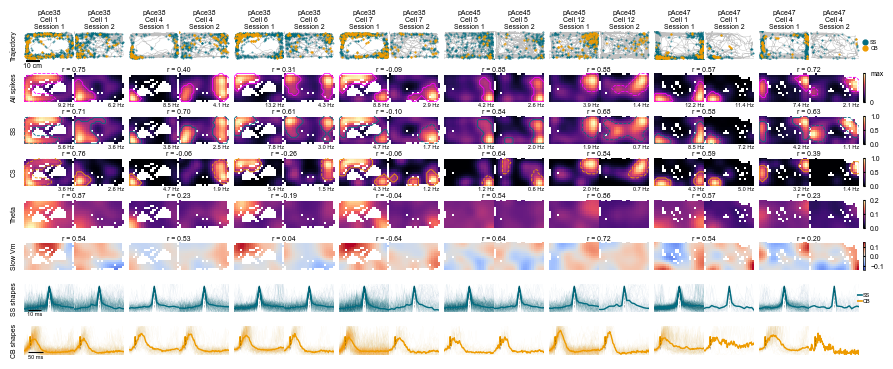

Plotting CS- comparison (n=5 cells, 2 conditions each, max 10/fig)
  Rendering CS-: n=5 -> spatial_compare_csminus_s1_s2.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_csminus_s1_s2.svg


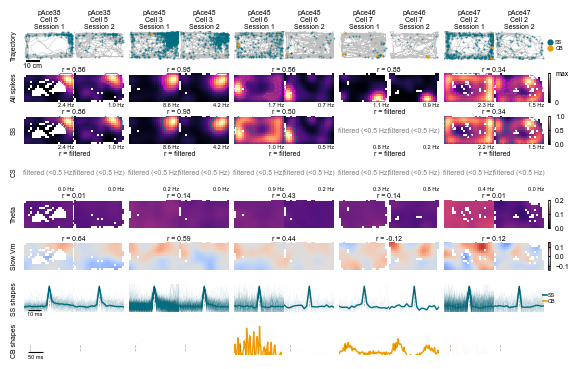

Plotting Non-PLC comparison (n=14 cells, 2 conditions each, max 10/fig)
  Rendering Non-PLC part 1/2: n=10 -> spatial_compare_nonplc_s1_s2_part01.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part01.svg


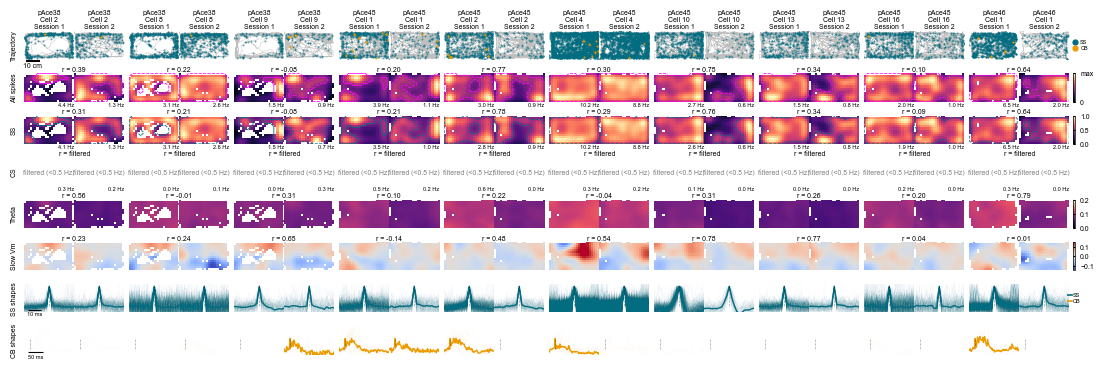

  Rendering Non-PLC part 2/2: n=4 -> spatial_compare_nonplc_s1_s2_part02.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part02.svg


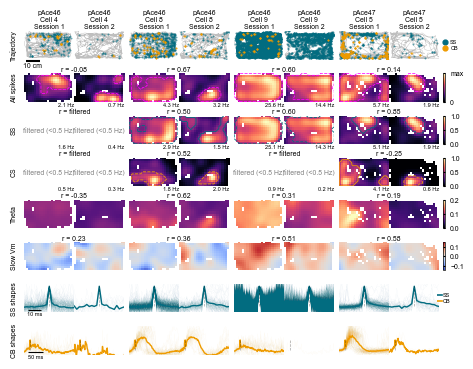

In [33]:

# Render figures
plot_putative_PF = True
pf_only_place_cells = False
show_place_cell_star = True
show_significance_marker = True

def _chunk_groups(groups, max_cells):
    if max_cells is None or max_cells <= 0:
        yield 1, groups
        return
    n = len(groups)
    if n == 0:
        return
    part = 1
    for i in range(0, n, max_cells):
        yield part, groups[i:i + max_cells]
        part += 1

def _render_group_set(groups, label, filename_base):
    n_cells = len(groups)
    if n_cells == 0:
        print(f"Skipping {label}: no cells")
        return []

    chunks = list(_chunk_groups(groups, MAX_CELLS_PER_FIG))
    n_parts = len(chunks)
    print(f"Plotting {label} comparison (n={n_cells} cells, {len(CONDITIONS)} conditions each, max {MAX_CELLS_PER_FIG}/fig)")

    saved_paths = []
    for part_idx, chunk in chunks:
        if n_parts == 1:
            out_name = f"{filename_base}.svg"
            part_msg = ""
        else:
            out_name = f"{filename_base}_part{part_idx:02d}.svg"
            part_msg = f" part {part_idx}/{n_parts}"

        out_path = os.path.join(FIGURE_SAVE_FOLDER, out_name)
        print(f"  Rendering {label}{part_msg}: n={len(chunk)} -> {out_name}")
        _ = plot_selected_cells_figure(
            cell_groups=chunk,
            theta_vlim=selected_theta_vlim,
            slow_vlim=selected_slow_vlim,
            save_path=out_path,
            plot_putative_PF=plot_putative_PF,
            pf_only_place_cells=pf_only_place_cells,
            show_place_cell_star=show_place_cell_star,
            show_significance_marker=show_significance_marker,
            overlay_similarity_metric=HEATMAP_SIMILARITY_METRIC,
            clean_heatmap=CLEAN_HEATMAP,
            plot_spike_shapes=PLOT_SPIKE_SHAPES,
            plot_spike_shapes_overall=PLOT_SPIKE_SHAPES_OVERALL,
            plot_spike_shapes_in_field=PLOT_SPIKE_SHAPES_IN_FIELD,
            plot_spike_shapes_out_field=PLOT_SPIKE_SHAPES_OUT_FIELD,
            show_shape_counts=False,
        )
        saved_paths.append(out_path)

    return saved_paths

panel_suffix = 'combined_s1_s2' if INCLUDE_COMBINED_MAP else 's1_s2'
saved_csplus = _render_group_set(csplus_groups, 'CS+', f'spatial_compare_csplus_{panel_suffix}')
saved_csminus = _render_group_set(csminus_groups, 'CS-', f'spatial_compare_csminus_{panel_suffix}')
saved_nonplc = _render_group_set(nonpc_groups, 'Non-PLC', f'spatial_compare_nonplc_{panel_suffix}')


In [34]:

# QA summary
n_datasets = len(dataset_registry)
n_has_s2 = sum(1 for d in dataset_registry if d['has_session2'])
n_no_s2 = n_datasets - n_has_s2

print('=== Spatial Session Compare Summary ===')
print(f'Total datasets: {n_datasets}')
print(f'Datasets with session 2: {n_has_s2}')
print(f'Datasets without session 2: {n_no_s2}')
print(f'Total valid spatial cells: {len(valid_spatial_cells)}')
print(f'CS+ count (combined labels): {len(csplus_keys)}')
print(f'CS- count (combined labels): {len(csminus_keys)}')
print(f'Non-PLC count (combined labels): {len(nonpc_keys)}')
print(f'Rendered CS+ rows: {len(csplus_groups)}')
print(f'Rendered CS- rows: {len(csminus_groups)}')
print(f'Rendered Non-PLC rows: {len(nonpc_groups)}')
print(f'Rendered rows with session2 N/A (CS+): {csplus_missing_s2}')
print(f'Rendered rows with session2 N/A (CS-): {csminus_missing_s2}')
print(f'Rendered rows with session2 N/A (Non-PLC): {nonpc_missing_s2}')

print(f'Max cells per figure: {MAX_CELLS_PER_FIG}')
print(f'CS+ figures saved: {len(saved_csplus) if "saved_csplus" in globals() else 0}')
print(f'CS- figures saved: {len(saved_csminus) if "saved_csminus" in globals() else 0}')
print(f'Non-PLC figures saved: {len(saved_nonplc) if "saved_nonplc" in globals() else 0}')


=== Spatial Session Compare Summary ===
Total datasets: 4
Datasets with session 2: 4
Datasets without session 2: 0
Total valid spatial cells: 39
CS+ count (combined labels): 9
CS- count (combined labels): 6
Non-PLC count (combined labels): 24
Rendered CS+ rows: 8
Rendered CS- rows: 5
Rendered Non-PLC rows: 14
Rendered rows with session2 N/A (CS+): 0
Rendered rows with session2 N/A (CS-): 0
Rendered rows with session2 N/A (Non-PLC): 0
Max cells per figure: 10
CS+ figures saved: 1
CS- figures saved: 1
Non-PLC figures saved: 2


Low-SS outlier filter enabled: False (threshold=0.1)
Removed outlier cells: 0

=== All-Spike Maps (session1 vs session2) ===


,group,n_total_cells,n_with_session1_and_2,n_valid_corr,mean_r,median_r,std_r
0,CS+,9,9,8,0.585016,0.639723,0.283322
1,CS-,6,6,5,0.717404,0.835701,0.273673



=== Simple-Spike Maps (session1 vs session2) ===


,group,n_total_cells,n_with_session1_and_2,n_valid_corr,mean_r,median_r,std_r
0,CS+,9,9,8,0.598685,0.667429,0.238765
1,CS-,6,6,4,0.669374,0.696318,0.299453



=== Complex-Spike Maps (session1 vs session2, CS+ only) ===


,group,n_total_cells,n_with_session1_and_2,n_valid_corr,mean_r,median_r,std_r
0,CS+,9,9,8,0.386144,0.524161,0.38342


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_map_correlations.svg
CS+ SS vs CS test: paired_t, p=0.1656 (n=8; Shapiro diff p=0.1535)
All-map CS+ vs CS- test: welch_t, p=0.4245 (Shapiro CS+ p=0.3249, CS- p=0.4526)
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_map_correlations.csv


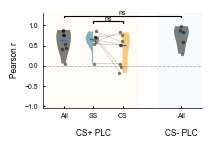

In [35]:
# Session 1 vs Session 2 map correlations
# 1) All-spike maps: CS+ vs CS-
# 2) Simple-spike maps: CS+ vs CS-
# 3) Complex-spike maps: CS+ only

MIN_VALID_BINS_FOR_CORR = 20

def _get_session_pair_cell(dataset_id, cell_idx):
    c1 = _get_condition_cell(dataset_id, cell_idx, 'session1')
    c2 = _get_condition_cell(dataset_id, cell_idx, 'session2')
    if c1 is None or c2 is None:
        return None, None
    c1 = copy.deepcopy(c1)
    c2 = copy.deepcopy(c2)
    # Ensure SS/CS normalized maps are condition-local before correlation.
    _renormalize_ss_cs_maps_per_condition(c1)
    _renormalize_ss_cs_maps_per_condition(c2)
    return c1, c2

def _map_pair_corr(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))

    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n_valid

    r = float(np.corrcoef(x, y)[0, 1])
    return r, n_valid

def _collect_session_corrs(cell_keys, map_key, group_label):
    rows = []
    for dataset_id, cell_idx in cell_keys:
        c1, c2 = _get_session_pair_cell(dataset_id, cell_idx)
        has_both_sessions = (c1 is not None) and (c2 is not None)

        if not has_both_sessions:
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'has_both_sessions': False,
                'n_valid_bins': 0,
                'corr_r': np.nan,
            })
            continue

        # Peak-rate gate for S1 vs S2 comparison
        if bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)):
            thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
            if not _passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key=map_key, threshold=thr):
                rows.append({
                    'dataset_id': dataset_id,
                    'cell_idx': int(cell_idx),
                    'group': group_label,
                    'map_key': map_key,
                    'has_both_sessions': True,
                    'n_valid_bins': 0,
                    'corr_r': np.nan,
                })
                continue

        r, n_valid = _map_pair_corr(
            c1.get(map_key, None),
            c2.get(map_key, None),
            min_valid_bins=MIN_VALID_BINS_FOR_CORR,
        )

        rows.append({
            'dataset_id': dataset_id,
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'has_both_sessions': True,
            'n_valid_bins': int(n_valid),
            'corr_r': r,
        })

    return pd.DataFrame(rows)

def _summarize_corr_df(df, title):
    print(f"\n=== {title} ===")
    if df is None or len(df) == 0:
        print('No rows')
        return

    out_rows = []
    for g in sorted(df['group'].unique()):
        dfg = df[df['group'] == g].copy()
        n_total = int(len(dfg))
        n_with_s2 = int(dfg['has_both_sessions'].sum())
        dfg_valid = dfg[np.isfinite(dfg['corr_r'])]
        n_valid = int(len(dfg_valid))
        mean_r = float(np.nanmean(dfg_valid['corr_r'])) if n_valid > 0 else np.nan
        med_r = float(np.nanmedian(dfg_valid['corr_r'])) if n_valid > 0 else np.nan
        std_r = float(np.nanstd(dfg_valid['corr_r'], ddof=1)) if n_valid > 1 else np.nan

        out_rows.append({
            'group': g,
            'n_total_cells': n_total,
            'n_with_session1_and_2': n_with_s2,
            'n_valid_corr': n_valid,
            'mean_r': mean_r,
            'median_r': med_r,
            'std_r': std_r,
        })

    display(pd.DataFrame(out_rows))

# ---------------------------
# 1) All-spike map correlations
# ---------------------------
df_all_csplus = _collect_session_corrs(csplus_keys, 'rate_map', 'CS+')
df_all_csminus = _collect_session_corrs(csminus_keys, 'rate_map', 'CS-')
df_all_map = pd.concat([df_all_csplus, df_all_csminus], ignore_index=True)

# -----------------------------
# 2) Simple-spike map correlations
# -----------------------------
df_ss_csplus = _collect_session_corrs(csplus_keys, 'ss_norm_map', 'CS+')
df_ss_csminus = _collect_session_corrs(csminus_keys, 'ss_norm_map', 'CS-')
df_ss_map = pd.concat([df_ss_csplus, df_ss_csminus], ignore_index=True)

# ------------------------------
# 3) Complex-spike map correlations (CS+ only)
# ------------------------------
df_cs_map = _collect_session_corrs(csplus_keys, 'cs_norm_map', 'CS+')


def _row_keys(df):
    if df is None or len(df) == 0:
        return []
    return list(zip(df['dataset_id'].astype(str), df['cell_idx'].astype(int)))


def _exclude_rows_by_keys(df, exclude_keys):
    if df is None:
        return df
    if not exclude_keys or len(df) == 0:
        return df.copy()
    keep_mask = [k not in exclude_keys for k in _row_keys(df)]
    return df.loc[np.asarray(keep_mask, dtype=bool)].reset_index(drop=True)


# Optional outlier removal by low SS-map correlation
REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))

outlier_keys = set()
if REMOVE_LOW_SS_OUTLIER_LOCAL:
    outlier_df = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < SS_R_OUTLIER_THRESHOLD_LOCAL)]
    outlier_keys = set(_row_keys(outlier_df))

    if len(outlier_keys) > 0:
        df_all_csplus = _exclude_rows_by_keys(df_all_csplus, outlier_keys)
        df_all_csminus = _exclude_rows_by_keys(df_all_csminus, outlier_keys)
        df_ss_csplus = _exclude_rows_by_keys(df_ss_csplus, outlier_keys)
        df_ss_csminus = _exclude_rows_by_keys(df_ss_csminus, outlier_keys)
        df_cs_map = _exclude_rows_by_keys(df_cs_map, outlier_keys)

    df_all_map = pd.concat([df_all_csplus, df_all_csminus], ignore_index=True)
    df_ss_map = pd.concat([df_ss_csplus, df_ss_csminus], ignore_index=True)

print(f"Low-SS outlier filter enabled: {REMOVE_LOW_SS_OUTLIER_LOCAL} (threshold={SS_R_OUTLIER_THRESHOLD_LOCAL})")
print(f"Removed outlier cells: {len(outlier_keys)}")

_summarize_corr_df(df_all_map, 'All-Spike Maps (session1 vs session2)')
_summarize_corr_df(df_ss_map, 'Simple-Spike Maps (session1 vs session2)')
_summarize_corr_df(df_cs_map, 'Complex-Spike Maps (session1 vs session2, CS+ only)')


# Combine 1-4 style grouped visualization
all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'
cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))

VIOLIN_MEDIAN_COLOR = '#1F77B4'
VIOLIN_MEDIAN_LINEWIDTH = 1.0


def _style_violin_medians(parts, color=None, linewidth=None):
    if color is None:
        color = VIOLIN_MEDIAN_COLOR
    if linewidth is None:
        linewidth = VIOLIN_MEDIAN_LINEWIDTH
    if 'cmedians' in parts:
        parts['cmedians'].set_color(color)
        parts['cmedians'].set_linewidth(linewidth)


def _finite_values(df):
    arr = np.asarray(df['corr_r'], dtype=float)
    return arr[np.isfinite(arr)]


def _paired_valid(df_a, df_b):
    ma = df_a[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'a'})
    mb = df_b[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'b'})
    m = ma.merge(mb, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['a']) & np.isfinite(m['b'])]
    return m


try:
    import scipy.stats as scipy_stats
except Exception:
    scipy_stats = None


def _shapiro_p_safe(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        # Shapiro is most stable up to ~5000 samples.
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_unpaired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = int(x.size), int(y.size)
    if scipy_stats is None or n1 < 2 or n2 < 2:
        return np.nan, 'n/a', np.nan, np.nan

    shapiro_p1 = _shapiro_p_safe(x)
    shapiro_p2 = _shapiro_p_safe(y)

    can_parametric = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(shapiro_p1) and shapiro_p1 >= alpha and
        np.isfinite(shapiro_p2) and shapiro_p2 >= alpha
    )

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', shapiro_p1, shapiro_p2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', shapiro_p1, shapiro_p2
    except Exception:
        return np.nan, 'mannwhitney_u', shapiro_p1, shapiro_p2


def _auto_paired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = int(x.size)
    if scipy_stats is None or n < 2:
        return np.nan, 'n/a', np.nan

    shapiro_p = _shapiro_p_safe(x - y)
    can_parametric = (n >= 5 and np.isfinite(shapiro_p) and shapiro_p >= alpha)

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', shapiro_p
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', shapiro_p
    except Exception:
        return np.nan, 'wilcoxon', shapiro_p


def _p_value_unpaired(x, y):
    return _auto_unpaired_test(x, y, alpha=0.05)


def _p_value_paired(x, y):
    return _auto_paired_test(x, y, alpha=0.05)


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def add_bracket(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


all_csplus_vals = _finite_values(df_all_csplus)
all_csminus_vals = _finite_values(df_all_csminus)
ss_csplus_vals = _finite_values(df_ss_csplus)
cs_csplus_vals = _finite_values(df_cs_map)

paired_ss_cs = _paired_valid(df_ss_csplus, df_cs_map)
p_ss_vs_cs, paired_test_name, paired_shapiro_p = _p_value_paired(paired_ss_cs['a'].to_numpy(dtype=float), paired_ss_cs['b'].to_numpy(dtype=float))
p_all_csplus_vs_csminus, unpaired_test_name, unpaired_shapiro_p1, unpaired_shapiro_p2 = _p_value_unpaired(all_csplus_vals, all_csminus_vals)

panel_w, panel_h = 2.1, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

# Background shading and group labels (Combine 1-4 style)
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
ax.axvspan(4.2, 5.8, alpha=0.3, color=non_cs_plc_bg_local, zorder=0)
ax.text(2.0, -0.22, 'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5.0, -0.22, 'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

# Violin bodies
_draw_violin(ax, all_csplus_vals, 1.0, all_color, half=None, alpha=0.5)
_draw_violin(ax, ss_csplus_vals, 2.0, ss_color, half='left', alpha=0.5)
_draw_violin(ax, cs_csplus_vals, 3.0, cs_color, half='right', alpha=0.5)
_draw_violin(ax, all_csminus_vals, 5.0, all_color, half=None, alpha=0.5)

# Paired lines for CS+ SS vs CS
if len(paired_ss_cs) > 0:
    a = paired_ss_cs['a'].to_numpy(dtype=float)
    b = paired_ss_cs['b'].to_numpy(dtype=float)
    for va, vb in zip(a, b):
        ax.plot([2.08, 2.92], [va, vb], color='black', alpha=0.2, linewidth=0.5, zorder=2)

# Dots
_scatter_side(ax, all_csplus_vals, 1.0, direction='center', rng_seed=1)
_scatter_side(ax, ss_csplus_vals, 2.0, direction='right', rng_seed=2)
_scatter_side(ax, cs_csplus_vals, 3.0, direction='left', rng_seed=3)
_scatter_side(ax, all_csminus_vals, 5.0, direction='center', rng_seed=4)

ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_ylabel('Pearson r', fontsize=6, fontname='Arial')
ax.set_xticks([1.0, 2.0, 3.0, 5.0])
ax.set_xticklabels(['All', 'SS', 'CS', 'All'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 5.7)
ax.tick_params(axis='both', labelsize=5)
for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    label.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Brackets and significance labels
plot_max = np.nanmax(np.concatenate([
    all_csplus_vals if len(all_csplus_vals) else np.array([-1.0]),
    ss_csplus_vals if len(ss_csplus_vals) else np.array([-1.0]),
    cs_csplus_vals if len(cs_csplus_vals) else np.array([-1.0]),
    all_csminus_vals if len(all_csminus_vals) else np.array([-1.0]),
]))
y_top = max(0.85, float(plot_max) + 0.08)
h = 0.04
add_bracket(ax, 2.0, 3.0, y_top, h, _sig_label(p_ss_vs_cs), color='black')
add_bracket(ax, 1.0, 5.0, y_top + 0.14, h, _sig_label(p_all_csplus_vs_csminus), color=all_color)
ax.set_ylim(-1.05, y_top + 0.26)

plt.tight_layout()
corr_fig_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_map_correlations.svg')
fig.savefig(corr_fig_path, dpi=300)
print(f"Saved: {corr_fig_path}")
print(f"CS+ SS vs CS test: {paired_test_name}, p={p_ss_vs_cs:.4g} (n={len(paired_ss_cs)}; Shapiro diff p={paired_shapiro_p:.4g})")
print(f"All-map CS+ vs CS- test: {unpaired_test_name}, p={p_all_csplus_vs_csminus:.4g} (Shapiro CS+ p={unpaired_shapiro_p1:.4g}, CS- p={unpaired_shapiro_p2:.4g})")

# Save tables for downstream stats if needed
corr_table_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_map_correlations.csv')
df_out = pd.concat([
    df_all_map.assign(metric='all_spike_map'),
    df_ss_map.assign(metric='simple_spike_map'),
    df_cs_map.assign(metric='complex_spike_map'),
], ignore_index=True)
df_out.to_csv(corr_table_path, index=False)
print(f"Saved: {corr_table_path}")


Low-SS outlier filter enabled: False (threshold=0.1)
Weighted analysis outlier source: weighted_ss_map
Removed outlier cells: 0
Remaining weighted SS r below threshold after filtering: 1

=== Occupancy-weighted All-Spike Maps (session1 vs session2) ===


,group,n_total_cells,n_with_session1_and_2,n_valid_weighted_corr,mean_weighted_r,median_weighted_r,mean_n_eff
0,CS+,9,9,8,0.552149,0.644774,224.249549
1,CS-,6,6,5,0.724217,0.858648,246.191865



=== Occupancy-weighted Simple-Spike Maps (session1 vs session2) ===


,group,n_total_cells,n_with_session1_and_2,n_valid_weighted_corr,mean_weighted_r,median_weighted_r,mean_n_eff
0,CS+,9,9,8,0.581496,0.654876,224.249549
1,CS-,6,6,4,0.671754,0.681176,245.166550



=== Occupancy-weighted Complex-Spike Maps (session1 vs session2, CS+ only) ===


,group,n_total_cells,n_with_session1_and_2,n_valid_weighted_corr,mean_weighted_r,median_weighted_r,mean_n_eff
0,CS+,9,9,8,0.355412,0.486669,224.249549


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_map_correlations_weighted.svg
Weighted CS+ SS vs CS test: paired_t, p=0.1438 (n=8; Shapiro diff p=0.0795)
Weighted All-map CS+ vs CS- test: welch_t, p=0.3268 (Shapiro CS+ p=0.3016, CS- p=0.3858)
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_map_correlations_weighted.csv


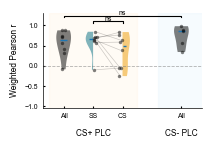

In [36]:
# Session 1 vs Session 2 map correlations (occupancy-weighted Pearson r)
# Weight per bin: min(occupancy_session1, occupancy_session2)

MIN_VALID_BINS_FOR_CORR_WEIGHTED = 20
MIN_EFFECTIVE_BINS_WEIGHTED = 20
MIN_OCCUPANCY_WEIGHT = 0.0


def _weighted_pearson_2d(map1, map2, occ1, occ2,
                         min_occ=0.0,
                         min_valid_bins=20,
                         min_eff_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0, 0.0
    if not isinstance(occ1, np.ndarray) or not isinstance(occ2, np.ndarray):
        return np.nan, 0, 0.0
    if map1.shape != map2.shape or map1.shape != occ1.shape or map1.shape != occ2.shape:
        return np.nan, 0, 0.0

    x = np.asarray(map1, dtype=float).ravel()
    y = np.asarray(map2, dtype=float).ravel()
    w = np.minimum(np.asarray(occ1, dtype=float).ravel(), np.asarray(occ2, dtype=float).ravel())

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > float(min_occ))
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid, 0.0

    x = x[valid]
    y = y[valid]
    w = w[valid]

    sw = float(np.sum(w))
    if sw <= 0:
        return np.nan, n_valid, 0.0

    mx = float(np.sum(w * x) / sw)
    my = float(np.sum(w * y) / sw)
    dx = x - mx
    dy = y - my

    num = float(np.sum(w * dx * dy))
    den_x = float(np.sum(w * dx * dx))
    den_y = float(np.sum(w * dy * dy))
    den = np.sqrt(den_x * den_y)
    if den <= 0:
        return np.nan, n_valid, 0.0

    # Effective sample size under unequal weights
    sw2 = float(np.sum(w * w))
    n_eff = (sw * sw / sw2) if sw2 > 0 else 0.0
    if n_eff < float(min_eff_bins):
        return np.nan, n_valid, n_eff

    r_w = num / den
    return float(r_w), n_valid, float(n_eff)


def _collect_weighted_session_corrs(cell_keys, map_key, group_label):
    rows = []
    for dataset_id, cell_idx in cell_keys:
        c1 = _get_condition_cell(dataset_id, cell_idx, 'session1')
        c2 = _get_condition_cell(dataset_id, cell_idx, 'session2')

        if c1 is None or c2 is None:
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'has_both_sessions': False,
                'n_valid_bins': 0,
                'n_eff_bins': 0.0,
                'corr_r_weighted': np.nan,
            })
            continue

        # Peak-rate gate for S1 vs S2 comparison
        if bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)):
            thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
            if not _passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key=map_key, threshold=thr):
                rows.append({
                    'dataset_id': dataset_id,
                    'cell_idx': int(cell_idx),
                    'group': group_label,
                    'map_key': map_key,
                    'has_both_sessions': True,
                    'n_valid_bins': 0,
                    'n_eff_bins': 0.0,
                    'corr_r_weighted': np.nan,
                })
                continue

        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)
        _renormalize_ss_cs_maps_per_condition(c1)
        _renormalize_ss_cs_maps_per_condition(c2)

        r_w, n_valid, n_eff = _weighted_pearson_2d(
            c1.get(map_key, None),
            c2.get(map_key, None),
            c1.get('occupancy', None),
            c2.get('occupancy', None),
            min_occ=MIN_OCCUPANCY_WEIGHT,
            min_valid_bins=MIN_VALID_BINS_FOR_CORR_WEIGHTED,
            min_eff_bins=MIN_EFFECTIVE_BINS_WEIGHTED,
        )

        rows.append({
            'dataset_id': dataset_id,
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'has_both_sessions': True,
            'n_valid_bins': int(n_valid),
            'n_eff_bins': float(n_eff),
            'corr_r_weighted': r_w,
        })

    return pd.DataFrame(rows)


def _summarize_weighted_corr_df(df, title):
    print(f"\n=== {title} ===")
    if df is None or len(df) == 0:
        print('No rows')
        return

    out_rows = []
    for g in sorted(df['group'].unique()):
        dfg = df[df['group'] == g].copy()
        n_total = int(len(dfg))
        n_with_s2 = int(dfg['has_both_sessions'].sum())
        dfg_valid = dfg[np.isfinite(dfg['corr_r_weighted'])]
        n_valid = int(len(dfg_valid))
        mean_r = float(np.nanmean(dfg_valid['corr_r_weighted'])) if n_valid > 0 else np.nan
        med_r = float(np.nanmedian(dfg_valid['corr_r_weighted'])) if n_valid > 0 else np.nan
        mean_neff = float(np.nanmean(dfg_valid['n_eff_bins'])) if n_valid > 0 else np.nan

        out_rows.append({
            'group': g,
            'n_total_cells': n_total,
            'n_with_session1_and_2': n_with_s2,
            'n_valid_weighted_corr': n_valid,
            'mean_weighted_r': mean_r,
            'median_weighted_r': med_r,
            'mean_n_eff': mean_neff,
        })

    display(pd.DataFrame(out_rows))


# Compute weighted correlations for the same map sets
w_all_csplus = _collect_weighted_session_corrs(csplus_keys, 'rate_map', 'CS+')
w_all_csminus = _collect_weighted_session_corrs(csminus_keys, 'rate_map', 'CS-')
df_all_map_w = pd.concat([w_all_csplus, w_all_csminus], ignore_index=True)

w_ss_csplus = _collect_weighted_session_corrs(csplus_keys, 'ss_norm_map', 'CS+')
w_ss_csminus = _collect_weighted_session_corrs(csminus_keys, 'ss_norm_map', 'CS-')
df_ss_map_w = pd.concat([w_ss_csplus, w_ss_csminus], ignore_index=True)

w_cs_map = _collect_weighted_session_corrs(csplus_keys, 'cs_norm_map', 'CS+')


def _row_keys_w(df):
    if df is None or len(df) == 0:
        return []
    return list(zip(df['dataset_id'].astype(str), df['cell_idx'].astype(int)))


def _exclude_rows_by_keys_w(df, exclude_keys):
    if df is None:
        return df
    if not exclude_keys or len(df) == 0:
        return df.copy()
    keep_mask = [k not in exclude_keys for k in _row_keys_w(df)]
    return df.loc[np.asarray(keep_mask, dtype=bool)].reset_index(drop=True)


REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))

outlier_keys_w = set()
if REMOVE_LOW_SS_OUTLIER_LOCAL:
    # Weighted figure should be filtered by weighted SS map r directly.
    outlier_df_w = df_ss_map_w[
        np.isfinite(df_ss_map_w['corr_r_weighted'])
        & (df_ss_map_w['corr_r_weighted'] < SS_R_OUTLIER_THRESHOLD_LOCAL)
    ]
    outlier_keys_w = set(_row_keys_w(outlier_df_w))

    if len(outlier_keys_w) > 0:
        w_all_csplus = _exclude_rows_by_keys_w(w_all_csplus, outlier_keys_w)
        w_all_csminus = _exclude_rows_by_keys_w(w_all_csminus, outlier_keys_w)
        w_ss_csplus = _exclude_rows_by_keys_w(w_ss_csplus, outlier_keys_w)
        w_ss_csminus = _exclude_rows_by_keys_w(w_ss_csminus, outlier_keys_w)
        w_cs_map = _exclude_rows_by_keys_w(w_cs_map, outlier_keys_w)

    df_all_map_w = pd.concat([w_all_csplus, w_all_csminus], ignore_index=True)
    df_ss_map_w = pd.concat([w_ss_csplus, w_ss_csminus], ignore_index=True)

print(f"Low-SS outlier filter enabled: {REMOVE_LOW_SS_OUTLIER_LOCAL} (threshold={SS_R_OUTLIER_THRESHOLD_LOCAL})")
print(f"Weighted analysis outlier source: weighted_ss_map")
print(f"Removed outlier cells: {len(outlier_keys_w)}")
remaining_low_ss_w = int(np.sum(np.isfinite(df_ss_map_w['corr_r_weighted']) & (df_ss_map_w['corr_r_weighted'] < SS_R_OUTLIER_THRESHOLD_LOCAL)))
print(f"Remaining weighted SS r below threshold after filtering: {remaining_low_ss_w}")

_summarize_weighted_corr_df(df_all_map_w, 'Occupancy-weighted All-Spike Maps (session1 vs session2)')
_summarize_weighted_corr_df(df_ss_map_w, 'Occupancy-weighted Simple-Spike Maps (session1 vs session2)')
_summarize_weighted_corr_df(w_cs_map, 'Occupancy-weighted Complex-Spike Maps (session1 vs session2, CS+ only)')


# ---- Figure (same layout style as the unweighted grouped panel) ----
all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'
cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))

if '_style_violin_medians' not in globals():
    def _style_violin_medians(parts, color='#1F77B4', linewidth=1.0):
        if 'cmedians' in parts:
            parts['cmedians'].set_color(color)
            parts['cmedians'].set_linewidth(linewidth)


def _finite_weighted(df):
    arr = np.asarray(df['corr_r_weighted'], dtype=float)
    return arr[np.isfinite(arr)]


def _paired_weighted(df_a, df_b):
    ma = df_a[['dataset_id', 'cell_idx', 'corr_r_weighted']].rename(columns={'corr_r_weighted': 'a'})
    mb = df_b[['dataset_id', 'cell_idx', 'corr_r_weighted']].rename(columns={'corr_r_weighted': 'b'})
    m = ma.merge(mb, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['a']) & np.isfinite(m['b'])]
    return m


try:
    import scipy.stats as scipy_stats
except Exception:
    scipy_stats = None


def _shapiro_p_safe(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        # Shapiro is most stable up to ~5000 samples.
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_unpaired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = int(x.size), int(y.size)
    if scipy_stats is None or n1 < 2 or n2 < 2:
        return np.nan, 'n/a', np.nan, np.nan

    shapiro_p1 = _shapiro_p_safe(x)
    shapiro_p2 = _shapiro_p_safe(y)

    can_parametric = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(shapiro_p1) and shapiro_p1 >= alpha and
        np.isfinite(shapiro_p2) and shapiro_p2 >= alpha
    )

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', shapiro_p1, shapiro_p2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', shapiro_p1, shapiro_p2
    except Exception:
        return np.nan, 'mannwhitney_u', shapiro_p1, shapiro_p2


def _auto_paired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = int(x.size)
    if scipy_stats is None or n < 2:
        return np.nan, 'n/a', np.nan

    shapiro_p = _shapiro_p_safe(x - y)
    can_parametric = (n >= 5 and np.isfinite(shapiro_p) and shapiro_p >= alpha)

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', shapiro_p
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', shapiro_p
    except Exception:
        return np.nan, 'wilcoxon', shapiro_p


def _p_value_unpaired(x, y):
    return _auto_unpaired_test(x, y, alpha=0.05)


def _p_value_paired(x, y):
    return _auto_paired_test(x, y, alpha=0.05)


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def add_bracket(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


all_csplus_w = _finite_weighted(w_all_csplus)
all_csminus_w = _finite_weighted(w_all_csminus)
ss_csplus_w = _finite_weighted(w_ss_csplus)
cs_csplus_w = _finite_weighted(w_cs_map)

paired_w = _paired_weighted(w_ss_csplus, w_cs_map)
p_ss_vs_cs_w, paired_test_name_w, paired_shapiro_p_w = _p_value_paired(paired_w['a'].to_numpy(dtype=float), paired_w['b'].to_numpy(dtype=float))
p_all_csplus_vs_csminus_w, unpaired_test_name_w, unpaired_shapiro_p1_w, unpaired_shapiro_p2_w = _p_value_unpaired(all_csplus_w, all_csminus_w)

panel_w, panel_h = 2.1, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
ax.axvspan(4.2, 5.8, alpha=0.3, color=non_cs_plc_bg_local, zorder=0)
ax.text(2.0, -0.22, 'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5.0, -0.22, 'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

_draw_violin(ax, all_csplus_w, 1.0, all_color, half=None, alpha=0.5)
_draw_violin(ax, ss_csplus_w, 2.0, ss_color, half='left', alpha=0.5)
_draw_violin(ax, cs_csplus_w, 3.0, cs_color, half='right', alpha=0.5)
_draw_violin(ax, all_csminus_w, 5.0, all_color, half=None, alpha=0.5)

if len(paired_w) > 0:
    a = paired_w['a'].to_numpy(dtype=float)
    b = paired_w['b'].to_numpy(dtype=float)
    for va, vb in zip(a, b):
        ax.plot([2.08, 2.92], [va, vb], color='black', alpha=0.2, linewidth=0.5, zorder=2)

_scatter_side(ax, all_csplus_w, 1.0, direction='center', rng_seed=11)
_scatter_side(ax, ss_csplus_w, 2.0, direction='right', rng_seed=12)
_scatter_side(ax, cs_csplus_w, 3.0, direction='left', rng_seed=13)
_scatter_side(ax, all_csminus_w, 5.0, direction='center', rng_seed=14)

ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_ylabel('Weighted Pearson r', fontsize=6, fontname='Arial')
ax.set_xticks([1.0, 2.0, 3.0, 5.0])
ax.set_xticklabels(['All', 'SS', 'CS', 'All'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 5.7)
ax.tick_params(axis='both', labelsize=5)
for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    label.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plot_max = np.nanmax(np.concatenate([
    all_csplus_w if len(all_csplus_w) else np.array([-1.0]),
    ss_csplus_w if len(ss_csplus_w) else np.array([-1.0]),
    cs_csplus_w if len(cs_csplus_w) else np.array([-1.0]),
    all_csminus_w if len(all_csminus_w) else np.array([-1.0]),
]))
y_top = max(0.85, float(plot_max) + 0.08)
h = 0.04
add_bracket(ax, 2.0, 3.0, y_top, h, _sig_label(p_ss_vs_cs_w), color='black')
add_bracket(ax, 1.0, 5.0, y_top + 0.14, h, _sig_label(p_all_csplus_vs_csminus_w), color=all_color)
ax.set_ylim(-1.05, y_top + 0.26)

plt.tight_layout()
weighted_fig_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_map_correlations_weighted.svg')
fig.savefig(weighted_fig_path, dpi=300)
print(f"Saved: {weighted_fig_path}")
print(f"Weighted CS+ SS vs CS test: {paired_test_name_w}, p={p_ss_vs_cs_w:.4g} (n={len(paired_w)}; Shapiro diff p={paired_shapiro_p_w:.4g})")
print(f"Weighted All-map CS+ vs CS- test: {unpaired_test_name_w}, p={p_all_csplus_vs_csminus_w:.4g} (Shapiro CS+ p={unpaired_shapiro_p1_w:.4g}, CS- p={unpaired_shapiro_p2_w:.4g})")

weighted_table_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_map_correlations_weighted.csv')
df_out_w = pd.concat([
    df_all_map_w.assign(metric='all_spike_map'),
    df_ss_map_w.assign(metric='simple_spike_map'),
    w_cs_map.assign(metric='complex_spike_map'),
], ignore_index=True)
df_out_w.to_csv(weighted_table_path, index=False)
print(f"Saved: {weighted_table_path}")


In [37]:
# # CS+ PLC + CS+ spatially tuned non-PLC analysis
# # Spatially tuned non-PLC = SI-shuffle significant ('*') but not place cell.

# SI_ALPHA = 0.05
# MIN_VALID_BINS_FOR_CORR_EXT = 20


# def _get_combined_cell_record(key):
#     if 'combined_cell_map' in globals() and isinstance(combined_cell_map, dict):
#         c = combined_cell_map.get(key, None)
#         if c is not None:
#             return c
#     ds, idx = key
#     if '_get_condition_cell' in globals():
#         return _get_condition_cell(ds, idx, 'combined')
#     return None


# def _cb_in_pf_count_for_key(key, cell):
#     if 'cb_in_pf_counts' in globals() and isinstance(cb_in_pf_counts, dict):
#         if key in cb_in_pf_counts:
#             try:
#                 return int(cb_in_pf_counts[key])
#             except Exception:
#                 pass

#     n_in = 0
#     if isinstance(cell, dict):
#         spike_shapes = cell.get('spike_shapes', None)
#         if isinstance(spike_shapes, dict) and 'complex' in spike_shapes:
#             shapes = spike_shapes.get('complex', {}).get('shapes', {})
#             n_in = len(shapes.get('run_in', []))
#     return int(n_in)


# def _si_shuffle_pass(cell, alpha=0.05):
#     if not isinstance(cell, dict):
#         return False, None, np.nan

#     p_keys = [
#         'p_value',
#         'si_p_value',
#         'si_shuffle_p',
#         'si_shuffle_p_value',
#         'si_p',
#         'p_si_shuffle',
#         'ss_p_value',
#         'cs_p_value',
#     ]
#     for k in p_keys:
#         if k in cell:
#             try:
#                 v = float(cell.get(k))
#             except Exception:
#                 continue
#             if np.isfinite(v):
#                 return bool(v < alpha), k, v

#     bool_keys = [
#         'si_significant',
#         'si_shuffle_significant',
#         'is_si_significant',
#         'si_is_significant',
#     ]
#     for k in bool_keys:
#         if k in cell:
#             try:
#                 b = bool(cell.get(k))
#                 return b, k, np.nan
#             except Exception:
#                 continue

#     return False, None, np.nan


# # Build non-PLC SI-shuffle significant population and CS+ subset.
# nonpc_spatially_tuned_keys = []
# nonpc_spatially_tuned_meta = []
# si_key_usage = {}

# for key in nonpc_keys:
#     c = _get_combined_cell_record(key)
#     passed, key_used, p_val = _si_shuffle_pass(c, alpha=SI_ALPHA)
#     if passed:
#         ds, idx = key
#         n_cb = _cb_in_pf_count_for_key(key, c)
#         is_csplus_like = bool(n_cb >= CB_NUM_THRESHOLD)
#         nonpc_spatially_tuned_keys.append(key)
#         nonpc_spatially_tuned_meta.append({
#             'dataset_id': ds,
#             'cell_idx': int(idx),
#             'si_key': key_used,
#             'si_p_value': p_val,
#             'cb_in_pf_count': int(n_cb),
#             'is_csplus_like': is_csplus_like,
#         })
#         si_key_usage[key_used] = si_key_usage.get(key_used, 0) + 1

# csplus_tuned_nonpc_keys = sorted([
#     (r['dataset_id'], int(r['cell_idx']))
#     for r in nonpc_spatially_tuned_meta
#     if bool(r['is_csplus_like'])
# ])

# csplus_plc_keys = sorted(csplus_keys)
# combined_csplus_extended_keys = sorted(set(csplus_plc_keys) | set(csplus_tuned_nonpc_keys))

# print('=== CS+ expansion from SI-shuffle-significant non-PLC cells ===')
# print(f'Non-PLC cells total: {len(nonpc_keys)}')
# print(f'Non-PLC SI-shuffle-significant ("*"): {len(nonpc_spatially_tuned_keys)}')
# print(f'Among them CS+ (CB in-PF >= {CB_NUM_THRESHOLD}): {len(csplus_tuned_nonpc_keys)}')
# if len(nonpc_spatially_tuned_keys) > 0:
#     frac = 100.0 * len(csplus_tuned_nonpc_keys) / float(len(nonpc_spatially_tuned_keys))
#     print(f'CS+ fraction within tuned non-PLC: {frac:.1f}%')
# print(f'Original CS+ PLC count: {len(csplus_plc_keys)}')
# print(f'Combined CS+ pool (PLC + tuned non-PLC): {len(combined_csplus_extended_keys)}')

# if len(si_key_usage) > 0:
#     print('SI significance key usage:', si_key_usage)


# # Fallback in case cell 11 was not run.
# if '_collect_session_corrs' not in globals():
#     def _get_session_pair_cell(dataset_id, cell_idx):
#         c1 = _get_condition_cell(dataset_id, cell_idx, 'session1')
#         c2 = _get_condition_cell(dataset_id, cell_idx, 'session2')
#         if c1 is None or c2 is None:
#             return None, None
#         c1 = copy.deepcopy(c1)
#         c2 = copy.deepcopy(c2)
#         _renormalize_ss_cs_maps_per_condition(c1)
#         _renormalize_ss_cs_maps_per_condition(c2)
#         return c1, c2

#     def _map_pair_corr(map1, map2, min_valid_bins=20):
#         if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
#             return np.nan, 0
#         if map1.shape != map2.shape:
#             return np.nan, 0

#         a = np.asarray(map1, dtype=float).ravel()
#         b = np.asarray(map2, dtype=float).ravel()
#         valid = np.isfinite(a) & np.isfinite(b)
#         n_valid = int(np.sum(valid))
#         if n_valid < int(min_valid_bins):
#             return np.nan, n_valid

#         x = a[valid]
#         y = b[valid]
#         if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#             return np.nan, n_valid

#         return float(np.corrcoef(x, y)[0, 1]), n_valid

#     def _collect_session_corrs(cell_keys, map_key, group_label):
#         rows = []
#         for dataset_id, cell_idx in cell_keys:
#             c1, c2 = _get_session_pair_cell(dataset_id, cell_idx)
#             has_both_sessions = (c1 is not None) and (c2 is not None)
#             if not has_both_sessions:
#                 rows.append({
#                     'dataset_id': dataset_id,
#                     'cell_idx': int(cell_idx),
#                     'group': group_label,
#                     'map_key': map_key,
#                     'has_both_sessions': False,
#                     'n_valid_bins': 0,
#                     'corr_r': np.nan,
#                 })
#                 continue

#             r, n_valid = _map_pair_corr(c1.get(map_key, None), c2.get(map_key, None), min_valid_bins=MIN_VALID_BINS_FOR_CORR_EXT)
#             rows.append({
#                 'dataset_id': dataset_id,
#                 'cell_idx': int(cell_idx),
#                 'group': group_label,
#                 'map_key': map_key,
#                 'has_both_sessions': True,
#                 'n_valid_bins': int(n_valid),
#                 'corr_r': r,
#             })
#         return pd.DataFrame(rows)


# # Correlations for expanded CS+ pool
# ext_ss_df = _collect_session_corrs(combined_csplus_extended_keys, 'ss_norm_map', 'CS+ expanded')
# ext_cs_df = _collect_session_corrs(combined_csplus_extended_keys, 'cs_norm_map', 'CS+ expanded')

# # Pair by cell key (same cells for SS and CS comparison)
# ext_ss_pair = ext_ss_df[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'ss_r'})
# ext_cs_pair = ext_cs_df[['dataset_id', 'cell_idx', 'corr_r']].rename(columns={'corr_r': 'cs_r'})
# ext_pair = ext_ss_pair.merge(ext_cs_pair, on=['dataset_id', 'cell_idx'], how='inner')

# valid_pair_mask = np.isfinite(ext_pair['ss_r']) & np.isfinite(ext_pair['cs_r'])
# ext_pair_valid = ext_pair[valid_pair_mask].copy()

# # Optional outlier removal by low SS-map correlation.
# REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
# SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))
# removed_ext = 0
# if REMOVE_LOW_SS_OUTLIER_LOCAL and len(ext_pair_valid) > 0:
#     keep_mask_ext = ~(np.isfinite(ext_pair_valid['ss_r']) & (ext_pair_valid['ss_r'] < SS_R_OUTLIER_THRESHOLD_LOCAL))
#     removed_ext = int(np.sum(~keep_mask_ext))
#     ext_pair_valid = ext_pair_valid.loc[keep_mask_ext].reset_index(drop=True)

# print(f"Low-SS outlier filter enabled: {REMOVE_LOW_SS_OUTLIER_LOCAL} (threshold={SS_R_OUTLIER_THRESHOLD_LOCAL})")
# print(f"Removed outlier cells from expanded CS+ SS-vs-CS comparison: {removed_ext}")

# # Attach source class label for summary
# source_class_map = {k: 'CS+ PLC' for k in csplus_plc_keys}
# for k in csplus_tuned_nonpc_keys:
#     source_class_map[k] = 'CS+ tuned non-PLC'
# ext_pair_valid['source_class'] = [
#     source_class_map.get((row.dataset_id, int(row.cell_idx)), 'Unknown')
#     for row in ext_pair_valid.itertuples(index=False)
# ]


# # Auto parametric/non-parametric paired test
# try:
#     import scipy.stats as scipy_stats
# except Exception:
#     scipy_stats = None


# def _shapiro_p_safe(values):
#     arr = np.asarray(values, dtype=float)
#     arr = arr[np.isfinite(arr)]
#     n = int(arr.size)
#     if scipy_stats is None or n < 3:
#         return np.nan
#     try:
#         if n > 5000:
#             rng = np.random.default_rng(0)
#             arr = rng.choice(arr, size=5000, replace=False)
#         return float(scipy_stats.shapiro(arr).pvalue)
#     except Exception:
#         return np.nan


# def _auto_paired_test(x, y, alpha=0.05):
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)
#     valid = np.isfinite(x) & np.isfinite(y)
#     x = x[valid]
#     y = y[valid]

#     n = int(x.size)
#     if scipy_stats is None or n < 2:
#         return np.nan, 'n/a', np.nan

#     shapiro_p = _shapiro_p_safe(x - y)
#     can_parametric = (n >= 5 and np.isfinite(shapiro_p) and shapiro_p >= alpha)

#     if can_parametric:
#         try:
#             _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
#             return float(p), 'paired_t', shapiro_p
#         except Exception:
#             pass

#     try:
#         _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
#         return float(p), 'wilcoxon', shapiro_p
#     except Exception:
#         return np.nan, 'wilcoxon', shapiro_p


# def _sig_label(p):
#     if not np.isfinite(p):
#         return 'n/a'
#     if p < 0.001:
#         return '***'
#     if p < 0.01:
#         return '**'
#     if p < 0.05:
#         return '*'
#     return 'ns'


# ss_vals = ext_pair_valid['ss_r'].to_numpy(dtype=float)
# cs_vals = ext_pair_valid['cs_r'].to_numpy(dtype=float)
# p_ss_vs_cs_ext, test_name_ext, shapiro_p_ext = _auto_paired_test(ss_vals, cs_vals, alpha=0.05)

# print('\n=== SS vs CS map-correlation in expanded CS+ pool ===')
# print(f'Valid paired cells for SS-vs-CS: {len(ext_pair_valid)}')
# print(f'Test: {test_name_ext}, p={p_ss_vs_cs_ext:.4g}, Shapiro(diff) p={shapiro_p_ext:.4g}')
# if len(ext_pair_valid) > 0:
#     display(ext_pair_valid.groupby('source_class').size().rename('n_cells').reset_index())


# # Plot (Combine-style half violin with paired lines)
# if '_style_violin_medians' not in globals():
#     def _style_violin_medians(parts, color='#1F77B4', linewidth=1.0):
#         if 'cmedians' in parts:
#             parts['cmedians'].set_color(color)
#             parts['cmedians'].set_linewidth(linewidth)


# def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
#     if len(arr) < 3:
#         return
#     parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
#     _style_violin_medians(parts)
#     body = parts['bodies'][0]
#     body.set_facecolor(color)
#     body.set_edgecolor('none')
#     body.set_alpha(alpha)

#     if half in ('left', 'right'):
#         verts = body.get_paths()[0].vertices
#         segs = parts['cmedians'].get_segments()
#         if half == 'left':
#             verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
#             segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
#         else:
#             verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
#             segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
#         parts['cmedians'].set_segments(segs)


# def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
#     if len(arr) == 0:
#         return
#     rng = np.random.default_rng(rng_seed)
#     if direction == 'right':
#         x = pos + 0.02 + rng.random(len(arr)) * 0.12
#     elif direction == 'left':
#         x = pos - 0.02 - rng.random(len(arr)) * 0.12
#     else:
#         x = pos + (rng.random(len(arr)) - 0.5) * 0.14
#     ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


# def add_bracket(ax, x1, x2, y, h, label, color='black'):
#     ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
#     ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


# panel_w, panel_h = 1.6, 1.5
# fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

# cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
# ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
# ax.text(1.5, -0.22, 'Expanded CS+ pool', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

# _draw_violin(ax, ss_vals, 1.0, '#026C80', half='left', alpha=0.5)
# _draw_violin(ax, cs_vals, 2.0, '#EE9B00', half='right', alpha=0.5)

# for row in ext_pair_valid.itertuples(index=False):
#     ax.plot([1.08, 1.92], [row.ss_r, row.cs_r], color='black', alpha=0.2, linewidth=0.5, zorder=2)

# _scatter_side(ax, ss_vals, 1.0, direction='right', rng_seed=21)
# _scatter_side(ax, cs_vals, 2.0, direction='left', rng_seed=22)

# ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
# ax.set_ylabel('Pearson r (session1 vs session2)', fontsize=6, fontname='Arial')
# ax.set_xticks([1.0, 2.0])
# ax.set_xticklabels([f'SS\n(n={len(ss_vals)})', f'CS\n(n={len(cs_vals)})'], fontsize=4, fontname='Arial')
# ax.set_xlim(0.3, 2.7)
# ax.tick_params(axis='both', labelsize=5)
# for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
#     label.set_fontname('Arial')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# if len(ext_pair_valid) > 0:
#     y_max = float(np.nanmax(np.concatenate([ss_vals, cs_vals]))) if (len(ss_vals) + len(cs_vals)) > 0 else 0.8
#     y_top = max(0.85, y_max + 0.08)
#     add_bracket(ax, 1.0, 2.0, y_top, 0.04, _sig_label(p_ss_vs_cs_ext), color='black')
#     ax.set_ylim(-1.05, y_top + 0.18)
# else:
#     ax.set_ylim(-1.05, 1.05)

# plt.tight_layout()
# fig_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_csplus_expanded_ss_vs_cs.svg')
# fig.savefig(fig_path, dpi=300)
# print(f'Saved: {fig_path}')

# pair_out_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_csplus_expanded_ss_vs_cs.csv')
# ext_pair_valid.to_csv(pair_out_path, index=False)
# print(f'Saved: {pair_out_path}')

# meta_out_path = os.path.join(FIGURE_SAVE_FOLDER, 'csplus_tuned_nonplc_candidates.csv')
# pd.DataFrame(nonpc_spatially_tuned_meta).to_csv(meta_out_path, index=False)
# print(f'Saved: {meta_out_path}')


# Map Stability

pearson: outlier filter enabled=False, removed=0
spearman: outlier filter enabled=False, removed=0
cosine: outlier filter enabled=False, removed=0

=== Pearson Similarity (r): All-Spike Maps (Session1 vs Session2) ===


,group,n_total_cells,n_with_session1_and_session2,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,9,9,8,0.552149,0.644774,0.331083
1,CS-,6,6,5,0.724217,0.858648,0.266209



=== Pearson Similarity (r): Simple-Spike Maps (Session1 vs Session2) ===


,group,n_total_cells,n_with_session1_and_session2,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,9,9,8,0.581496,0.654876,0.287513
1,CS-,6,6,4,0.671754,0.681176,0.298328



=== Pearson Similarity (r): Complex-Spike Maps (Session1 vs Session2, CS+ only) ===


...


=== Cosine Similarity: Simple-Spike Maps (Session1 vs Session2) ===


,group,n_total_cells,n_with_session1_and_session2,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,9,9,8,0.866237,0.892549,0.085776
1,CS-,6,6,4,0.926960,0.927136,0.050391



=== Cosine Similarity: Complex-Spike Maps (Session1 vs Session2, CS+ only) ===


,group,n_total_cells,n_with_session1_and_session2,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,CS+,9,9,8,0.654621,0.670564,0.2008



=== Similarity Statistical Tests ===
Pearson: SS vs CS (CS+) -> paired_t, p=0.1438, n=8, Shapiro(diff) p=0.0795
Pearson: All CS+ vs CS- -> welch_t, p=0.3268, n_cs+=8, n_cs-=5, Shapiro CS+ p=0.3016, CS- p=0.3858
Spearman: SS vs CS (CS+) -> paired_t, p=0.04769, n=8, Shapiro(diff) p=0.817
Spearman: All CS+ vs CS- -> welch_t, p=0.9615, n_cs+=8, n_cs-=5, Shapiro CS+ p=0.148, CS- p=0.4932
Cosine: SS vs CS (CS+) -> paired_t, p=0.02067, n=8, Shapiro(diff) p=0.1962
Cosine: All CS+ vs CS- -> welch_t, p=0.09714, n_cs+=8, n_cs-=5, Shapiro CS+ p=0.175, CS- p=0.7151
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_session1_vs_session2_map_similarities_pearson_spearman_cosine.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_session1_vs_session2_map_similarities_pearson_spearman_cosine.csv


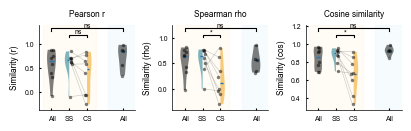

In [38]:
# Additional map similarities: Pearson (occupancy-weighted), Spearman rho and Cosine similarity
# Compared between Session 1 and Session 2.

MIN_VALID_BINS_FOR_DISTANCE = 20

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None


def _map_pair_spearman_distance(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0 or scipy_stats is None:
        return np.nan, n_valid

    try:
        rho, _p = scipy_stats.spearmanr(x, y)
    except Exception:
        return np.nan, n_valid

    if not np.isfinite(rho):
        return np.nan, n_valid

    sim = float(rho)
    return sim, n_valid


def _map_pair_cosine_distance(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n_valid

    cos_sim = float(np.dot(x, y) / (nx * ny))
    cos_sim = float(np.clip(cos_sim, -1.0, 1.0))
    sim = cos_sim
    return sim, n_valid



def _map_pair_pearson_distance(map1, map2, occ1=None, occ2=None, min_valid_bins=20, min_eff_bins=20, min_occ=0.0):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if not isinstance(occ1, np.ndarray) or not isinstance(occ2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape or map1.shape != occ1.shape or map1.shape != occ2.shape:
        return np.nan, 0

    x = np.asarray(map1, dtype=float).ravel()
    y = np.asarray(map2, dtype=float).ravel()
    w = np.minimum(np.asarray(occ1, dtype=float).ravel(), np.asarray(occ2, dtype=float).ravel())

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > float(min_occ))
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = x[valid]
    y = y[valid]
    w = w[valid]
    sw = float(np.sum(w))
    if sw <= 0:
        return np.nan, n_valid

    mx = float(np.sum(w * x) / sw)
    my = float(np.sum(w * y) / sw)
    dx = x - mx
    dy = y - my

    den_x = float(np.sum(w * dx * dx))
    den_y = float(np.sum(w * dy * dy))
    den = np.sqrt(den_x * den_y)
    if den <= 0:
        return np.nan, n_valid

    sw2 = float(np.sum(w * w))
    n_eff = (sw * sw / sw2) if sw2 > 0 else 0.0
    if n_eff < float(min_eff_bins):
        return np.nan, n_valid

    r = float(np.sum(w * dx * dy) / den)
    if not np.isfinite(r):
        return np.nan, n_valid
    return float(np.clip(r, -1.0, 1.0)), n_valid

def _collect_session_distance(cell_keys, map_key, group_label, metric='spearman'):
    rows = []
    for dataset_id, cell_idx in cell_keys:
        c1 = _get_condition_cell(dataset_id, cell_idx, 'session1')
        c2 = _get_condition_cell(dataset_id, cell_idx, 'session2')

        if c1 is None or c2 is None:
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'metric': metric,
                'has_both_halves': False,
                'n_valid_bins': 0,
                'similarity': np.nan,
            })
            continue

        # Peak-rate gate for S1 vs S2 comparison
        if bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)):
            thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
            if not _passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key=map_key, threshold=thr):
                rows.append({
                    'dataset_id': dataset_id,
                    'cell_idx': int(cell_idx),
                    'group': group_label,
                    'map_key': map_key,
                    'metric': metric,
                    'has_both_halves': True,
                    'n_valid_bins': 0,
                    'similarity': np.nan,
                })
                continue

        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)
        _renormalize_ss_cs_maps_per_condition(c1)
        _renormalize_ss_cs_maps_per_condition(c2)

        if metric == 'pearson':
            min_valid_bins_w = int(globals().get('MIN_VALID_BINS_FOR_CORR_WEIGHTED', MIN_VALID_BINS_FOR_DISTANCE))
            min_eff_bins_w = int(globals().get('MIN_EFFECTIVE_BINS_WEIGHTED', min_valid_bins_w))
            min_occ_w = float(globals().get('MIN_OCCUPANCY_WEIGHT', 0.0))
            d, n_valid = _map_pair_pearson_distance(
                c1.get(map_key, None),
                c2.get(map_key, None),
                c1.get('occupancy', None),
                c2.get('occupancy', None),
                min_valid_bins=min_valid_bins_w,
                min_eff_bins=min_eff_bins_w,
                min_occ=min_occ_w,
            )
        elif metric == 'spearman':
            d, n_valid = _map_pair_spearman_distance(c1.get(map_key, None), c2.get(map_key, None), min_valid_bins=MIN_VALID_BINS_FOR_DISTANCE)
        elif metric == 'cosine':
            d, n_valid = _map_pair_cosine_distance(c1.get(map_key, None), c2.get(map_key, None), min_valid_bins=MIN_VALID_BINS_FOR_DISTANCE)
        else:
            raise ValueError(f'Unknown metric: {metric}')

        rows.append({
            'dataset_id': dataset_id,
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'metric': metric,
            'has_both_halves': True,
            'n_valid_bins': int(n_valid),
            'similarity': d,
        })

    return pd.DataFrame(rows)


def _summarize_distance_df(df, title):
    print(f"\n=== {title} ===")
    if df is None or len(df) == 0:
        print('No rows')
        return

    out_rows = []
    for g in sorted(df['group'].unique()):
        dfg = df[df['group'] == g].copy()
        n_total = int(len(dfg))
        n_both = int(dfg['has_both_halves'].sum())
        dfg_valid = dfg[np.isfinite(dfg['similarity'])]
        n_valid = int(len(dfg_valid))
        mean_d = float(np.nanmean(dfg_valid['similarity'])) if n_valid > 0 else np.nan
        med_d = float(np.nanmedian(dfg_valid['similarity'])) if n_valid > 0 else np.nan
        std_d = float(np.nanstd(dfg_valid['similarity'], ddof=1)) if n_valid > 1 else np.nan

        out_rows.append({
            'group': g,
            'n_total_cells': n_total,
            'n_with_session1_and_session2': n_both,
            'n_valid_similarity': n_valid,
            'mean_similarity': mean_d,
            'median_similarity': med_d,
            'std_similarity': std_d,
        })

    display(pd.DataFrame(out_rows))


def _row_keys(df):
    if df is None or len(df) == 0:
        return []
    return list(zip(df['dataset_id'].astype(str), df['cell_idx'].astype(int)))


def _exclude_rows_by_keys(df, exclude_keys):
    if df is None:
        return df
    if not exclude_keys or len(df) == 0:
        return df.copy()
    keep_mask = [k not in exclude_keys for k in _row_keys(df)]
    return df.loc[np.asarray(keep_mask, dtype=bool)].reset_index(drop=True)


def _compute_distance_tables(metric_name):
    d_all_csplus = _collect_session_distance(csplus_keys, 'rate_map', 'CS+', metric=metric_name)
    d_all_csminus = _collect_session_distance(csminus_keys, 'rate_map', 'CS-', metric=metric_name)
    d_ss_csplus = _collect_session_distance(csplus_keys, 'ss_norm_map', 'CS+', metric=metric_name)
    d_ss_csminus = _collect_session_distance(csminus_keys, 'ss_norm_map', 'CS-', metric=metric_name)
    d_cs_map = _collect_session_distance(csplus_keys, 'cs_norm_map', 'CS+', metric=metric_name)

    # Optional outlier removal based on Pearson SS r threshold (same policy as other figures)
    REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
    SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))

    outlier_keys = set()
    if REMOVE_LOW_SS_OUTLIER_LOCAL and ('df_ss_map' in globals()) and isinstance(df_ss_map, pd.DataFrame) and ('corr_r' in df_ss_map.columns):
        outlier_df = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < SS_R_OUTLIER_THRESHOLD_LOCAL)]
        outlier_keys = set(_row_keys(outlier_df))

        d_all_csplus = _exclude_rows_by_keys(d_all_csplus, outlier_keys)
        d_all_csminus = _exclude_rows_by_keys(d_all_csminus, outlier_keys)
        d_ss_csplus = _exclude_rows_by_keys(d_ss_csplus, outlier_keys)
        d_ss_csminus = _exclude_rows_by_keys(d_ss_csminus, outlier_keys)
        d_cs_map = _exclude_rows_by_keys(d_cs_map, outlier_keys)

    d_all_map = pd.concat([d_all_csplus, d_all_csminus], ignore_index=True)
    d_ss_map = pd.concat([d_ss_csplus, d_ss_csminus], ignore_index=True)

    print(f"{metric_name}: outlier filter enabled={REMOVE_LOW_SS_OUTLIER_LOCAL}, removed={len(outlier_keys)}")

    return d_all_csplus, d_all_csminus, d_ss_csplus, d_ss_csminus, d_cs_map, d_all_map, d_ss_map


# Compute tables
pe_all_csplus, pe_all_csminus, pe_ss_csplus, pe_ss_csminus, pe_cs_map, pe_all_map, pe_ss_map = _compute_distance_tables('pearson')
sp_all_csplus, sp_all_csminus, sp_ss_csplus, sp_ss_csminus, sp_cs_map, sp_all_map, sp_ss_map = _compute_distance_tables('spearman')
co_all_csplus, co_all_csminus, co_ss_csplus, co_ss_csminus, co_cs_map, co_all_map, co_ss_map = _compute_distance_tables('cosine')

_summarize_distance_df(pe_all_map, 'Pearson Similarity (r): All-Spike Maps (Session1 vs Session2)')
_summarize_distance_df(pe_ss_map, 'Pearson Similarity (r): Simple-Spike Maps (Session1 vs Session2)')
_summarize_distance_df(pe_cs_map, 'Pearson Similarity (r): Complex-Spike Maps (Session1 vs Session2, CS+ only)')

_summarize_distance_df(sp_all_map, 'Spearman Similarity (rho): All-Spike Maps (Session1 vs Session2)')
_summarize_distance_df(sp_ss_map, 'Spearman Similarity (rho): Simple-Spike Maps (Session1 vs Session2)')
_summarize_distance_df(sp_cs_map, 'Spearman Similarity (rho): Complex-Spike Maps (Session1 vs Session2, CS+ only)')

_summarize_distance_df(co_all_map, 'Cosine Similarity: All-Spike Maps (Session1 vs Session2)')
_summarize_distance_df(co_ss_map, 'Cosine Similarity: Simple-Spike Maps (Session1 vs Session2)')
_summarize_distance_df(co_cs_map, 'Cosine Similarity: Complex-Spike Maps (Session1 vs Session2, CS+ only)')


# Plot grouped style (CS+ left: All/SS/CS, CS- right: All)

def _shapiro_p_safe(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_unpaired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = int(x.size), int(y.size)
    if scipy_stats is None or n1 < 2 or n2 < 2:
        return np.nan, 'n/a', np.nan, np.nan

    sh1 = _shapiro_p_safe(x)
    sh2 = _shapiro_p_safe(y)
    can_parametric = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(sh1) and sh1 >= alpha and
        np.isfinite(sh2) and sh2 >= alpha
    )

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', sh1, sh2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', sh1, sh2
    except Exception:
        return np.nan, 'mannwhitney_u', sh1, sh2


def _auto_paired_test(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n = int(x.size)
    if scipy_stats is None or n < 2:
        return np.nan, 'n/a', np.nan

    sh = _shapiro_p_safe(x - y)
    can_parametric = (n >= 5 and np.isfinite(sh) and sh >= alpha)

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', sh
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', sh
    except Exception:
        return np.nan, 'wilcoxon', sh


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def _add_bracket(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.8)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


def _finite_vals(df):
    arr = np.asarray(df['similarity'], dtype=float)
    return arr[np.isfinite(arr)]


def _draw_violin(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    if 'cmedians' in parts:
        parts['cmedians'].set_color('#1F77B4')
        parts['cmedians'].set_linewidth(1.0)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


def _plot_distance_panel(ax, all_csplus_df, all_csminus_df, ss_csplus_df, cs_csplus_df, title, ylabel):
    all_csplus_vals = _finite_vals(all_csplus_df)
    all_csminus_vals = _finite_vals(all_csminus_df)
    ss_csplus_vals = _finite_vals(ss_csplus_df)
    cs_csplus_vals = _finite_vals(cs_csplus_df)

    cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
    non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))

    ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
    ax.axvspan(4.2, 5.8, alpha=0.3, color=non_cs_plc_bg_local, zorder=0)

    _draw_violin(ax, all_csplus_vals, 1.0, 'black', half=None, alpha=0.5)
    _draw_violin(ax, ss_csplus_vals, 2.0, '#026C80', half='left', alpha=0.5)
    _draw_violin(ax, cs_csplus_vals, 3.0, '#EE9B00', half='right', alpha=0.5)
    _draw_violin(ax, all_csminus_vals, 5.0, 'black', half=None, alpha=0.5)

    # Paired table for CS+ SS vs CS
    ma = ss_csplus_df[['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'a'})
    mb = cs_csplus_df[['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'b'})
    m = ma.merge(mb, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['a']) & np.isfinite(m['b'])]
    for row in m.itertuples(index=False):
        ax.plot([2.08, 2.92], [row.a, row.b], color='black', alpha=0.18, linewidth=0.5, zorder=2)

    _scatter_side(ax, all_csplus_vals, 1.0, direction='center', rng_seed=101)
    _scatter_side(ax, ss_csplus_vals, 2.0, direction='right', rng_seed=102)
    _scatter_side(ax, cs_csplus_vals, 3.0, direction='left', rng_seed=103)
    _scatter_side(ax, all_csminus_vals, 5.0, direction='center', rng_seed=104)

    # Tests
    p_paired, paired_test, paired_sh = _auto_paired_test(m['a'].to_numpy(dtype=float), m['b'].to_numpy(dtype=float), alpha=0.05)
    p_unpaired, unpaired_test, sh1, sh2 = _auto_unpaired_test(all_csplus_vals, all_csminus_vals, alpha=0.05)

    ax.set_title(title, fontsize=6, fontname='Arial')
    ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
    ax.set_xticks([1.0, 2.0, 3.0, 5.0])
    ax.set_xticklabels(['All', 'SS', 'CS', 'All'], fontsize=4, fontname='Arial')
    ax.set_xlim(0.3, 5.7)
    ax.tick_params(axis='both', labelsize=5)
    for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Dynamic y-limits + brackets
    all_vals = np.concatenate([
        all_csplus_vals if len(all_csplus_vals) else np.array([0.0]),
        all_csminus_vals if len(all_csminus_vals) else np.array([0.0]),
        ss_csplus_vals if len(ss_csplus_vals) else np.array([0.0]),
        cs_csplus_vals if len(cs_csplus_vals) else np.array([0.0]),
    ])
    if np.any(np.isfinite(all_vals)):
        y_min = float(np.nanmin(all_vals))
        y_max = float(np.nanmax(all_vals))
    else:
        y_min, y_max = 0.0, 1.0

    base_pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
    y0 = y_min - base_pad
    y_top = y_max + base_pad
    yr = max(0.2, y_top - y0)
    h = 0.04 * yr
    gap = 0.05 * yr

    y1 = y_top + 0.02 * yr
    _add_bracket(ax, 2.0, 3.0, y1, h, _sig_label(p_paired), color='black')
    y2 = y1 + h + gap
    _add_bracket(ax, 1.0, 5.0, y2, h, _sig_label(p_unpaired), color='black')

    ax.set_ylim(y0, y2 + h + 0.05 * yr)

    return {
        'paired_p': p_paired,
        'paired_test': paired_test,
        'paired_shapiro_p': paired_sh,
        'paired_n': int(len(m)),
        'unpaired_p': p_unpaired,
        'unpaired_test': unpaired_test,
        'unpaired_shapiro_csplus_p': sh1,
        'unpaired_shapiro_csminus_p': sh2,
        'unpaired_n_csplus': int(len(all_csplus_vals)),
        'unpaired_n_csminus': int(len(all_csminus_vals)),
    }


fig, axes = plt.subplots(1, 3, figsize=(4, 1.2), constrained_layout=True)
stats_pearson = _plot_distance_panel(
    axes[0],
    pe_all_csplus, pe_all_csminus,
    pe_ss_csplus, pe_cs_map,
    title='Pearson r',
    ylabel='Similarity (r)',
)
stats_spearman = _plot_distance_panel(
    axes[1],
    sp_all_csplus, sp_all_csminus,
    sp_ss_csplus, sp_cs_map,
    title='Spearman rho',
    ylabel='Similarity (rho)',
)
stats_cosine = _plot_distance_panel(
    axes[2],
    co_all_csplus, co_all_csminus,
    co_ss_csplus, co_cs_map,
    title='Cosine similarity',
    ylabel='Similarity (cos)',
)

print("\n=== Similarity Statistical Tests ===")
print(
    f"Pearson: SS vs CS (CS+) -> {stats_pearson['paired_test']}, "
    f"p={stats_pearson['paired_p']:.4g}, n={stats_pearson['paired_n']}, "
    f"Shapiro(diff) p={stats_pearson['paired_shapiro_p']:.4g}"
)
print(
    f"Pearson: All CS+ vs CS- -> {stats_pearson['unpaired_test']}, "
    f"p={stats_pearson['unpaired_p']:.4g}, "
    f"n_cs+={stats_pearson['unpaired_n_csplus']}, n_cs-={stats_pearson['unpaired_n_csminus']}, "
    f"Shapiro CS+ p={stats_pearson['unpaired_shapiro_csplus_p']:.4g}, "
    f"CS- p={stats_pearson['unpaired_shapiro_csminus_p']:.4g}"
)
print(
    f"Spearman: SS vs CS (CS+) -> {stats_spearman['paired_test']}, "
    f"p={stats_spearman['paired_p']:.4g}, n={stats_spearman['paired_n']}, "
    f"Shapiro(diff) p={stats_spearman['paired_shapiro_p']:.4g}"
)
print(
    f"Spearman: All CS+ vs CS- -> {stats_spearman['unpaired_test']}, "
    f"p={stats_spearman['unpaired_p']:.4g}, "
    f"n_cs+={stats_spearman['unpaired_n_csplus']}, n_cs-={stats_spearman['unpaired_n_csminus']}, "
    f"Shapiro CS+ p={stats_spearman['unpaired_shapiro_csplus_p']:.4g}, "
    f"CS- p={stats_spearman['unpaired_shapiro_csminus_p']:.4g}"
)
print(
    f"Cosine: SS vs CS (CS+) -> {stats_cosine['paired_test']}, "
    f"p={stats_cosine['paired_p']:.4g}, n={stats_cosine['paired_n']}, "
    f"Shapiro(diff) p={stats_cosine['paired_shapiro_p']:.4g}"
)
print(
    f"Cosine: All CS+ vs CS- -> {stats_cosine['unpaired_test']}, "
    f"p={stats_cosine['unpaired_p']:.4g}, "
    f"n_cs+={stats_cosine['unpaired_n_csplus']}, n_cs-={stats_cosine['unpaired_n_csminus']}, "
    f"Shapiro CS+ p={stats_cosine['unpaired_shapiro_csplus_p']:.4g}, "
    f"CS- p={stats_cosine['unpaired_shapiro_csminus_p']:.4g}"
)

fig_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_session1_vs_session2_map_similarities_pearson_spearman_cosine.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

out_table = pd.concat([
    pe_all_map.assign(metric_type='pearson', map_group='all_map'),
    pe_ss_map.assign(metric_type='pearson', map_group='ss_map'),
    pe_cs_map.assign(metric_type='pearson', map_group='cs_map'),
    sp_all_map.assign(metric_type='spearman', map_group='all_map'),
    sp_ss_map.assign(metric_type='spearman', map_group='ss_map'),
    sp_cs_map.assign(metric_type='spearman', map_group='cs_map'),
    co_all_map.assign(metric_type='cosine', map_group='all_map'),
    co_ss_map.assign(metric_type='cosine', map_group='ss_map'),
    co_cs_map.assign(metric_type='cosine', map_group='cs_map'),
], ignore_index=True)
out_csv = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_session1_vs_session2_map_similarities_pearson_spearman_cosine.csv')
out_table.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')


# SS vs CS map similarity v

=== CS+ PLC only: SS-vs-CS map similarity within each session ===


,metric,test,p_value,n_pairs,shapiro_diff_p,mean_session1,mean_session2
0,pearson,paired_t,0.021870,8,0.291607,0.880701,0.698156
1,spearman,paired_t,0.075902,8,0.495079,0.807347,0.578991
2,cosine,wilcoxon,0.023438,8,0.000255,0.924273,0.831592


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_csplus_plc_ss_vs_cs_within_session_similarity.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_csplus_plc_ss_vs_cs_within_session_similarity.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_csplus_plc_ss_vs_cs_within_session_similarity_stats.csv


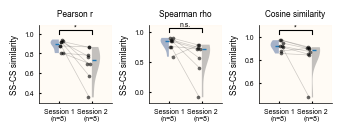

In [39]:
# CS+ place cells only: SS-vs-CS map similarity within each session
# Two groups: Session 1 vs Session 2
# Metric computed per cell: similarity(ss_norm_map, cs_norm_map) within a session

MIN_VALID_BINS_FOR_SSCS = 20

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None


def _pearson_sim(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    return float(np.corrcoef(x, y)[0, 1]), n


def _spearman_sim(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    if scipy_stats is not None:
        try:
            rho, _p = scipy_stats.spearmanr(x, y)
            return (float(rho) if np.isfinite(rho) else np.nan), n
        except Exception:
            return np.nan, n
    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
        return np.nan, n
    return float(np.corrcoef(rx, ry)[0, 1]), n


def _cosine_sim(m1, m2, min_valid_bins=20):
    if not isinstance(m1, np.ndarray) or not isinstance(m2, np.ndarray):
        return np.nan, 0
    if m1.shape != m2.shape:
        return np.nan, 0
    a = np.asarray(m1, dtype=float).ravel()
    b = np.asarray(m2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n
    cs = float(np.dot(x, y) / (nx * ny))
    return float(np.clip(cs, -1.0, 1.0)), n


def _shapiro_safe(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 3 or scipy_stats is None:
        return np.nan
    try:
        return float(scipy_stats.shapiro(vals).pvalue)
    except Exception:
        return np.nan


def _auto_paired(vals1, vals2, alpha=0.05):
    x = np.asarray(vals1, dtype=float)
    y = np.asarray(vals2, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n = int(len(x))
    if n < 2 or scipy_stats is None:
        return np.nan, 'n/a', np.nan

    sh = _shapiro_safe(x - y)
    can_param = (n >= 5 and np.isfinite(sh) and sh >= alpha)

    if can_param:
        try:
            _stat, p = scipy_stats.ttest_rel(x, y, nan_policy='omit')
            return float(p), 'paired_t', sh
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', sh
    except Exception:
        return np.nan, 'wilcoxon', sh


def _sig_label(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def _collect_sscs_within_session_similarity(metric='pearson'):
    rows = []

    occ_filter_enabled = bool(globals().get('APPLY_OCCUPANCY_DATASET_FILTER', False))
    allowed_ids_obj = globals().get('allowed_dataset_ids', None)
    allowed_ids = None
    if allowed_ids_obj is not None:
        try:
            allowed_ids = set(str(x) for x in allowed_ids_obj)
        except Exception:
            allowed_ids = None

    peak_gate_enabled = bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True))
    peak_thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))

    for dataset_id, cell_idx in sorted(csplus_keys):
        dataset_id_str = str(dataset_id)

        passes_occ_gate = True
        if occ_filter_enabled and (allowed_ids is not None) and (len(allowed_ids) > 0):
            passes_occ_gate = dataset_id_str in allowed_ids

        passes_peak_gate = True
        if peak_gate_enabled and ('_passes_s1s2_peak_threshold' in globals()):
            try:
                pass_ss = bool(_passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key='ss_norm_map', threshold=peak_thr))
                pass_cs = bool(_passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key='cs_norm_map', threshold=peak_thr))
                passes_peak_gate = bool(pass_ss and pass_cs)
            except Exception:
                passes_peak_gate = False

        if not (passes_occ_gate and passes_peak_gate):
            for sess in ('session1', 'session2'):
                rows.append({
                    'dataset_id': dataset_id,
                    'cell_idx': int(cell_idx),
                    'session': sess,
                    'metric': metric,
                    'n_valid_bins': 0,
                    'similarity': np.nan,
                    'passes_occ_gate': bool(passes_occ_gate),
                    'passes_s1s2_peak_gate': bool(passes_peak_gate),
                })
            continue

        for sess in ('session1', 'session2'):
            c = _get_condition_cell(dataset_id, cell_idx, sess)
            if c is None:
                rows.append({
                    'dataset_id': dataset_id,
                    'cell_idx': int(cell_idx),
                    'session': sess,
                    'metric': metric,
                    'n_valid_bins': 0,
                    'similarity': np.nan,
                    'passes_occ_gate': bool(passes_occ_gate),
                    'passes_s1s2_peak_gate': bool(passes_peak_gate),
                })
                continue

            c = copy.deepcopy(c)
            _renormalize_ss_cs_maps_per_condition(c)
            ss_map = c.get('ss_norm_map', None)
            cs_map = c.get('cs_norm_map', None)

            if metric == 'pearson':
                sim, n_valid = _pearson_sim(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS)
            elif metric == 'spearman':
                sim, n_valid = _spearman_sim(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS)
            elif metric == 'cosine':
                sim, n_valid = _cosine_sim(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS)
            else:
                raise ValueError(metric)

            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'session': sess,
                'metric': metric,
                'n_valid_bins': int(n_valid),
                'similarity': sim,
                'passes_occ_gate': bool(passes_occ_gate),
                'passes_s1s2_peak_gate': bool(passes_peak_gate),
            })

    return pd.DataFrame(rows)


def _paired_arrays(df_metric):
    d1 = df_metric[df_metric['session'] == 'session1'][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity':'s1'})
    d2 = df_metric[df_metric['session'] == 'session2'][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity':'s2'})
    m = d1.merge(d2, on=['dataset_id','cell_idx'], how='inner')
    m = m[np.isfinite(m['s1']) & np.isfinite(m['s2'])]
    return m


SESSION1_GROUP_COLOR = '#3B5B92'
SESSION2_GROUP_COLOR = '#7A7A7A'

def _draw_panel(ax, pair_df, title):
    s1 = pair_df['s1'].to_numpy(dtype=float)
    s2 = pair_df['s2'].to_numpy(dtype=float)

    # CS+ PLC background (this panel only contains CS+ PLC cells)
    cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
    ax.axvspan(0.4, 2.6, alpha=0.3, color=cs_plc_bg_local, zorder=0)

    def _draw_half(vals, pos, color, side):
        if len(vals) < 3:
            return
        parts = ax.violinplot([vals], positions=[pos], showmedians=True, showextrema=False)
        if 'cmedians' in parts:
            parts['cmedians'].set_color('#1F77B4')
            parts['cmedians'].set_linewidth(1.0)
        body = parts['bodies'][0]
        body.set_facecolor(color)
        body.set_edgecolor('none')
        body.set_alpha(0.45)
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if side == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)

    _draw_half(s1, 1.0, SESSION1_GROUP_COLOR, 'left')
    _draw_half(s2, 2.0, SESSION2_GROUP_COLOR, 'right')

    for r in pair_df.itertuples(index=False):
        ax.plot([1.08, 1.92], [r.s1, r.s2], color='black', alpha=0.2, linewidth=0.5, zorder=2)

    rng = np.random.default_rng(2026)
    if len(s1) > 0:
        ax.scatter(1.0 + 0.02 + rng.random(len(s1))*0.12, s1, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)
    if len(s2) > 0:
        ax.scatter(2.0 - 0.02 - rng.random(len(s2))*0.12, s2, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)

    p, test_name, sh = _auto_paired(s1, s2, alpha=0.05)

    vals = np.concatenate([s1 if len(s1) else np.array([0.0]), s2 if len(s2) else np.array([0.0])])
    y_min = float(np.nanmin(vals))
    y_max = float(np.nanmax(vals))
    pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
    y0 = y_min - pad
    y1 = y_max + pad
    h = 0.06 * max(0.2, y1 - y0)

    ax.plot([1.0,1.0,2.0,2.0], [y1,y1+h,y1+h,y1], color='black', linewidth=0.8)
    ax.text(1.5, y1+h, _sig_label(p), ha='center', va='bottom', fontsize=5, fontname='Arial')

    ax.set_title(title, fontsize=6, fontname='Arial')
    ax.set_ylabel('SS-CS similarity', fontsize=6, fontname='Arial')
    ax.set_xticks([1.0,2.0])
    ax.set_xticklabels([f'Session 1\n(n={len(s1)})', f'Session 2\n(n={len(s2)})'], fontsize=4, fontname='Arial')
    ax.tick_params(axis='both', labelsize=5)
    for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        lbl.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0.4, 2.6)
    ax.set_ylim(y0, y1 + h + 0.05)

    return p, test_name, sh, len(s1)


metrics = ['pearson', 'spearman', 'cosine']
metric_title = {'pearson': 'Pearson r', 'spearman': 'Spearman rho', 'cosine': 'Cosine similarity'}

all_rows = []
stats_rows = []

fig, axes = plt.subplots(1, 3, figsize=(3.3, 1.2), constrained_layout=True)
for ax, metric in zip(axes, metrics):
    d = _collect_sscs_within_session_similarity(metric=metric)
    all_rows.append(d)
    pair_df = _paired_arrays(d)

    p, test_name, sh, n_pairs = _draw_panel(ax, pair_df, metric_title[metric])
    stats_rows.append({
        'metric': metric,
        'test': test_name,
        'p_value': p,
        'n_pairs': int(n_pairs),
        'shapiro_diff_p': sh,
        'mean_session1': float(np.nanmean(pair_df['s1'])) if n_pairs > 0 else np.nan,
        'mean_session2': float(np.nanmean(pair_df['s2'])) if n_pairs > 0 else np.nan,
    })

sim_df = pd.concat(all_rows, ignore_index=True)
stats_df = pd.DataFrame(stats_rows)

print('=== CS+ PLC only: SS-vs-CS map similarity within each session ===')
display(stats_df)

fig_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_csplus_plc_ss_vs_cs_within_session_similarity.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

csv_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_csplus_plc_ss_vs_cs_within_session_similarity.csv')
sim_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

stats_csv_path = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_csplus_plc_ss_vs_cs_within_session_similarity_stats.csv')
stats_df.to_csv(stats_csv_path, index=False)
print(f'Saved: {stats_csv_path}')


Low-SS outlier filter enabled: False (threshold=0.1)
Removed outlier cells: 0
Normalize delta by S1: True
=== Peak-rate change analysis ===


,normalize_delta_by_s1,paired_test,paired_p_value,paired_shapiro_p,paired_n_csplus_ss_vs_cs,unpaired_test,unpaired_p_value,unpaired_shapiro_csplus_p,unpaired_shapiro_csminus_p,unpaired_n_csplus_all,unpaired_n_csminus_all,mean_delta_all_csplus,mean_delta_all_csminus,mean_delta_ss_csplus,mean_delta_cs_csplus
0,True,paired_t,0.929508,0.937094,8,welch_t,0.662087,0.139073,0.355163,8,5,-0.501879,-0.451569,-0.479717,-0.486007


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_peak_rate_change_grouped_csplus_csminus_normS1.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_peak_rate_change_grouped_csplus_csminus_normS1.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_peak_rate_change_grouped_csplus_csminus_normS1_stats.csv


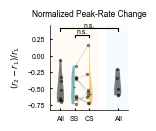

In [40]:
# Peak firing-rate change: grouped style
# CS+ left: All / SS / CS ; CS- right: All
# Option: normalize change by Session1 peak rate

NORMALIZE_DELTA_BY_S1 = True
EPS_S1_RATE = 1e-12


def _nan_peak_rate(rate_map):
    if not isinstance(rate_map, np.ndarray):
        return np.nan
    if rate_map.size == 0 or (not np.any(np.isfinite(rate_map))):
        return np.nan
    return float(np.nanmax(rate_map))


def _collect_peak_delta_for_keys(cell_keys, map_kind, group_label):
    rows = []
    for dataset_id, cell_idx in sorted(cell_keys):
        c1 = _get_condition_cell(dataset_id, cell_idx, 'session1')
        c2 = _get_condition_cell(dataset_id, cell_idx, 'session2')

        if c1 is None or c2 is None:
            rows.append({
                'dataset_id': dataset_id,
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_kind': map_kind,
                'has_both_sessions': False,
                'peak_s1_hz': np.nan,
                'peak_s2_hz': np.nan,
                'raw_delta_peak_hz': np.nan,
                'norm_delta_peak': np.nan,
                'delta_peak_value': np.nan,
            })
            continue

        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)

        if map_kind == 'all':
            m1 = c1.get('rate_map', None)
            m2 = c2.get('rate_map', None)
        elif map_kind == 'ss':
            m1 = c1.get('ss_rate_map', None)
            m2 = c2.get('ss_rate_map', None)
        elif map_kind == 'cs':
            m1 = c1.get('cs_rate_map', None)
            m2 = c2.get('cs_rate_map', None)
        else:
            raise ValueError(map_kind)

        p1 = _nan_peak_rate(m1)
        p2 = _nan_peak_rate(m2)
        thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
        passes_peak = bool(np.isfinite(p1) and np.isfinite(p2) and (p1 > thr) and (p2 > thr))

        raw_delta = (p2 - p1) if passes_peak else np.nan
        norm_delta = (raw_delta / p1) if (passes_peak and abs(p1) > EPS_S1_RATE) else np.nan
        delta_value = norm_delta if NORMALIZE_DELTA_BY_S1 else raw_delta

        rows.append({
            'dataset_id': dataset_id,
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_kind': map_kind,
            'has_both_sessions': True,
            'peak_s1_hz': p1,
            'peak_s2_hz': p2,
            'raw_delta_peak_hz': raw_delta,
            'norm_delta_peak': norm_delta,
            'delta_peak_value': delta_value,
            'passes_peak_filter': passes_peak,
        })

    return pd.DataFrame(rows)


def _row_keys_local(df):
    if df is None or len(df) == 0:
        return []
    return list(zip(df['dataset_id'].astype(str), df['cell_idx'].astype(int)))


def _exclude_rows_by_keys_local(df, exclude_keys):
    if df is None:
        return df
    if not exclude_keys or len(df) == 0:
        return df.copy()
    keep_mask = [k not in exclude_keys for k in _row_keys_local(df)]
    return df.loc[np.asarray(keep_mask, dtype=bool)].reset_index(drop=True)


def _auto_unpaired_local(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    n1, n2 = int(x.size), int(y.size)

    if n1 < 2 or n2 < 2 or ('scipy_stats' not in globals()) or (scipy_stats is None):
        return np.nan, 'n/a', np.nan, np.nan

    def _sh(vals):
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) < 3:
            return np.nan
        try:
            return float(scipy_stats.shapiro(vals).pvalue)
        except Exception:
            return np.nan

    sh1 = _sh(x)
    sh2 = _sh(y)
    can_param = (n1 >= 5 and n2 >= 5 and np.isfinite(sh1) and sh1 >= alpha and np.isfinite(sh2) and sh2 >= alpha)

    if can_param:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', sh1, sh2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', sh1, sh2
    except Exception:
        return np.nan, 'mannwhitney_u', sh1, sh2


def _auto_paired_local(vals1, vals2, alpha=0.05):
    if '_auto_paired' in globals():
        return _auto_paired(vals1, vals2, alpha=alpha)
    x = np.asarray(vals1, dtype=float)
    y = np.asarray(vals2, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n = int(len(x))
    if n < 2 or ('scipy_stats' not in globals()) or (scipy_stats is None):
        return np.nan, 'n/a', np.nan
    try:
        _stat, p = scipy_stats.wilcoxon(x, y, alternative='two-sided')
        return float(p), 'wilcoxon', np.nan
    except Exception:
        return np.nan, 'wilcoxon', np.nan


def _sig_label_local(p):
    if '_sig_label' in globals():
        return _sig_label(p)
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def _finite_vals_local(df):
    arr = np.asarray(df['delta_peak_value'], dtype=float)
    return arr[np.isfinite(arr)]


def _draw_violin_local(ax, arr, pos, color, half=None, alpha=0.5):
    if len(arr) < 3:
        return
    parts = ax.violinplot([arr], positions=[pos], showmedians=True, showextrema=False)
    if 'cmedians' in parts:
        parts['cmedians'].set_color('#1F77B4')
        parts['cmedians'].set_linewidth(1.0)
    body = parts['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(alpha)

    if half in ('left', 'right'):
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if half == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)


def _scatter_side_local(ax, arr, pos, direction='center', rng_seed=0):
    if len(arr) == 0:
        return
    rng = np.random.default_rng(rng_seed)
    if direction == 'right':
        x = pos + 0.02 + rng.random(len(arr)) * 0.12
    elif direction == 'left':
        x = pos - 0.02 - rng.random(len(arr)) * 0.12
    else:
        x = pos + (rng.random(len(arr)) - 0.5) * 0.14
    ax.scatter(x, arr, s=6, color='black', alpha=0.5, linewidths=0, zorder=3)


# Build tables
d_all_csplus = _collect_peak_delta_for_keys(csplus_keys, 'all', 'CS+')
d_all_csminus = _collect_peak_delta_for_keys(csminus_keys, 'all', 'CS-')
d_ss_csplus = _collect_peak_delta_for_keys(csplus_keys, 'ss', 'CS+')
d_cs_csplus = _collect_peak_delta_for_keys(csplus_keys, 'cs', 'CS+')

# Optional outlier removal by low SS map correlation (same policy)
REMOVE_LOW_SS_OUTLIER_LOCAL = bool(globals().get('REMOVE_LOW_SS_OUTLIER', True))
SS_R_OUTLIER_THRESHOLD_LOCAL = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))
outlier_keys = set()
if REMOVE_LOW_SS_OUTLIER_LOCAL and ('df_ss_map' in globals()) and isinstance(df_ss_map, pd.DataFrame) and ('corr_r' in df_ss_map.columns):
    outlier_df = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < SS_R_OUTLIER_THRESHOLD_LOCAL)]
    outlier_keys = set(_row_keys_local(outlier_df))

if len(outlier_keys) > 0:
    d_all_csplus = _exclude_rows_by_keys_local(d_all_csplus, outlier_keys)
    d_all_csminus = _exclude_rows_by_keys_local(d_all_csminus, outlier_keys)
    d_ss_csplus = _exclude_rows_by_keys_local(d_ss_csplus, outlier_keys)
    d_cs_csplus = _exclude_rows_by_keys_local(d_cs_csplus, outlier_keys)

print(f'Low-SS outlier filter enabled: {REMOVE_LOW_SS_OUTLIER_LOCAL} (threshold={SS_R_OUTLIER_THRESHOLD_LOCAL})')
print(f'Removed outlier cells: {len(outlier_keys)}')
print(f'Normalize delta by S1: {NORMALIZE_DELTA_BY_S1}')

# plotting values
all_csplus_vals = _finite_vals_local(d_all_csplus)
all_csminus_vals = _finite_vals_local(d_all_csminus)
ss_csplus_vals = _finite_vals_local(d_ss_csplus)
cs_csplus_vals = _finite_vals_local(d_cs_csplus)

# Paired table for CS+ SS vs CS deltas
ma = d_ss_csplus[['dataset_id', 'cell_idx', 'delta_peak_value']].rename(columns={'delta_peak_value': 'a'})
mb = d_cs_csplus[['dataset_id', 'cell_idx', 'delta_peak_value']].rename(columns={'delta_peak_value': 'b'})
m = ma.merge(mb, on=['dataset_id', 'cell_idx'], how='inner')
m = m[np.isfinite(m['a']) & np.isfinite(m['b'])]

# Stats
p_paired, paired_test, paired_sh = _auto_paired_local(m['a'].to_numpy(dtype=float), m['b'].to_numpy(dtype=float), alpha=0.05)
p_unpaired, unpaired_test, sh1, sh2 = _auto_unpaired_local(all_csplus_vals, all_csminus_vals, alpha=0.05)

fig, ax = plt.subplots(1, 1, figsize=(1.26, 1.2), constrained_layout=True)

# CS+/CS- backgrounds
cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#FFF3E0'))
non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg_local, zorder=0)
ax.axvspan(4.2, 5.8, alpha=0.3, color=non_cs_plc_bg_local, zorder=0)

# violins
_draw_violin_local(ax, all_csplus_vals, 1.0, 'black', half=None, alpha=0.5)
_draw_violin_local(ax, ss_csplus_vals, 2.0, '#026C80', half='left', alpha=0.5)
_draw_violin_local(ax, cs_csplus_vals, 3.0, '#EE9B00', half='right', alpha=0.5)
_draw_violin_local(ax, all_csminus_vals, 5.0, 'black', half=None, alpha=0.5)

# paired lines SS vs CS (CS+)
for row in m.itertuples(index=False):
    ax.plot([2.08, 2.92], [row.a, row.b], color='black', alpha=0.18, linewidth=0.5, zorder=2)

# scatter
_scatter_side_local(ax, all_csplus_vals, 1.0, direction='center', rng_seed=201)
_scatter_side_local(ax, ss_csplus_vals, 2.0, direction='right', rng_seed=202)
_scatter_side_local(ax, cs_csplus_vals, 3.0, direction='left', rng_seed=203)
_scatter_side_local(ax, all_csminus_vals, 5.0, direction='center', rng_seed=204)

# y-scale and brackets
vals = np.concatenate([
    all_csplus_vals if len(all_csplus_vals) else np.array([0.0]),
    all_csminus_vals if len(all_csminus_vals) else np.array([0.0]),
    ss_csplus_vals if len(ss_csplus_vals) else np.array([0.0]),
    cs_csplus_vals if len(cs_csplus_vals) else np.array([0.0]),
])
y_min = float(np.nanmin(vals)) if np.any(np.isfinite(vals)) else 0.0
y_max = float(np.nanmax(vals)) if np.any(np.isfinite(vals)) else 1.0
base_pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
y0 = y_min - base_pad
y_top = y_max + base_pad
yr = max(0.2, y_top - y0)
h = 0.04 * yr
gap = 0.05 * yr

y1 = y_top + 0.02 * yr
ax.plot([2.0, 2.0, 3.0, 3.0], [y1, y1+h, y1+h, y1], color='black', linewidth=0.8)
ax.text(2.5, y1+h, _sig_label_local(p_paired), ha='center', va='bottom', fontsize=5, fontname='Arial')
y2 = y1 + h + gap
ax.plot([1.0, 1.0, 5.0, 5.0], [y2, y2+h, y2+h, y2], color='black', linewidth=0.8)
ax.text(3.0, y2+h, _sig_label_local(p_unpaired), ha='center', va='bottom', fontsize=5, fontname='Arial')

y_label = r'$(r_2-r_1)/r_1$' if NORMALIZE_DELTA_BY_S1 else r'$\Delta R$ (Hz)'
title_txt = 'Normalized Peak-Rate Change' if NORMALIZE_DELTA_BY_S1 else 'Peak-Rate Change (S2-S1)'

ax.set_title(title_txt, fontsize=6, fontname='Arial')
ax.set_ylabel(y_label, fontsize=6, fontname='Arial')
ax.set_xticks([1.0, 2.0, 3.0, 5.0])
ax.set_xticklabels(['All', 'SS', 'CS', 'All'], fontsize=4, fontname='Arial')
ax.tick_params(axis='both', labelsize=5)
for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    lbl.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0.3, 5.7)
ax.set_ylim(y0, y2 + h + 0.05 * yr)

peak_delta_df = pd.concat([
    d_all_csplus.assign(panel='all_csplus'),
    d_all_csminus.assign(panel='all_csminus'),
    d_ss_csplus.assign(panel='ss_csplus'),
    d_cs_csplus.assign(panel='cs_csplus'),
], ignore_index=True)

stats_peak_df = pd.DataFrame([{
    'normalize_delta_by_s1': bool(NORMALIZE_DELTA_BY_S1),
    'paired_test': paired_test,
    'paired_p_value': p_paired,
    'paired_shapiro_p': paired_sh,
    'paired_n_csplus_ss_vs_cs': int(len(m)),
    'unpaired_test': unpaired_test,
    'unpaired_p_value': p_unpaired,
    'unpaired_shapiro_csplus_p': sh1,
    'unpaired_shapiro_csminus_p': sh2,
    'unpaired_n_csplus_all': int(len(all_csplus_vals)),
    'unpaired_n_csminus_all': int(len(all_csminus_vals)),
    'mean_delta_all_csplus': float(np.nanmean(all_csplus_vals)) if len(all_csplus_vals)>0 else np.nan,
    'mean_delta_all_csminus': float(np.nanmean(all_csminus_vals)) if len(all_csminus_vals)>0 else np.nan,
    'mean_delta_ss_csplus': float(np.nanmean(ss_csplus_vals)) if len(ss_csplus_vals)>0 else np.nan,
    'mean_delta_cs_csplus': float(np.nanmean(cs_csplus_vals)) if len(cs_csplus_vals)>0 else np.nan,
}])

print('=== Peak-rate change analysis ===')
display(stats_peak_df)

suffix = 'normS1' if NORMALIZE_DELTA_BY_S1 else 'rawHz'
fig_path = os.path.join(FIGURE_SAVE_FOLDER, f'session1_vs_session2_peak_rate_change_grouped_csplus_csminus_{suffix}.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

csv_path = os.path.join(FIGURE_SAVE_FOLDER, f'session1_vs_session2_peak_rate_change_grouped_csplus_csminus_{suffix}.csv')
peak_delta_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

stats_csv_path = os.path.join(FIGURE_SAVE_FOLDER, f'session1_vs_session2_peak_rate_change_grouped_csplus_csminus_{suffix}_stats.csv')
stats_peak_df.to_csv(stats_csv_path, index=False)
print(f'Saved: {stats_csv_path}')

=== Combined session: SS-vs-CS similarity ===
CS+ PLC cells: 9
CS+ Non-PLC cells (SS>0.5, CS>0.5): 3

-- pearson --
CS+ PLC: n=9, mean=0.884, median=0.903
CS+ Non-PLC: n=3, mean=0.196, median=0.461

-- spearman --
CS+ PLC: n=9, mean=0.834, median=0.834
CS+ Non-PLC: n=3, mean=0.200, median=0.376

-- cosine --
CS+ PLC: n=9, mean=0.941, median=0.936
CS+ Non-PLC: n=3, mean=0.805, median=0.873

=== Statistical tests: CS+ PLC vs CS+ Non-PLC (combined maps) ===


,metric,test,p_value,n_csplus_plc,n_csplus_nonplc,shapiro_csplus_plc_p,shapiro_nonpc_peak_p
0,pearson,mannwhitney_u,0.009091,9,3,0.009554,0.044494
1,spearman,mannwhitney_u,0.009091,9,3,0.673437,0.267751
2,cosine,mannwhitney_u,0.009091,9,3,0.343682,0.282374


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/combined_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/combined_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/combined_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5_stats.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/combined_nonpc_peak_filter_meta_gt0p5.csv


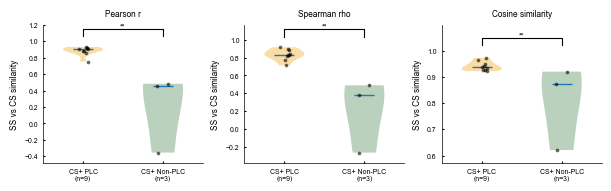

In [41]:
# Combined-session SS-vs-CS similarity:
# Group 1 = CS+ PLC
# Group 2 = non-place cells with max SS rate > 0.5 and max CS rate > 0.5

MIN_VALID_BINS_FOR_SSCS_COMBINED = 20
NONPC_SS_PEAK_THRESHOLD = 0.5
NONPC_CS_PEAK_THRESHOLD = 0.5

if 'scipy_stats' not in globals() or scipy_stats is None:
    try:
        from scipy import stats as scipy_stats
    except Exception:
        scipy_stats = None


def _get_combined_cell_local(dataset_id, cell_idx):
    if 'combined_cell_map' in globals() and isinstance(combined_cell_map, dict):
        c = combined_cell_map.get((dataset_id, int(cell_idx)), None)
        if c is not None:
            return c
    return _get_condition_cell(dataset_id, int(cell_idx), 'combined')


def _safe_nanmax(arr):
    if not isinstance(arr, np.ndarray):
        return np.nan
    if arr.size == 0 or (not np.any(np.isfinite(arr))):
        return np.nan
    return float(np.nanmax(arr))


def _select_nonpc_peak_keys(ss_thr=0.5, cs_thr=0.5):
    keys = []
    rows = []
    for dataset_id, cell_idx in sorted(nonpc_keys):
        c = _get_combined_cell_local(dataset_id, cell_idx)
        if c is None:
            continue

        ss_peak = _safe_nanmax(c.get('ss_rate_map', None))
        cs_peak = _safe_nanmax(c.get('cs_rate_map', None))

        pass_peak = bool(np.isfinite(ss_peak) and np.isfinite(cs_peak) and ss_peak > float(ss_thr) and cs_peak > float(cs_thr))
        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'ss_peak_rate': ss_peak,
            'cs_peak_rate': cs_peak,
            'pass_peak_rule': pass_peak,
        })
        if pass_peak:
            keys.append((str(dataset_id), int(cell_idx)))

    meta = pd.DataFrame(rows)
    return sorted(set(keys)), meta


def _pearson_sscs(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0
    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    return float(np.corrcoef(x, y)[0, 1]), n


def _spearman_sscs(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0
    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n
    if scipy_stats is not None:
        try:
            rho, _p = scipy_stats.spearmanr(x, y)
            return (float(rho) if np.isfinite(rho) else np.nan), n
        except Exception:
            return np.nan, n
    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
        return np.nan, n
    return float(np.corrcoef(rx, ry)[0, 1]), n


def _cosine_sscs(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0
    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n = int(np.sum(valid))
    if n < int(min_valid_bins):
        return np.nan, n
    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n
    c = float(np.dot(x, y) / (nx * ny))
    return float(np.clip(c, -1.0, 1.0)), n


def _collect_combined_sscs_similarity(keys, group_label, metric='pearson'):
    rows = []
    for dataset_id, cell_idx in sorted(keys):
        c = _get_combined_cell_local(dataset_id, cell_idx)
        if c is None:
            rows.append({
                'dataset_id': str(dataset_id),
                'cell_idx': int(cell_idx),
                'group': group_label,
                'metric': metric,
                'n_valid_bins': 0,
                'similarity': np.nan,
                'has_combined': False,
            })
            continue

        c = copy.deepcopy(c)
        _renormalize_ss_cs_maps_per_condition(c)
        ss_map = c.get('ss_norm_map', None)
        cs_map = c.get('cs_norm_map', None)

        if metric == 'pearson':
            sim, n_valid = _pearson_sscs(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS_COMBINED)
        elif metric == 'spearman':
            sim, n_valid = _spearman_sscs(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS_COMBINED)
        elif metric == 'cosine':
            sim, n_valid = _cosine_sscs(ss_map, cs_map, MIN_VALID_BINS_FOR_SSCS_COMBINED)
        else:
            raise ValueError(metric)

        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'group': group_label,
            'metric': metric,
            'n_valid_bins': int(n_valid),
            'similarity': sim,
            'has_combined': True,
        })

    return pd.DataFrame(rows)


def _auto_unpaired_param_first(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    n1, n2 = int(x.size), int(y.size)
    if n1 < 2 or n2 < 2 or scipy_stats is None:
        return np.nan, 'n/a', np.nan, np.nan

    def _shapiro_safe(v):
        vv = np.asarray(v, dtype=float)
        vv = vv[np.isfinite(vv)]
        if vv.size < 3:
            return np.nan
        try:
            return float(scipy_stats.shapiro(vv).pvalue)
        except Exception:
            return np.nan

    sh1 = _shapiro_safe(x)
    sh2 = _shapiro_safe(y)
    can_param = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(sh1) and sh1 >= alpha and
        np.isfinite(sh2) and sh2 >= alpha
    )

    if can_param:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', sh1, sh2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', sh1, sh2
    except Exception:
        return np.nan, 'mannwhitney_u', sh1, sh2


def _sig_label_combined(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def _add_bracket_combined(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color=color, linewidth=0.8)
    ax.text((x1+x2)/2, y+h, label, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)


csplus_plc_group = sorted(csplus_keys)
nonpc_peak_group, nonpc_peak_meta = _select_nonpc_peak_keys(
    ss_thr=NONPC_SS_PEAK_THRESHOLD,
    cs_thr=NONPC_CS_PEAK_THRESHOLD,
)

print('=== Combined session: SS-vs-CS similarity ===')
print(f'CS+ PLC cells: {len(csplus_plc_group)}')
print(f'CS+ Non-PLC cells (SS>{NONPC_SS_PEAK_THRESHOLD}, CS>{NONPC_CS_PEAK_THRESHOLD}): {len(nonpc_peak_group)}')

# Optional outlier filter (same policy: drop keys with low SS Session1-vs-Session2 r)
outlier_keys = set()
if bool(globals().get('REMOVE_LOW_SS_OUTLIER', True)) and ('df_ss_map' in globals()) and isinstance(df_ss_map, pd.DataFrame):
    thr = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))
    if 'corr_r' in df_ss_map.columns:
        odf = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < thr)]
        outlier_keys = set(list(zip(odf['dataset_id'].astype(str), odf['cell_idx'].astype(int))))
    print(f'Outlier filter enabled (SS r < {thr}): removed keys={len(outlier_keys)}')

metrics = ['pearson', 'spearman', 'cosine']
combined_sscs_frames = []
for metric_name in metrics:
    d1 = _collect_combined_sscs_similarity(csplus_plc_group, 'CS+ PLC', metric=metric_name)
    d2 = _collect_combined_sscs_similarity(nonpc_peak_group, 'CS+ Non-PLC', metric=metric_name)

    if len(outlier_keys) > 0:
        keep1 = [k not in outlier_keys for k in zip(d1['dataset_id'].astype(str), d1['cell_idx'].astype(int))]
        keep2 = [k not in outlier_keys for k in zip(d2['dataset_id'].astype(str), d2['cell_idx'].astype(int))]
        d1 = d1.loc[np.asarray(keep1, dtype=bool)].reset_index(drop=True)
        d2 = d2.loc[np.asarray(keep2, dtype=bool)].reset_index(drop=True)

    combined_sscs_frames.append(pd.concat([d1, d2], ignore_index=True))

combined_sscs_df = pd.concat(combined_sscs_frames, ignore_index=True)

for metric_name in metrics:
    d = combined_sscs_df[combined_sscs_df['metric'] == metric_name]
    print(f'\n-- {metric_name} --')
    for g in ['CS+ PLC', 'CS+ Non-PLC']:
        vals = np.asarray(d.loc[d['group'] == g, 'similarity'], dtype=float)
        vals = vals[np.isfinite(vals)]
        print(f"{g}: n={len(vals)}, mean={np.nanmean(vals) if len(vals)>0 else np.nan:.3f}, median={np.nanmedian(vals) if len(vals)>0 else np.nan:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(6.0, 1.8), constrained_layout=True)
metric_titles = {'pearson': 'Pearson r', 'spearman': 'Spearman rho', 'cosine': 'Cosine similarity'}
plot_groups = ['CS+ PLC', 'CS+ Non-PLC']
plot_colors = {'CS+ PLC': '#EE9B00', 'CS+ Non-PLC': '#3A7D44'}
stats_rows = []

for ax, metric_name in zip(axes, metrics):
    d = combined_sscs_df[combined_sscs_df['metric'] == metric_name].copy()

    g1 = np.asarray(d.loc[d['group'] == plot_groups[0], 'similarity'], dtype=float)
    g2 = np.asarray(d.loc[d['group'] == plot_groups[1], 'similarity'], dtype=float)
    g1 = g1[np.isfinite(g1)]
    g2 = g2[np.isfinite(g2)]

    vals_list = [g1, g2]
    for pos, group_name, vals in zip([1.0, 2.0], plot_groups, vals_list):
        if len(vals) >= 3:
            parts = ax.violinplot([vals], positions=[pos], showmedians=True, showextrema=False)
            if 'cmedians' in parts:
                parts['cmedians'].set_color('#1F77B4')
                parts['cmedians'].set_linewidth(1.0)
            for b in parts['bodies']:
                b.set_facecolor(plot_colors[group_name])
                b.set_edgecolor('none')
                b.set_alpha(0.35)
        if len(vals) > 0:
            rng = np.random.default_rng(123 + len(vals))
            xj = pos + (rng.random(len(vals)) - 0.5) * 0.14
            ax.scatter(xj, vals, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)

    p, test_name, sh1, sh2 = _auto_unpaired_param_first(g1, g2, alpha=0.05)
    stats_rows.append({
        'metric': metric_name,
        'test': test_name,
        'p_value': p,
        'n_csplus_plc': int(len(g1)),
        'n_csplus_nonplc': int(len(g2)),
        'shapiro_csplus_plc_p': sh1,
        'shapiro_nonpc_peak_p': sh2,
    })

    y_vals = np.concatenate([g1 if len(g1) else np.array([0.0]), g2 if len(g2) else np.array([0.0])])
    y_min = float(np.nanmin(y_vals)) if len(y_vals) else 0.0
    y_max = float(np.nanmax(y_vals)) if len(y_vals) else 1.0
    pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)
    y0 = y_min - pad
    y1 = y_max + pad
    h = 0.06 * max(0.2, y1 - y0)
    _add_bracket_combined(ax, 1.0, 2.0, y1, h, _sig_label_combined(p), color='black')

    ax.set_title(metric_titles[metric_name], fontsize=6, fontname='Arial')
    ax.set_xticks([1.0, 2.0])
    ax.set_xticklabels([f'CS+ PLC\n(n={len(g1)})', f'CS+ Non-PLC\n(n={len(g2)})'], fontsize=4, fontname='Arial')
    ax.set_ylabel('SS vs CS similarity', fontsize=6, fontname='Arial')
    ax.tick_params(axis='both', labelsize=5)
    for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(y0, y1 + h + 0.05)

combined_sscs_stats_df = pd.DataFrame(stats_rows)
print('\n=== Statistical tests: CS+ PLC vs CS+ Non-PLC (combined maps) ===')
display(combined_sscs_stats_df)

fig_path = os.path.join(FIGURE_SAVE_FOLDER, 'combined_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.svg')
fig.savefig(fig_path, dpi=300)
print(f'Saved: {fig_path}')

csv_path = os.path.join(FIGURE_SAVE_FOLDER, 'combined_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5.csv')
combined_sscs_df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

stats_csv_path = os.path.join(FIGURE_SAVE_FOLDER, 'combined_ss_vs_cs_similarity_csplusplc_vs_nonpc_peak_gt0p5_stats.csv')
combined_sscs_stats_df.to_csv(stats_csv_path, index=False)
print(f'Saved: {stats_csv_path}')

nonpc_meta_path = os.path.join(FIGURE_SAVE_FOLDER, 'combined_nonpc_peak_filter_meta_gt0p5.csv')
nonpc_peak_meta.to_csv(nonpc_meta_path, index=False)
print(f'Saved: {nonpc_meta_path}')

# Compare stability among 4 groups (CS+ PLC, CS+ Non-PLC, CS- PLC, CS- Non-PLC)

=== 4-group map similarity populations ===
CS+ PLC: 9
CS- PLC: 6
CS+ Non-PLC (SS>0.5, CS>0.5): 3
CS- Non-PLC (SS>0.5, CS<0.5): 13
Outlier filter applied=False, removed_keys=0

=== Session1 vs Session2 similarity summary (map-specific groups x 5 maps x 3 metrics) ===


,metric,metric_label,map_key,map_label,group,n_total_cells,n_with_session1_and_2,n_valid_similarity,mean_similarity,median_similarity,std_similarity
0,pearson,Weighted Pearson r,rate_map,All-spike map,CS+ PLC,9,9,8,0.552149,0.644774,0.331083
1,pearson,Weighted Pearson r,rate_map,All-spike map,CS- PLC,6,6,5,0.724217,0.858648,0.266209
2,pearson,Weighted Pearson r,rate_map,All-spike map,CS+ Non-PLC,3,3,3,0.472992,0.604275,0.289149
3,pearson,Weighted Pearson r,rate_map,All-spike map,CS- Non-PLC,13,13,10,0.334662,0.322075,0.311746
4,pearson,Weighted Pearson r,ss_norm_map,SS map,CS+ PLC,9,9,8,0.581496,0.654876,0.287513
5,pearson,Weighted Pearson r,ss_norm_map,SS map,CS- PLC,6,6,4,0.671754,0.681176,0.298328
6,pearson,Weighted Pearson r,ss_norm_map,SS map,CS+ Non-PLC,3,3,3,0.650894,0.600648,0.182465
7,pearson,Weighted Pearson r,ss_norm_map,SS map,CS- Non-PLC,13,13,9,0.372657,0.314234,0.298948
8,pearson,Weighted Pearson r,cs_norm_map,CS map,CS+ PLC,9,9,8,0.355412,0.486669,0.422392
9,pearson,Weighted Pearson r,cs_norm_map,CS map,CS+ Non-PLC,3,3,2,0.130981,0.130981,0.545098


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_pearson.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_spearman.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_cosine.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics_summary.csv



,metric,metric_label,map_key,map_label,group_a,group_b,test,p_value,sig_label,is_significant,n_group_a,n_group_b,shapiro_group_a_p,shapiro_group_b_p
0,pearson,Weighted Pearson r,rate_map,All-spike map,CS- PLC,CS- Non-PLC,welch_t,0.031733,*,True,5,10,0.385769,0.424771
1,cosine,Cosine similarity,theta_map,Theta Vm map,CS+ PLC,CS- PLC,mannwhitney_u,0.010878,*,True,8,5,0.114535,0.041244
2,cosine,Cosine similarity,theta_map,Theta Vm map,CS+ PLC,CS- Non-PLC,mannwhitney_u,0.000868,***,True,8,10,0.114535,0.036639
3,cosine,Cosine similarity,theta_map,Theta Vm map,CS+ Non-PLC,CS- Non-PLC,mannwhitney_u,0.006993,**,True,3,10,0.907533,0.036639


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics_pairwise_stats.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics_pairwise_stats_significant_only.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/nonpc_csplus_csminus_peak_groups_meta.csv


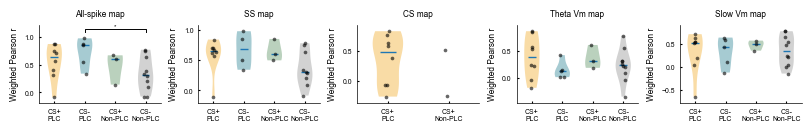

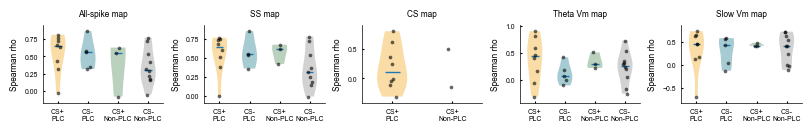

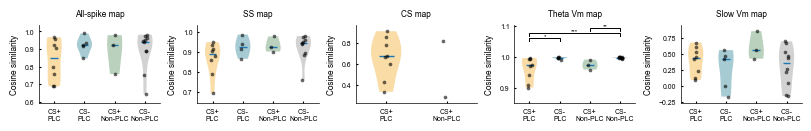

In [42]:
# 4-group Session1 vs Session2 map similarities
# Groups: CS+ PLC, CS- PLC, CS+ Non-PLC, CS- Non-PLC
# Map order: All spike, SS, CS, Theta Vm, Slow Vm
# Metrics: Pearson r, Spearman rho, Cosine similarity

MIN_VALID_BINS_FOR_4GROUP_MAP_SIM = 20
NONPC_SS_PEAK_THRESHOLD_HZ = 0.5
NONPC_CS_PEAK_THRESHOLD_HZ = 0.5
APPLY_OUTLIER_FILTER_4GROUP = False

ALL_GROUPS_4GROUP = ['CS+ PLC', 'CS- PLC', 'CS+ Non-PLC', 'CS- Non-PLC']
CS_GROUPS_4GROUP = ['CS+ PLC', 'CS+ Non-PLC']

MAP_SPECS_4GROUP = [
    ('rate_map', 'All-spike map', ALL_GROUPS_4GROUP),
    ('ss_norm_map', 'SS map', ALL_GROUPS_4GROUP),
    ('cs_norm_map', 'CS map', CS_GROUPS_4GROUP),
    ('theta_map', 'Theta Vm map', ALL_GROUPS_4GROUP),
    ('slow_map', 'Slow Vm map', ALL_GROUPS_4GROUP),
]

METRIC_SPECS_4GROUP = [
    ('pearson', 'Weighted Pearson r'),
    ('spearman', 'Spearman rho'),
    ('cosine', 'Cosine similarity'),
]

from itertools import combinations

if 'scipy_stats' not in globals() or scipy_stats is None:
    try:
        from scipy import stats as scipy_stats
    except Exception:
        scipy_stats = None


def _safe_nanmax_4group(arr):
    if not isinstance(arr, np.ndarray):
        return np.nan
    if arr.size == 0 or (not np.any(np.isfinite(arr))):
        return np.nan
    return float(np.nanmax(arr))


def _get_combined_cell_4group(dataset_id, cell_idx):
    if '_get_combined_cell_local' in globals():
        return _get_combined_cell_local(dataset_id, int(cell_idx))
    if 'combined_cell_map' in globals() and isinstance(combined_cell_map, dict):
        c = combined_cell_map.get((dataset_id, int(cell_idx)), None)
        if c is not None:
            return c
    return _get_condition_cell(dataset_id, int(cell_idx), 'combined')


def _build_nonpc_groups_4group(ss_thr=0.5, cs_thr=0.5):
    csplus_nonpc = []
    csminus_nonpc = []
    rows = []

    for dataset_id, cell_idx in sorted(nonpc_keys):
        c = _get_combined_cell_4group(dataset_id, cell_idx)
        if c is None:
            continue

        ss_peak = _safe_nanmax_4group(c.get('ss_rate_map', None))
        cs_peak = _safe_nanmax_4group(c.get('cs_rate_map', None))

        is_csplus_nonpc = bool(np.isfinite(ss_peak) and np.isfinite(cs_peak) and ss_peak > float(ss_thr) and cs_peak > float(cs_thr))
        is_csminus_nonpc = bool(np.isfinite(ss_peak) and np.isfinite(cs_peak) and ss_peak > float(ss_thr) and cs_peak < float(cs_thr))

        if is_csplus_nonpc:
            csplus_nonpc.append((dataset_id, int(cell_idx)))
        if is_csminus_nonpc:
            csminus_nonpc.append((dataset_id, int(cell_idx)))

        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'ss_peak_hz': ss_peak,
            'cs_peak_hz': cs_peak,
            'is_csplus_nonpc': is_csplus_nonpc,
            'is_csminus_nonpc': is_csminus_nonpc,
        })

    return sorted(set(csplus_nonpc)), sorted(set(csminus_nonpc)), pd.DataFrame(rows)


def _pearson_similarity_4group(map1, map2, occ1=None, occ2=None, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if not isinstance(occ1, np.ndarray) or not isinstance(occ2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape or map1.shape != occ1.shape or map1.shape != occ2.shape:
        return np.nan, 0

    min_valid_bins_w = int(globals().get('MIN_VALID_BINS_FOR_CORR_WEIGHTED', min_valid_bins))
    min_eff_bins_w = int(globals().get('MIN_EFFECTIVE_BINS_WEIGHTED', min_valid_bins_w))
    min_occ_w = float(globals().get('MIN_OCCUPANCY_WEIGHT', 0.0))

    # Prefer the shared weighted implementation used elsewhere in this notebook.
    if '_map_pair_pearson_distance' in globals() and callable(_map_pair_pearson_distance):
        try:
            return _map_pair_pearson_distance(
                map1,
                map2,
                occ1,
                occ2,
                min_valid_bins=min_valid_bins_w,
                min_eff_bins=min_eff_bins_w,
                min_occ=min_occ_w,
            )
        except Exception:
            pass

    # Fallback: occupancy-weighted Pearson r with w=min(occ_s1, occ_s2)
    x = np.asarray(map1, dtype=float).ravel()
    y = np.asarray(map2, dtype=float).ravel()
    w = np.minimum(np.asarray(occ1, dtype=float).ravel(), np.asarray(occ2, dtype=float).ravel())

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > float(min_occ_w))
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins_w):
        return np.nan, n_valid

    x = x[valid]
    y = y[valid]
    w = w[valid]
    sw = float(np.sum(w))
    if sw <= 0:
        return np.nan, n_valid

    mx = float(np.sum(w * x) / sw)
    my = float(np.sum(w * y) / sw)
    dx = x - mx
    dy = y - my

    den_x = float(np.sum(w * dx * dx))
    den_y = float(np.sum(w * dy * dy))
    den = np.sqrt(den_x * den_y)
    if den <= 0:
        return np.nan, n_valid

    sw2 = float(np.sum(w * w))
    n_eff = (sw * sw / sw2) if sw2 > 0 else 0.0
    if n_eff < float(min_eff_bins_w):
        return np.nan, n_valid

    r = float(np.sum(w * dx * dy) / den)
    if not np.isfinite(r):
        return np.nan, n_valid
    return float(np.clip(r, -1.0, 1.0)), n_valid

def _spearman_similarity_4group(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, n_valid

    if scipy_stats is not None:
        try:
            rho, _p = scipy_stats.spearmanr(x, y)
            if np.isfinite(rho):
                return float(rho), n_valid
            return np.nan, n_valid
        except Exception:
            return np.nan, n_valid

    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    if np.nanstd(rx) == 0 or np.nanstd(ry) == 0:
        return np.nan, n_valid
    return float(np.corrcoef(rx, ry)[0, 1]), n_valid


def _cosine_similarity_4group(map1, map2, min_valid_bins=20):
    if not isinstance(map1, np.ndarray) or not isinstance(map2, np.ndarray):
        return np.nan, 0
    if map1.shape != map2.shape:
        return np.nan, 0

    a = np.asarray(map1, dtype=float).ravel()
    b = np.asarray(map2, dtype=float).ravel()
    valid = np.isfinite(a) & np.isfinite(b)
    n_valid = int(np.sum(valid))
    if n_valid < int(min_valid_bins):
        return np.nan, n_valid

    x = a[valid]
    y = b[valid]
    nx = float(np.linalg.norm(x))
    ny = float(np.linalg.norm(y))
    if nx <= 0 or ny <= 0:
        return np.nan, n_valid

    c = float(np.dot(x, y) / (nx * ny))
    return float(np.clip(c, -1.0, 1.0)), n_valid


def _map_similarity_by_metric_4group(map1, map2, metric_name, min_valid_bins=20, occ1=None, occ2=None):
    if metric_name == 'pearson':
        return _pearson_similarity_4group(map1, map2, occ1=occ1, occ2=occ2, min_valid_bins=min_valid_bins)
    if metric_name == 'spearman':
        return _spearman_similarity_4group(map1, map2, min_valid_bins=min_valid_bins)
    if metric_name == 'cosine':
        return _cosine_similarity_4group(map1, map2, min_valid_bins=min_valid_bins)
    raise ValueError(f'Unknown metric: {metric_name}')

def _collect_similarity_for_map_metric_4group(keys, group_label, map_key, map_label, metric_name, metric_label):
    rows = []
    for dataset_id, cell_idx in sorted(keys):
        c1 = _get_condition_cell(dataset_id, int(cell_idx), 'session1')
        c2 = _get_condition_cell(dataset_id, int(cell_idx), 'session2')

        if c1 is None or c2 is None:
            rows.append({
                'dataset_id': str(dataset_id),
                'cell_idx': int(cell_idx),
                'group': group_label,
                'map_key': map_key,
                'map_label': map_label,
                'metric': metric_name,
                'metric_label': metric_label,
                'has_both_sessions': False,
                'n_valid_bins': 0,
                'similarity': np.nan,
            })
            continue

        # S1-vs-S2 peak-rate gate
        if bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)):
            thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
            if not _passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key=map_key, threshold=thr):
                rows.append({
                    'dataset_id': str(dataset_id),
                    'cell_idx': int(cell_idx),
                    'group': group_label,
                    'map_key': map_key,
                    'map_label': map_label,
                    'metric': metric_name,
                    'metric_label': metric_label,
                    'has_both_sessions': True,
                    'n_valid_bins': 0,
                    'similarity': np.nan,
                })
                continue

        c1 = copy.deepcopy(c1)
        c2 = copy.deepcopy(c2)
        _renormalize_ss_cs_maps_per_condition(c1)
        _renormalize_ss_cs_maps_per_condition(c2)

        sim, n_valid = _map_similarity_by_metric_4group(
            c1.get(map_key, None),
            c2.get(map_key, None),
            metric_name=metric_name,
            min_valid_bins=MIN_VALID_BINS_FOR_4GROUP_MAP_SIM,
            occ1=c1.get('occupancy', None),
            occ2=c2.get('occupancy', None),
        )

        rows.append({
            'dataset_id': str(dataset_id),
            'cell_idx': int(cell_idx),
            'group': group_label,
            'map_key': map_key,
            'map_label': map_label,
            'metric': metric_name,
            'metric_label': metric_label,
            'has_both_sessions': True,
            'n_valid_bins': int(n_valid),
            'similarity': sim,
        })

    return pd.DataFrame(rows)


def _maybe_apply_outlier_filter_4group(df_in):
    if not APPLY_OUTLIER_FILTER_4GROUP:
        return df_in.copy(), 0

    outlier_keys = set()
    if ('df_ss_map' in globals()) and isinstance(df_ss_map, pd.DataFrame) and ('corr_r' in df_ss_map.columns):
        thr = float(globals().get('SS_R_OUTLIER_THRESHOLD', 0.1))
        odf = df_ss_map[np.isfinite(df_ss_map['corr_r']) & (df_ss_map['corr_r'] < thr)]
        outlier_keys = set(list(zip(odf['dataset_id'].astype(str), odf['cell_idx'].astype(int))))

    if len(outlier_keys) == 0:
        return df_in.copy(), 0

    keys = list(zip(df_in['dataset_id'].astype(str), df_in['cell_idx'].astype(int)))
    keep = [k not in outlier_keys for k in keys]
    return df_in.loc[np.asarray(keep, dtype=bool)].reset_index(drop=True), len(outlier_keys)


def _draw_group_violin_4group(ax, vals, pos, color, seed):
    if len(vals) >= 3:
        parts = ax.violinplot([vals], positions=[pos], showmedians=True, showextrema=False)
        if 'cmedians' in parts:
            parts['cmedians'].set_color('#1F77B4')
            parts['cmedians'].set_linewidth(1.0)
        for b in parts['bodies']:
            b.set_facecolor(color)
            b.set_edgecolor('none')
            b.set_alpha(0.35)
    if len(vals) > 0:
        rng = np.random.default_rng(seed)
        xj = pos + (rng.random(len(vals)) - 0.5) * 0.14
        ax.scatter(xj, vals, s=7, color='black', alpha=0.6, linewidths=0, zorder=3)


def _shapiro_p_4group(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = int(arr.size)
    if scipy_stats is None or n < 3:
        return np.nan
    try:
        if n > 5000:
            rng = np.random.default_rng(0)
            arr = rng.choice(arr, size=5000, replace=False)
        return float(scipy_stats.shapiro(arr).pvalue)
    except Exception:
        return np.nan


def _auto_unpaired_param_first_4group(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = int(x.size), int(y.size)
    if scipy_stats is None or n1 < 2 or n2 < 2:
        return np.nan, 'n/a', np.nan, np.nan, n1, n2

    sh1 = _shapiro_p_4group(x)
    sh2 = _shapiro_p_4group(y)
    can_parametric = (
        n1 >= 5 and n2 >= 5 and
        np.isfinite(sh1) and sh1 >= alpha and
        np.isfinite(sh2) and sh2 >= alpha
    )

    if can_parametric:
        try:
            _stat, p = scipy_stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            return float(p), 'welch_t', sh1, sh2, n1, n2
        except Exception:
            pass

    try:
        _stat, p = scipy_stats.mannwhitneyu(x, y, alternative='two-sided')
        return float(p), 'mannwhitney_u', sh1, sh2, n1, n2
    except Exception:
        return np.nan, 'mannwhitney_u', sh1, sh2, n1, n2


def _sig_label_4group(p):
    if not np.isfinite(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def _add_bracket_4group(ax, x1, x2, y, h, label, color='black'):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, linewidth=0.7)
    ax.text((x1 + x2) / 2.0, y + h, label, ha='center', va='bottom', fontsize=4.5, fontname='Arial', color=color)


csplus_nonpc_keys_4group, csminus_nonpc_keys_4group, nonpc_peak_meta_4group = _build_nonpc_groups_4group(
    ss_thr=NONPC_SS_PEAK_THRESHOLD_HZ,
    cs_thr=NONPC_CS_PEAK_THRESHOLD_HZ,
)

group_keys_4group = {
    'CS+ PLC': sorted(csplus_keys),
    'CS- PLC': sorted(csminus_keys),
    'CS+ Non-PLC': csplus_nonpc_keys_4group,
    'CS- Non-PLC': csminus_nonpc_keys_4group,
}

print('=== 4-group map similarity populations ===')
print(f"CS+ PLC: {len(group_keys_4group['CS+ PLC'])}")
print(f"CS- PLC: {len(group_keys_4group['CS- PLC'])}")
print(f"CS+ Non-PLC (SS>{NONPC_SS_PEAK_THRESHOLD_HZ}, CS>{NONPC_CS_PEAK_THRESHOLD_HZ}): {len(group_keys_4group['CS+ Non-PLC'])}")
print(f"CS- Non-PLC (SS>{NONPC_SS_PEAK_THRESHOLD_HZ}, CS<{NONPC_CS_PEAK_THRESHOLD_HZ}): {len(group_keys_4group['CS- Non-PLC'])}")

all_rows_4group = []
for metric_name, metric_label in METRIC_SPECS_4GROUP:
    for map_key, map_label, map_groups in MAP_SPECS_4GROUP:
        for group_label in map_groups:
            keys = group_keys_4group[group_label]
            all_rows_4group.append(
                _collect_similarity_for_map_metric_4group(
                    keys,
                    group_label,
                    map_key,
                    map_label,
                    metric_name,
                    metric_label,
                )
            )

similarity_4group_df = pd.concat(all_rows_4group, ignore_index=True)
similarity_4group_df, n_removed_outlier_keys = _maybe_apply_outlier_filter_4group(similarity_4group_df)
print(f'Outlier filter applied={APPLY_OUTLIER_FILTER_4GROUP}, removed_keys={n_removed_outlier_keys}')

summary_rows = []
for metric_name, metric_label in METRIC_SPECS_4GROUP:
    for map_key, map_label, map_groups in MAP_SPECS_4GROUP:
        for group_label in map_groups:
            d = similarity_4group_df[
                (similarity_4group_df['metric'] == metric_name) &
                (similarity_4group_df['map_key'] == map_key) &
                (similarity_4group_df['group'] == group_label)
            ].copy()
            vals = np.asarray(d['similarity'], dtype=float)
            vals = vals[np.isfinite(vals)]
            summary_rows.append({
                'metric': metric_name,
                'metric_label': metric_label,
                'map_key': map_key,
                'map_label': map_label,
                'group': group_label,
                'n_total_cells': int(len(d)),
                'n_with_session1_and_2': int(d['has_both_sessions'].sum()) if len(d) > 0 else 0,
                'n_valid_similarity': int(len(vals)),
                'mean_similarity': float(np.nanmean(vals)) if len(vals) > 0 else np.nan,
                'median_similarity': float(np.nanmedian(vals)) if len(vals) > 0 else np.nan,
                'std_similarity': float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else np.nan,
            })

similarity_4group_summary_df = pd.DataFrame(summary_rows)
print()
print('=== Session1 vs Session2 similarity summary (map-specific groups x 5 maps x 3 metrics) ===')
display(similarity_4group_summary_df)

plot_colors = {
    'CS+ PLC': '#EE9B00',
    'CS- PLC': '#026C80',
    'CS+ Non-PLC': '#3A7D44',
    'CS- Non-PLC': '#7F7F7F',
}


def _group_label_2line_4group(g):
    g = str(g)
    if ' ' in g:
        a, b = g.split(' ', 1)
        return f"{a}\n{b}"
    return g

pairwise_stats_rows_4group = []

for metric_name, metric_label in METRIC_SPECS_4GROUP:
    fig, axes = plt.subplots(1, 5, figsize=(8, 1.2), constrained_layout=True, sharey=False)

    for ax, (map_key, map_label, map_groups) in zip(axes, MAP_SPECS_4GROUP):
        vals_by_group = {}
        for g in map_groups:
            vals = np.asarray(
                similarity_4group_df.loc[
                    (similarity_4group_df['metric'] == metric_name) &
                    (similarity_4group_df['map_key'] == map_key) &
                    (similarity_4group_df['group'] == g),
                    'similarity'
                ],
                dtype=float,
            )
            vals_by_group[g] = vals[np.isfinite(vals)]

        for i, g in enumerate(map_groups, start=1):
            _draw_group_violin_4group(ax, vals_by_group[g], i, plot_colors[g], seed=1200 + i)

        ax.set_title(map_label, fontsize=6, fontname='Arial')
        ax.set_ylabel(metric_label, fontsize=6, fontname='Arial')
        ax.set_xticks(list(range(1, len(map_groups) + 1)))
        ax.set_xticklabels(
            [_group_label_2line_4group(g) for g in map_groups],
            fontsize=4,
            fontname='Arial'
        )
        ax.tick_params(axis='both', labelsize=5)
        for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            lbl.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlim(0.5, len(map_groups) + 0.5)

        flat = np.concatenate([v for v in vals_by_group.values() if len(v) > 0]) if any(len(v) > 0 for v in vals_by_group.values()) else np.array([0.0, 1.0])
        y_min = float(np.nanmin(flat))
        y_max = float(np.nanmax(flat))
        pad = max(0.05, 0.1 * (y_max - y_min) if y_max > y_min else 0.1)

        yr = max(0.2, (y_max + pad) - (y_min - pad))
        h = 0.04 * yr
        gap = 0.04 * yr
        y_start = y_max + pad + 0.01 * yr

        pair_list = list(combinations(range(len(map_groups)), 2))
        y_cursor = y_start
        n_sig_pairs = 0
        for pair_idx, (ia, ib) in enumerate(pair_list):
            ga = map_groups[ia]
            gb = map_groups[ib]
            va = vals_by_group[ga]
            vb = vals_by_group[gb]

            p_val, test_name, sh1, sh2, n1, n2 = _auto_unpaired_param_first_4group(va, vb, alpha=0.05)
            label = _sig_label_4group(p_val)
            is_sig = bool(np.isfinite(p_val) and (p_val < 0.05))
            x1 = ia + 1
            x2 = ib + 1
            if is_sig:
                _add_bracket_4group(ax, x1, x2, y_cursor, h, label)
                y_cursor += h + gap
                n_sig_pairs += 1

            pairwise_stats_rows_4group.append({
                'metric': metric_name,
                'metric_label': metric_label,
                'map_key': map_key,
                'map_label': map_label,
                'group_a': ga,
                'group_b': gb,
                'test': test_name,
                'p_value': p_val,
                'sig_label': label,
                'is_significant': is_sig,
                'n_group_a': int(n1),
                'n_group_b': int(n2),
                'shapiro_group_a_p': sh1,
                'shapiro_group_b_p': sh2,
            })

        y_top = (y_cursor + 0.02 * yr) if n_sig_pairs > 0 else (y_max + pad)
        ax.set_ylim(y_min - pad, y_top)

    fig_path = os.path.join(FIGURE_SAVE_FOLDER, f'session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_{metric_name}.svg')
    fig.savefig(fig_path, dpi=300)
    print(f'Saved: {fig_path}')

detail_csv = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics.csv')
similarity_4group_df.to_csv(detail_csv, index=False)
print(f'Saved: {detail_csv}')

summary_csv = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics_summary.csv')
similarity_4group_summary_df.to_csv(summary_csv, index=False)
print(f'Saved: {summary_csv}')

pairwise_stats_4group_df = pd.DataFrame(pairwise_stats_rows_4group)
pairwise_sig_4group_df = pairwise_stats_4group_df[pairwise_stats_4group_df['is_significant'] == True].reset_index(drop=True)
print()
print('=== Pairwise group tests (significant only; each map, each metric) ===')
if len(pairwise_sig_4group_df) == 0:
    print('No significant pairs.')
else:
    display(pairwise_sig_4group_df)

pairwise_csv = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics_pairwise_stats.csv')
pairwise_stats_4group_df.to_csv(pairwise_csv, index=False)
print(f'Saved: {pairwise_csv}')

pairwise_sig_csv = os.path.join(FIGURE_SAVE_FOLDER, 'session1_vs_session2_similarity_4groups_all_ss_cs_theta_slow_allmetrics_pairwise_stats_significant_only.csv')
pairwise_sig_4group_df.to_csv(pairwise_sig_csv, index=False)
print(f'Saved: {pairwise_sig_csv}')

meta_csv = os.path.join(FIGURE_SAVE_FOLDER, 'nonpc_csplus_csminus_peak_groups_meta.csv')
nonpc_peak_meta_4group.to_csv(meta_csv, index=False)
print(f'Saved: {meta_csv}')


=== CS+ PLC slow-vs-other similarity correlation ===
Rows in source table: 408
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_csplusplc_slow_vs_other_similarity_scatter_pearson.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_csplusplc_slow_vs_other_similarity_scatter_spearman.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_csplusplc_slow_vs_other_similarity_scatter_cosine.svg

=== Regression/correlation summary (CS+ PLC) ===


,metric,x_map,y_map,n,slope,intercept,corr_r,corr_p
0,pearson,slow_map,rate_map,8,0.644130,0.346089,0.876049,0.004329
1,pearson,slow_map,ss_norm_map,8,0.575851,0.397278,0.901872,0.002192
2,pearson,slow_map,cs_norm_map,8,0.632344,0.153122,0.674108,0.066758
3,pearson,slow_map,theta_map,8,0.659008,0.174179,0.757409,0.029513
4,spearman,slow_map,rate_map,8,0.529265,0.375797,0.850625,0.007427
5,spearman,slow_map,ss_norm_map,8,0.416175,0.423694,0.723188,0.042628
6,spearman,slow_map,cs_norm_map,8,0.539271,0.023606,0.645957,0.083572
7,spearman,slow_map,theta_map,8,0.820999,0.118446,0.895675,0.002621
8,cosine,slow_map,rate_map,8,0.233309,0.746065,0.447050,0.266766
9,cosine,slow_map,ss_norm_map,8,0.111984,0.823085,0.289856,0.486194


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/session1_vs_session2_csplusplc_slow_vs_other_similarity_scatter_stats.csv


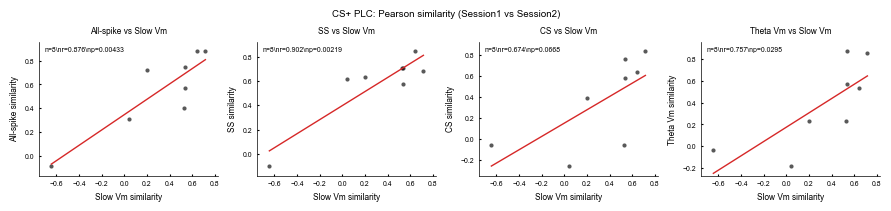

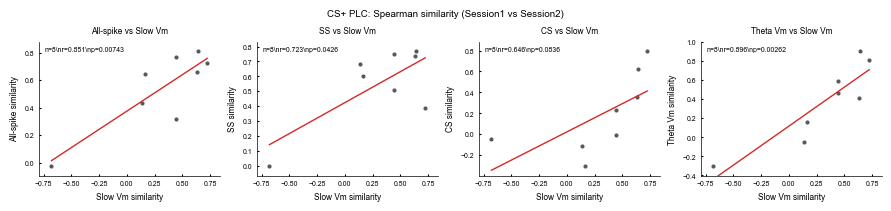

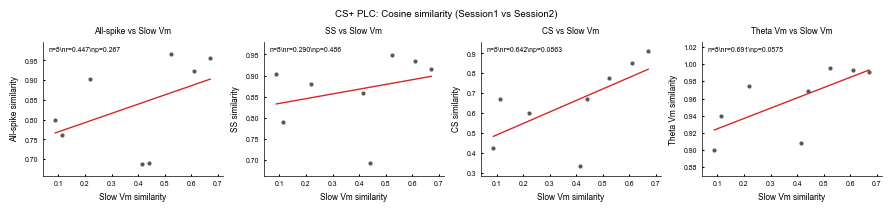

In [43]:
# CS+ PLC only: correlation between Slow Vm similarity and other map similarities
# Session1 vs Session2 map similarities
# Output: 3 figures (Pearson/Spearman/Cosine), each with fitted lines

if 'scipy_stats' not in globals() or scipy_stats is None:
    try:
        from scipy import stats as scipy_stats
    except Exception:
        scipy_stats = None

TARGET_GROUP_FOR_SCATTER = 'CS+ PLC'
METRICS_FOR_SCATTER = ['pearson', 'spearman', 'cosine']
X_MAP_KEY = 'slow_map'
X_MAP_LABEL = 'Slow Vm'
Y_MAPS = [
    ('rate_map', 'All-spike'),
    ('ss_norm_map', 'SS'),
    ('cs_norm_map', 'CS'),
    ('theta_map', 'Theta Vm'),
]


def _ensure_similarity_df_for_scatter():
    if 'similarity_4group_df' in globals() and isinstance(similarity_4group_df, pd.DataFrame) and len(similarity_4group_df) > 0:
        req_cols = {'dataset_id', 'cell_idx', 'group', 'map_key', 'metric', 'similarity'}
        if req_cols.issubset(set(similarity_4group_df.columns)):
            return similarity_4group_df.copy()

    rows = []
    for metric_name in METRICS_FOR_SCATTER:
        for map_key, map_label in [(X_MAP_KEY, X_MAP_LABEL)] + Y_MAPS:
            for dataset_id, cell_idx in sorted(csplus_keys):
                c1 = _get_condition_cell(dataset_id, int(cell_idx), 'session1')
                c2 = _get_condition_cell(dataset_id, int(cell_idx), 'session2')
                if c1 is None or c2 is None:
                    rows.append({
                        'dataset_id': str(dataset_id),
                        'cell_idx': int(cell_idx),
                        'group': TARGET_GROUP_FOR_SCATTER,
                        'map_key': map_key,
                        'map_label': map_label,
                        'metric': metric_name,
                        'metric_label': metric_name,
                        'has_both_sessions': False,
                        'n_valid_bins': 0,
                        'similarity': np.nan,
                    })
                    continue

                c1 = copy.deepcopy(c1)
                c2 = copy.deepcopy(c2)
                _renormalize_ss_cs_maps_per_condition(c1)
                _renormalize_ss_cs_maps_per_condition(c2)

                # Peak-rate gate for S1 vs S2 map comparison
                if bool(globals().get('ENFORCE_S1S2_MIN_PEAK_RATE_FILTER', True)):
                    thr = float(globals().get('S1S2_MIN_PEAK_RATE_HZ', 0.5))
                    if not _passes_s1s2_peak_threshold(dataset_id, cell_idx, map_key=map_key, threshold=thr):
                        sim, n_valid = np.nan, 0
                    elif '_map_similarity_by_metric_4group' in globals():
                        sim, n_valid = _map_similarity_by_metric_4group(
                            c1.get(map_key, None),
                            c2.get(map_key, None),
                            metric_name=metric_name,
                            min_valid_bins=int(globals().get('MIN_VALID_BINS_FOR_4GROUP_MAP_SIM', 20)),
                        )
                    else:
                        sim, n_valid = np.nan, 0
                elif '_map_similarity_by_metric_4group' in globals():
                    sim, n_valid = _map_similarity_by_metric_4group(
                        c1.get(map_key, None),
                        c2.get(map_key, None),
                        metric_name=metric_name,
                        min_valid_bins=int(globals().get('MIN_VALID_BINS_FOR_4GROUP_MAP_SIM', 20)),
                    )
                else:
                    sim, n_valid = np.nan, 0

                rows.append({
                    'dataset_id': str(dataset_id),
                    'cell_idx': int(cell_idx),
                    'group': TARGET_GROUP_FOR_SCATTER,
                    'map_key': map_key,
                    'map_label': map_label,
                    'metric': metric_name,
                    'metric_label': metric_name,
                    'has_both_sessions': True,
                    'n_valid_bins': int(n_valid),
                    'similarity': sim,
                })

    return pd.DataFrame(rows)


def _pair_xy_for_metric_map(df, metric_name, y_map_key):
    d = df[(df['group'] == TARGET_GROUP_FOR_SCATTER) & (df['metric'] == metric_name)].copy()
    dx = d[d['map_key'] == X_MAP_KEY][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'x'})
    dy = d[d['map_key'] == y_map_key][['dataset_id', 'cell_idx', 'similarity']].rename(columns={'similarity': 'y'})
    m = dx.merge(dy, on=['dataset_id', 'cell_idx'], how='inner')
    m = m[np.isfinite(m['x']) & np.isfinite(m['y'])].reset_index(drop=True)
    return m


def _fit_line_and_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n = int(len(x))

    if n < 2:
        return np.nan, np.nan, np.nan, np.nan, n

    if np.nanstd(x) == 0:
        slope = np.nan
        intercept = np.nan
    else:
        slope, intercept = np.polyfit(x, y, 1)

    if scipy_stats is not None and n >= 3 and np.nanstd(x) > 0 and np.nanstd(y) > 0:
        try:
            r_val, p_val = scipy_stats.pearsonr(x, y)
            return float(slope), float(intercept), float(r_val), float(p_val), n
        except Exception:
            return float(slope), float(intercept), np.nan, np.nan, n

    if np.nanstd(x) > 0 and np.nanstd(y) > 0:
        r_val = float(np.corrcoef(x, y)[0, 1])
    else:
        r_val = np.nan
    return float(slope), float(intercept), r_val, np.nan, n


def _metric_label(metric_name):
    return {
        'pearson': 'Pearson similarity',
        'spearman': 'Spearman similarity',
        'cosine': 'Cosine similarity',
    }.get(metric_name, metric_name)


scatter_source_df = _ensure_similarity_df_for_scatter()
print('=== CS+ PLC slow-vs-other similarity correlation ===')
print(f'Rows in source table: {len(scatter_source_df)}')

stats_rows = []
for metric_name in METRICS_FOR_SCATTER:
    fig, axes = plt.subplots(1, 4, figsize=(8.8, 2.0), constrained_layout=True)

    for ax, (y_map_key, y_map_label) in zip(axes, Y_MAPS):
        paired = _pair_xy_for_metric_map(scatter_source_df, metric_name, y_map_key)
        x = paired['x'].to_numpy(dtype=float)
        y = paired['y'].to_numpy(dtype=float)

        slope, intercept, r_val, p_val, n = _fit_line_and_corr(x, y)
        stats_rows.append({
            'metric': metric_name,
            'x_map': X_MAP_KEY,
            'y_map': y_map_key,
            'n': int(n),
            'slope': slope,
            'intercept': intercept,
            'corr_r': r_val,
            'corr_p': p_val,
        })

        if n > 0:
            ax.scatter(x, y, s=9, color='black', alpha=0.65, linewidths=0)

        if n >= 2 and np.isfinite(slope) and np.isfinite(intercept):
            x_min = float(np.nanmin(x))
            x_max = float(np.nanmax(x))
            if x_max > x_min:
                xx = np.linspace(x_min, x_max, 100)
                yy = slope * xx + intercept
                ax.plot(xx, yy, color='#D62828', linewidth=1.0)

        ax.set_title(f'{y_map_label} vs {X_MAP_LABEL}', fontsize=6, fontname='Arial')
        ax.set_xlabel(f'{X_MAP_LABEL} similarity', fontsize=6, fontname='Arial')
        ax.set_ylabel(f'{y_map_label} similarity', fontsize=6, fontname='Arial')
        ax.tick_params(axis='both', labelsize=5)
        for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            lbl.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if n > 0:
            x_pad = max(0.03, 0.08 * (np.nanmax(x) - np.nanmin(x)) if np.nanmax(x) > np.nanmin(x) else 0.1)
            y_pad = max(0.03, 0.08 * (np.nanmax(y) - np.nanmin(y)) if np.nanmax(y) > np.nanmin(y) else 0.1)
            ax.set_xlim(float(np.nanmin(x)) - x_pad, float(np.nanmax(x)) + x_pad)
            ax.set_ylim(float(np.nanmin(y)) - y_pad, float(np.nanmax(y)) + y_pad)

        p_txt = f'{p_val:.3g}' if np.isfinite(p_val) else 'n/a'
        r_txt = f'{r_val:.3f}' if np.isfinite(r_val) else 'n/a'
        ax.text(
            0.03, 0.97,
            f'n={n}\\nr={r_txt}\\np={p_txt}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=5,
            fontname='Arial',
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.75, edgecolor='none')
        )

    fig.suptitle(f'CS+ PLC: {_metric_label(metric_name)} (Session1 vs Session2)', fontsize=7, fontname='Arial')
    fig_path = os.path.join(
        FIGURE_SAVE_FOLDER,
        f'session1_vs_session2_csplusplc_slow_vs_other_similarity_scatter_{metric_name}.svg'
    )
    fig.savefig(fig_path, dpi=300)
    print(f'Saved: {fig_path}')

csplus_slow_vs_other_stats_df = pd.DataFrame(stats_rows)
print()
print('=== Regression/correlation summary (CS+ PLC) ===')
display(csplus_slow_vs_other_stats_df)

stats_csv = os.path.join(
    FIGURE_SAVE_FOLDER,
    'session1_vs_session2_csplusplc_slow_vs_other_similarity_scatter_stats.csv'
)
csplus_slow_vs_other_stats_df.to_csv(stats_csv, index=False)
print(f'Saved: {stats_csv}')
